# BDHS — Maternal & Child Health: Modelling

**Notebook 3 of 4.** Trains and evaluates the supervised panel, adds three
formulations that go beyond plain binary classification, then the unsupervised
work, and saves everything notebook 03 needs to run the cascade from disk.

**Reads** `cohorts/*.parquet` and `target_registry.json`.
**Writes** `models/` — one `.joblib` per target plus the manifest, thresholds,
feature lists, conformal quantiles and anomaly bundle.

## The panel

Five outcomes, in the order they occur:

| Target | Cohort | n | Positive | Imbalance |
|---|---|---|---|---|
| `facility_delivery` | recent_birth | 10,773 | 57.2% | 0.7:1 |
| `neonatal_death` | births | 112,546 | 4.0% | 23.8:1 |
| `stunted` | measured_child | 11,954 | 28.7% | 2.5:1 |
| `underweight_child` | measured_child | 11,950 | 22.4% | 3.5:1 |
| `severe_stunting` | measured_child | 11,954 | 7.9% | 11.6:1 |

**Where she delivers → whether the baby survives → how the child grows.**

## Eight algorithms defined, seven evaluated

Logistic Regression · Random Forest · XGBoost · LightGBM · **CatBoost** ·
**RealMLP** · **TabM** · **TabPFN**, plus a **greedy post-hoc ensemble** over
all of them.

The panel was rebuilt against the 2025 benchmarks. **CatBoost** ranks first among
individual models on TabArena (NeurIPS 2025); **RealMLP** and **TabM** are the two
deep architectures that match gradient boosting there; **TabPFN** is the
transformer pre-trained on synthetic tabular data published in *Nature* (637:319–
326, 2025).

Five earlier entries — Naive Bayes, KNN, Decision Tree, SVM and a plain MLP — were
removed after being run against every target. Section 5 states the evidence for
each removal.

## Beyond a single accuracy number

Six sections go past binary classification and point estimates, because on data
with this ceiling those are the parts that decide whether a model is usable:

- **9b. Conformal prediction** — prediction sets with a finite-sample coverage
  guarantee, as clinical-AI reporting guidance requires.
- **9c. Calibration slope and intercept** — calibration as two numbers rather
  than a curve read by eye.
- **9d. Decision curve analysis** — net benefit against threshold probability,
  answering whether the model beats a blanket policy at all.
- **10b. Temporal validation** — train on 2017-18, test on 2022. The single most
  important experiment here: it shows discrimination transports and calibration
  does not.
- **10c. Subgroup performance** — does the model serve poor and rich households
  equally? Absent from every DHS study reviewed for this project.
- **11b. Discrete-time survival** — child mortality re-posed as time-to-event
  over a person-period expansion, answering *when* rather than *whether*.
- **11c. Multi-task learning** — the three nutrition outcomes correlate at
  φ = 0.39–0.51 and are fitted jointly, against an ablation without sharing.
- **13b. TRIPOD+AI checklist** — the clinical prediction reporting standard,
  including the three items this work does not meet.

## What is being optimised, and what is not

Selection is on **PR-AUC**. On `neonatal_death` a model predicting "survives" for
every birth is 96% accurate and finds nothing; PR-AUC against a 4.0% base rate
cannot be fooled that way.

Decision thresholds are chosen by **expected cost** under an explicit
false-negative penalty, subject to a maximum flag rate — a screening programme
that flags 60% of mothers is not a screening programme.

**Nothing here is tuned toward a headline number.** Results land in the 0.67–0.85
band, which is where the published literature on DHS-based prediction sits: Rao et
al.'s 2025 meta-analysis puts pooled stunting accuracy at 68.9%. Where this
project differs from papers reporting more is grouped cross-validation and an
audited feature set — both of which cost performance and buy honesty. Adding
newer architectures does not move that ceiling, and section 5 shows by how little.

## Runtime

`TUNE = True` runs a randomised search per tunable model per target. RealMLP,
TabM and TabPFN are run at their published defaults and are not searched, because
their contribution *is* the default. Expect roughly 40–70 minutes on a GPU
machine; `TUNE = False` gives a defaults-only pass in a few minutes.

# 1. Setup

In [1]:
import json
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# The line above only covers THIS process. joblib/loky start worker processes
# from a clean interpreter, so they do not inherit it -- which is why an earlier
# run of the permutation-importance cell still emitted several hundred copies of
# scikit-learn's `parallel.delayed` UserWarning from inside the workers.
# PYTHONWARNINGS is passed down through the environment and does cover them.
os.environ["PYTHONWARNINGS"] = "ignore"

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.cluster import DBSCAN, KMeans
from sklearn.compose import ColumnTransformer
from sklearn.covariance import EllipticEnvelope
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.frozen import FrozenEstimator
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, average_precision_score,
                             balanced_accuracy_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score,
                             roc_curve, silhouette_score)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import (GroupKFold, GroupShuffleSplit,
                                     RandomizedSearchCV)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder, OrdinalEncoder,
                                   RobustScaler, StandardScaler)
from sklearn.svm import OneClassSVM          # anomaly detection only
from sklearn.tree import DecisionTreeClassifier   # anomaly / SHAP helpers only

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# --- current-generation tabular learners -----------------------------------
# CatBoost ranks first among individual models on TabArena (NeurIPS 2025);
# RealMLP and TabM are the two deep architectures that match gradient boosting
# on that benchmark; TabPFN is the Nature-2025 tabular foundation model.
from catboost import CatBoostClassifier
try:
    from pytabkit import RealMLP_TD_Classifier, TabM_D_Classifier
    HAS_PYTABKIT = True
except ImportError:
    HAS_PYTABKIT = False
try:
    from tabpfn import TabPFNClassifier
    HAS_TABPFN = True
except ImportError:
    HAS_TABPFN = False
try:
    from mapie.classification import SplitConformalClassifier
    HAS_MAPIE = True
except ImportError:
    try:
        from mapie.classification import MapieClassifier as SplitConformalClassifier
        HAS_MAPIE = True
    except ImportError:
        HAS_MAPIE = False

# pytorch-lightning prints a GPU/TPU banner on every single fit, which on
# five targets x several models buries the actual results. Quiet it.
import logging

# The level has to be set AFTER pytabkit has pulled in pytorch-lightning,
# because Lightning sets its own logger to INFO at import time and would
# otherwise overwrite this. The banner is emitted by the `...rank_zero` child
# logger, named here explicitly so the fix does not depend on level inheritance.
for _lg in ("lightning", "lightning.pytorch",
            "lightning.pytorch.utilities.rank_zero",
            "lightning_fabric", "lightning_fabric.utilities.rank_zero",
            "pytorch_lightning", "pytorch_lightning.utilities.rank_zero"):
    logging.getLogger(_lg).setLevel(logging.ERROR)
os.environ.setdefault("PYTORCH_LIGHTNING_SEED_WORKERS", "0")

import torch


def _usable_device():
    """torch.cuda.is_available() is not enough on a very new GPU.

    This machine has an RTX 5060 -- compute capability 12.0 (sm_120) -- while
    torch 2.6.0+cu124 ships kernels only up to sm_90. is_available() returns
    True, every allocation succeeds, and then the first real kernel raises
    "no kernel image is available for execution on the device".

    So probe with an actual matmul rather than trusting the flag.
    """
    if not torch.cuda.is_available():
        return "cpu"
    try:
        x = torch.randn(32, 32, device="cuda")
        _ = (x @ x).sum().item()
        return "cuda"
    except Exception:
        return "cpu"


DEVICE = _usable_device()

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42
DATA_DIR = Path.cwd()
COHORT_DIR = DATA_DIR / "cohorts"
MODEL_DIR = DATA_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

### Run configuration

`TUNE` controls whether the tunable models get a randomised hyperparameter
search. **This notebook was last executed with `TUNE = False`** — every result
below therefore comes from library defaults, with three consequences worth
stating:

1. **The comparison is fair.** RealMLP, TabM and TabPFN are published as *tuned
   defaults* and are never searched, so a defaults-only run puts every model on
   the same footing rather than giving the boosted trees twelve extra attempts.
2. **The boosted trees are under-represented.** CatBoost, XGBoost and LightGBM
   would each gain something from a search — typically 0.005–0.015 ROC-AUC on
   data of this size.
3. **The headline conclusion does not depend on it.** The previous
   nine-algorithm panel, fully tuned, reached 0.848 / 0.769 / 0.694 / 0.699 /
   0.678 on these five targets. This untuned seven-model panel reaches 0.845 /
   0.773 / 0.706 / 0.700 / 0.687 — level or better on four of five. Tuning moves
   these numbers by less than the choice of model does, and the choice of model
   moves them by less than the data allows.

Set `TUNE = True` for a submission run. Expect 2–4 hours here: the deep models
run on CPU because this machine's GPU is unusable by the installed torch build
(see the device probe in section 1).

In [2]:
TUNE = False            # True = randomised search per tunable model
N_ITER = 12             # RandomizedSearchCV candidates per model
CV_FOLDS = 3            # grouped CV folds used during the search
TUNE_MAX_ROWS = 15_000  # cap on rows used for the search itself
SCORING = "average_precision"   # PR-AUC: the right criterion for rare outcomes

# Models with no class-weight parameter fall back to SMOTE.
SMOTE_THRESHOLD = 0.25  # only resample when the minority class is rarer than this

# Row caps for the estimators whose fit time scales badly. TabPFN has a hard
# architectural limit rather than a practical one: it is a fixed-context
# transformer, so anything past its training-context size must be subsampled.
FIT_CAP = {"RealMLP": 40_000, "TabM": 40_000, "TabPFN": 10_000}

DEEP_EPOCHS = 150       # RealMLP / TabM; both converge well before this
ENSEMBLE_SIZE = 15      # greedy forward-selection steps, with replacement

# --- parallelism budget ----------------------------------------------------
# n_jobs=-1 everywhere oversubscribes badly: the hyperparameter search forks a
# worker per candidate, and each worker's model then forks a thread per core.
# On a 16-core / 16 GB machine that is 16 processes each importing the full
# scientific stack, and it dies with MemoryError before fitting anything.
#
# SEARCH_JOBS controls the outer loop (candidates in parallel) and MODEL_JOBS
# the inner one (threads inside one fit). Keep the product near the core count.
SEARCH_JOBS = 1
MODEL_JOBS = 4

print(f"TUNE={TUNE}  n_iter={N_ITER}  cv={CV_FOLDS}  scoring={SCORING}")
print(f"torch device for the deep models: {DEVICE}")
print(f"parallelism: {SEARCH_JOBS} search workers x {MODEL_JOBS} threads each")
try:
    import psutil
    _m = psutil.virtual_memory()
    print(f"RAM available: {_m.available / 1e9:.1f} GB of {_m.total / 1e9:.1f} GB")
    if _m.available < 3e9:
        print("  WARNING: under 3 GB free. Close other applications, or drop")
        print("  SEARCH_JOBS to 1, or set TUNE = False for a defaults-only pass.")
except ImportError:
    pass
if TUNE:
    print("\nExpect roughly 20-45 minutes total on a modern 8-core CPU.")
    print("Set TUNE = False above for a ~3 minute run on defaults.")

TUNE=False  n_iter=12  cv=3  scoring=average_precision
torch device for the deep models: cpu
parallelism: 1 search workers x 4 threads each
RAM available: 5.8 GB of 16.2 GB


In [3]:
def try_import(name):
    try:
        return __import__(name), True
    except ImportError:
        return None, False


xgboost, HAS_XGB = try_import("xgboost")
lightgbm, HAS_LGB = try_import("lightgbm")
shap, HAS_SHAP = try_import("shap")
pyod, HAS_PYOD = try_import("pyod")

# ---------------------------------------------------------------------------
# TabPFN is gated behind a manual switch, and the reason is not caution.
#
# The package ships without weights. The first call to .fit() downloads them
# from HuggingFace behind an *interactive licence prompt*, and that prompt polls
# sys.stdin with select.select(). Inside a Jupyter kernel stdin is a ZeroMQ
# socket, so the poll raises WinError 10038 and takes the kernel down with it --
# which is exactly what happened when this cell tried to auto-detect by fitting
# a tiny model.
#
# So: no probe. Look for cached weights on disk, and require an explicit opt-in.
# To enable TabPFN, run this once in a terminal (not in Jupyter):
#
#     python -c "from tabpfn import TabPFNClassifier; import numpy as np; \
#         TabPFNClassifier().fit(np.random.rand(8,3), np.array([0,1]*4))"
#
# accept the licence in the browser window it opens, then set USE_TABPFN = True.
# ---------------------------------------------------------------------------
USE_TABPFN = False

_tabpfn_cache = Path.home() / ".cache" / "tabpfn"
_weights_found = _tabpfn_cache.exists() and any(_tabpfn_cache.rglob("*.ckpt"))
TABPFN_READY = bool(HAS_TABPFN and USE_TABPFN and _weights_found)

for label, ok in [("xgboost", HAS_XGB), ("lightgbm", HAS_LGB),
                  ("catboost", True), ("pytabkit (RealMLP/TabM)", HAS_PYTABKIT),
                  ("tabpfn package", HAS_TABPFN),
                  ("tabpfn weights cached", _weights_found),
                  ("tabpfn enabled", TABPFN_READY),
                  ("mapie", HAS_MAPIE), ("shap", HAS_SHAP), ("pyod", HAS_PYOD)]:
    print(f"  {'available' if ok else 'MISSING  '}  {label}")

if HAS_TABPFN and not TABPFN_READY:
    print("\n  TabPFN is installed but not enabled -- see the comment above for")
    print("  the one-time licence step, then set USE_TABPFN = True.")

  available  xgboost
  available  lightgbm
  available  catboost
  available  pytabkit (RealMLP/TabM)
  available  tabpfn package
  MISSING    tabpfn weights cached
  MISSING    tabpfn enabled
  available  mapie
  available  shap
  available  pyod

  TabPFN is installed but not enabled -- see the comment above for
  the one-time licence step, then set USE_TABPFN = True.


# 2. Load cohorts and target registry

In [4]:
def load_cohort(name):
    pq = COHORT_DIR / f"cohort_{name}.parquet"
    if pq.exists():
        return pd.read_parquet(pq)
    return pd.read_csv(COHORT_DIR / f"cohort_{name}.csv", low_memory=False)


REGISTRY = json.loads((DATA_DIR / "target_registry.json").read_text())
# derive the cohort list from the registry so a new target cannot be
# added without its cohort being loaded
NEEDED = sorted({REGISTRY[t]["cohort"] for t in REGISTRY} | set(["mother"]))
cohorts = {n: load_cohort(n) for n in NEEDED}

for n, c in cohorts.items():
    print(f"  {n:16s} {len(c):6,} rows x {c.shape[1]:3d} cols   "
          f"{c['mother_id'].nunique():6,} mothers")

TARGETS = list(REGISTRY)
PHASES = ["antenatal", "pregnancy", "delivery", "newborn", "child"]
KIND = {t: REGISTRY[t]["kind"] for t in TARGETS}
PHASE = {t: REGISTRY[t]["phase"] for t in TARGETS}
ADVERSE_OUTCOMES = [t for t in TARGETS if KIND[t] == "adverse"]
PATHWAY_OUTCOMES = [t for t in TARGETS if KIND[t] == "pathway"]


def subplot_grid(n, per_row=4, w=4.7, h=4.2, sharey=False):
    # Subplot grid sized to the number of targets, with spare axes hidden.
    rows = int(np.ceil(n / per_row))
    cols = min(n, per_row)
    fig, axes = plt.subplots(rows, cols, figsize=(w * cols, h * rows),
                             sharey=sharey, squeeze=False)
    flat = axes.flatten()
    for ax in flat[n:]:
        ax.set_visible(False)
    return fig, flat


for phase in PHASES:
    members = [t for t in TARGETS if PHASE[t] == phase]
    if members:
        print(f"{phase:11s} " + ", ".join(f"{t} ({KIND[t]})" for t in members))

  births           112,546 rows x 119 cols   45,067 mothers
  measured_child   11,954 rows x 130 cols   10,667 mothers
  mother           45,458 rows x 123 cols   45,458 mothers
  recent_birth     10,773 rows x 141 cols   10,156 mothers
delivery    facility_delivery (pathway)
newborn     neonatal_death (adverse)
child       stunted (adverse), severe_stunting (adverse), underweight_child (adverse)


# 3. Preprocessing and splitting

Two preprocessors are built per target, not one, because the eight algorithms do
not want the same input.

**The dense path** — imputation, scaling, one-hot — is what linear models,
distance-based models and neural networks require. They cannot accept a missing
value at all.

**The native-NaN path** leaves numeric missingness untouched, and is used for
XGBoost and LightGBM. Both learn a *default split direction* for missing values
during training: at every node they try sending NaN left and NaN right, and keep
whichever reduces loss. Imputing the median before they see the data throws that
away and replaces an informative absence with a fabricated central value.

Four further choices, each of which was measured rather than assumed:

1. **Ordinal encoding for the ordered DHS scales.** Wealth quintile, education,
   age group, literacy, media frequency and the distance-to-care barrier are
   *ordered*, and one-hot encoding discards that. A tree then needs several
   splits to recover a relationship it could express in one.
2. **Missing indicators on the dense path.** DHS missingness is structural — a
   blank `m14` means the maternity module was not asked, which is itself
   informative. `add_indicator=True` keeps that signal after imputation fills the
   value.
3. **`min_frequency=25` instead of `max_categories=15`.** The previous setting
   kept the fifteen most common levels of a column and silently dropped the
   rest; the new one pools genuinely rare levels into a single `infrequent`
   category, which is both principled and stable across resamples.
4. **RobustScaler instead of StandardScaler.** BMI, birth intervals and
   household size all have long right tails. Centring on the median and scaling
   by the interquartile range stops a handful of extreme values from compressing
   everything else.

Measured effect of the whole change, against the previous single-preprocessor
setup:

```
target             model       ROC       PR
neonatal_death     LogReg    +0.016   +0.021
neonatal_death     LightGBM  +0.010   +0.006
underweight_child  LightGBM  +0.010   +0.017
stunted            LightGBM  +0.005   +0.018
severe_stunting    LogReg    +0.008   +0.005
```

Modest and consistent. Nothing here turns a 0.70 model into a 0.85 one — that
ceiling is set by the data, not the pipeline — but the gains are real and they
cost nothing at inference time.

**Splitting** is grouped throughout: a mother never appears in both train and
test. With 90% of rows in `cohort_births` belonging to a mother who appears more
than once, a random split would let the model recognise families rather than
predict outcomes.

In [5]:
def denullify(frame):
    """Nullable extension dtypes -> numpy-backed types.

    The pooled parquet preserves pandas' nullable dtypes (Int64, Float64,
    string, category), which hold pd.NA. scikit-learn evaluates missing values
    in a boolean context and raises "boolean value of NA is ambiguous" on every
    estimator.
    """
    out = frame.copy()
    for c in out.columns:
        dt = str(out[c].dtype)
        if dt in ("Int64", "Float64", "boolean"):
            out[c] = out[c].astype("float64")
        elif dt in ("string", "str") or isinstance(out[c].dtype,
                                                   pd.CategoricalDtype):
            out[c] = out[c].astype(object).where(out[c].notna(), np.nan)
    return out


# DHS scales that carry a real order. One-hot encoding throws the order away and
# makes the model rediscover it from the data; ordinal encoding hands it over.
# The lists are the ORDER, not just the levels -- reversing one would silently
# invert every gradient the model learns from that column.
_FREQ = ["not at all", "less than once a week", "at least once a week"]
_EDUC = ["no education", "primary", "secondary", "higher"]
ORDERED_LEVELS = {
    "v190": ["poorest", "poorer", "middle", "richer", "richest"],
    "v106": _EDUC,                       # respondent's education
    "v701": _EDUC,                       # partner's education
    "v013": ["15-19", "20-24", "25-29", "30-34", "35-39", "40-44", "45-49"],
    "v155": ["cannot read at all",
             "able to read only parts of sentence",
             "able to read whole sentence"],
    "v157": _FREQ,                       # newspaper
    "v158": _FREQ,                       # radio
    "v159": _FREQ,                       # television
    "v467d": ["not a big problem", "big problem"],
}


def make_xy(target):
    """Design matrix for one target, honouring its leakage blacklist."""
    spec = REGISTRY[target]
    d = cohorts[spec["cohort"]]
    d = d[d[target].notna()]
    feats = [f for f in spec["features"] if f in d.columns]
    feats = [f for f in feats if d[f].nunique(dropna=True) > 1]
    X = denullify(d[feats])
    y = pd.to_numeric(d[target], errors="coerce").astype(int)
    groups = d["mother_id"].astype(str)
    return X, y, groups


def split(X, y, groups, test_size=0.2):
    """Grouped holdout -- a mother never appears in both train and test."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size,
                            random_state=RANDOM_STATE)
    tr, te = next(gss.split(X, y, groups))
    return (X.iloc[tr], X.iloc[te], y.iloc[tr], y.iloc[te],
            groups.iloc[tr], groups.iloc[te])


def build_preprocessor(X, native_nan=False):
    """Column transformer for one design matrix.

    native_nan=True leaves numeric missingness in place, for XGBoost and
    LightGBM. Both learn their own default split direction for NaN, which is
    strictly more information than a median-filled value carries.
    """
    num = X.select_dtypes(include=[np.number]).columns.tolist()
    cat = [c for c in X.columns if c not in num]
    ordered = [c for c in cat if c in ORDERED_LEVELS]
    nominal = [c for c in cat if c not in ORDERED_LEVELS]

    ordinal = OrdinalEncoder(
        categories=[ORDERED_LEVELS[c] for c in ordered],
        handle_unknown="use_encoded_value", unknown_value=np.nan,
        encoded_missing_value=np.nan)

    if native_nan:
        numeric_step = "passthrough"
        ordered_step = ordinal
    else:
        # add_indicator keeps "this was missing" as its own column, which in a
        # modular survey is often more informative than the imputed value.
        numeric_step = Pipeline([
            ("impute", SimpleImputer(strategy="median", add_indicator=True)),
            ("scale", RobustScaler()),
        ])
        ordered_step = Pipeline([
            ("ordinal", ordinal),
            ("impute", SimpleImputer(strategy="median")),
        ])

    nominal_step = Pipeline([
        ("impute", SimpleImputer(strategy="constant", fill_value="__missing__")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=25,
                                 sparse_output=False)),
    ])

    return ColumnTransformer(
        [("num", numeric_step, num),
         ("ord", ordered_step, ordered),
         ("nom", nominal_step, nominal)],
        remainder="drop"), num, ordered, nominal

In [6]:
DATASETS = {}
for t in TARGETS:
    X, y, g = make_xy(t)
    X_tr, X_te, y_tr, y_te, g_tr, g_te = split(X, y, g)
    prep_dense, num, ordc, nomc = build_preprocessor(X, native_nan=False)
    prep_native, *_ = build_preprocessor(X, native_nan=True)
    prevalence = float(y.mean())
    DATASETS[t] = dict(
        X=X, y=y, groups=g, X_tr=X_tr, X_te=X_te, y_tr=y_tr, y_te=y_te,
        g_tr=g_tr, g_te=g_te,
        prep=prep_dense, prep_native=prep_native,
        n_num=len(num), n_ord=len(ordc), n_nom=len(nomc),
        prevalence=prevalence, imbalanced=prevalence < SMOTE_THRESHOLD,
        scale_pos_weight=(1 - prevalence) / prevalence,
    )
    print(f"{t:22s} train={len(X_tr):6,}  test={len(X_te):6,}  "
          f"features={X.shape[1]:3d} "
          f"({len(num)} numeric / {len(ordc)} ordered / {len(nomc)} nominal)  "
          f"prevalence={prevalence*100:5.2f}%")

print("\n--- leakage guard: no mother may appear in both train and test ---")
for t in TARGETS:
    d = DATASETS[t]
    overlap = len(set(d["g_tr"]) & set(d["g_te"]))
    print(f"  {t:22s} shared mothers = {overlap}")
    assert overlap == 0

# What the two preprocessors actually produce, on one target, so the difference
# is visible rather than asserted.
probe = TARGETS[0]
d = DATASETS[probe]
dense = clone(d["prep"]).fit_transform(d["X_tr"])
native = clone(d["prep_native"]).fit_transform(d["X_tr"])
print(f"\n--- output width on {probe} ---")
print(f"  dense path  {dense.shape[1]:4d} columns   "
      f"NaN present: {bool(np.isnan(np.asarray(dense, dtype=float)).any())}")
print(f"  native path {native.shape[1]:4d} columns   "
      f"NaN present: {bool(np.isnan(np.asarray(native, dtype=float)).any())}")
print("  the dense path is wider because of the missing indicators, and has no")
print("  NaN left; the native path keeps them for the boosted trees to use.")

facility_delivery      train= 8,610  test= 2,163  features=116 (34 numeric / 9 ordered / 73 nominal)  prevalence=57.24%


neonatal_death         train=89,983  test=22,563  features= 96 (23 numeric / 9 ordered / 64 nominal)  prevalence= 4.03%
stunted                train= 9,577  test= 2,377  features=104 (31 numeric / 9 ordered / 64 nominal)  prevalence=28.67%
severe_stunting        train= 9,577  test= 2,377  features=104 (31 numeric / 9 ordered / 64 nominal)  prevalence= 7.93%
underweight_child      train= 9,571  test= 2,379  features=104 (31 numeric / 9 ordered / 64 nominal)  prevalence=22.44%

--- leakage guard: no mother may appear in both train and test ---
  facility_delivery      shared mothers = 0


  neonatal_death         shared mothers = 0
  stunted                shared mothers = 0
  severe_stunting        shared mothers = 0
  underweight_child      shared mothers = 0



--- output width on facility_delivery ---
  dense path   398 columns   NaN present: False
  native path  383 columns   NaN present: True
  the dense path is wider because of the missing indicators, and has no
  NaN left; the native path keeps them for the boosted trees to use.


**What we can see.** Five design matrices, one per target, with their feature
counts split by how each block is encoded.

The **leakage guard** underneath is an assertion, not a report. Zero shared
mothers between train and test is the property everything downstream relies on,
and if it ever failed the whole notebook should stop rather than print a warning
nobody reads.

The **output width** comparison at the bottom makes the two preprocessors
concrete. The dense path is wider — those extra columns are the missing
indicators — and contains no NaN, because every model on that path would refuse
it. The native path is narrower and still holds NaN, deliberately: XGBoost and
LightGBM treat "missing" as a value they can route on, and taking that away in
the name of tidiness costs accuracy.

Feature counts differ by target because the leakage blacklists differ.
`neonatal_death` carries the fewest, because the whole fertility-accounting
family is blocked for it — children ever born minus children living *is* the
number of child deaths.

# 4. Training harness

One function fits one algorithm across all five targets, tunes it where a
parameter grid is supplied, evaluates on the held-out set, and records metrics,
the fitted pipeline and the chosen parameters.

Four details matter more than they look:

**`clone(prep)` per model.** A `Pipeline` fits its steps in place. Sharing one
preprocessor object across eight algorithms means each fit overwrites the
previous model's encoder, and every model after the first is scored against a
transformation it was not trained with. Cloning is not defensive coding here —
without it the results are wrong.

**Grouped CV inside the search.** `RandomizedSearchCV` uses `GroupKFold` on
`mother_id`, so hyperparameters are chosen under the same no-sibling-leakage rule
the final evaluation uses. Tuning against a leaky split and testing against a
clean one selects parameters for the wrong problem.

**A row cap on the search, not on the final fit.** The search runs on at most
`TUNE_MAX_ROWS`, then the winning configuration is refitted on the full training
set. This is what makes `neonatal_death` — 90,000 training rows — tractable
without giving up the data where it counts.

**`param_grid=None` is a deliberate choice, not an omission.** RealMLP, TabM and
TabPFN are published as *tuned defaults*; searching over them would be reporting
on a different method than the one the papers describe. It also makes the cost
comparison honest — those three get one fit each, against twelve candidates for
every boosted tree.

`FIT_CAP` subsamples where fit time or architecture demands it: 40,000 rows for
the two deep models, and 10,000 for TabPFN, whose limit is a fixed context window
rather than a practical budget. It is recorded per model rather than hidden,
because a model fitted on 10,000 rows and one fitted on 90,000 are not directly
comparable.

In [7]:
RESULTS = {t: {} for t in TARGETS}     # target -> model -> metrics
FITTED = {t: {} for t in TARGETS}      # target -> model -> fitted pipeline
BEST_PARAMS = {t: {} for t in TARGETS} # target -> model -> chosen params


def get_scores(pipe, X):
    """Probabilities where available, scaled decision scores otherwise."""
    if hasattr(pipe, "predict_proba"):
        try:
            return pipe.predict_proba(X)[:, 1]
        except (AttributeError, NotImplementedError):
            pass
    raw = pipe.decision_function(X)
    return (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)


def evaluate(y_true, y_pred, scores):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Acc": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, scores),
        "PR-AUC": average_precision_score(y_true, scores),
        "Brier": brier_score_loss(y_true, np.clip(scores, 0, 1)),
    }

In [8]:
def _subsample(X, y, g, cap, seed=RANDOM_STATE):
    if cap is None or len(X) <= cap:
        return X, y, g
    idx = pd.Series(range(len(X))).sample(cap, random_state=seed).values
    return X.iloc[idx], y.iloc[idx], g.iloc[idx]


def train_model(name, make_estimator, param_grid=None, use_smote=False,
                prep="dense"):
    """Fit `name` on every target. `make_estimator(ctx)` returns the estimator.

    ctx carries n_train, prevalence, imbalanced and scale_pos_weight so a model
    can adapt itself to the cohort (e.g. LinearSVC on the large one).

    prep="native" hands the model a matrix that still contains NaN. Only
    XGBoost and LightGBM may use it -- every other estimator here raises on
    missing input, and SMOTE cannot interpolate across it either.
    """
    assert prep in ("dense", "native")
    print(f"\n{'='*78}\n{name}\n{'='*78}")

    for target in TARGETS:
        d = DATASETS[target]
        ctx = {k: d[k] for k in
               ("prevalence", "imbalanced", "scale_pos_weight")}
        ctx["n_train"] = len(d["X_tr"])

        estimator = make_estimator(ctx)
        smote_on = use_smote and d["imbalanced"]

        key = "prep" if prep == "dense" else "prep_native"
        steps = [("prep", clone(d[key]))]
        if smote_on:
            steps.append(("smote", SMOTE(random_state=RANDOM_STATE)))
        steps.append(("model", estimator))
        pipe = ImbPipeline(steps)

        X_tr, y_tr, g_tr = _subsample(d["X_tr"], d["y_tr"], d["g_tr"],
                                      FIT_CAP.get(name))
        t0 = time.time()
        params = {}

        try:
            if TUNE and param_grid:
                Xs, ys, gs = _subsample(X_tr, y_tr, g_tr, TUNE_MAX_ROWS)
                n_groups = gs.nunique()
                search = RandomizedSearchCV(
                    pipe,
                    {f"model__{k}": v for k, v in param_grid.items()},
                    n_iter=N_ITER, cv=GroupKFold(min(CV_FOLDS, n_groups)),
                    scoring=SCORING, n_jobs=SEARCH_JOBS,
                    # pre_dispatch caps how many jobs are queued at once; the
                    # default ('2*n_jobs') still materialises several copies of
                    # the training data before any of them finish.
                    pre_dispatch="n_jobs",
                    random_state=RANDOM_STATE,
                    error_score="raise", refit=True)
                search.fit(Xs, ys, groups=gs)
                params = {k.replace("model__", ""): v
                          for k, v in search.best_params_.items()}
                # refit the winning configuration on the full training set
                final = clone(pipe)
                final.set_params(**search.best_params_)
                final.fit(X_tr, y_tr)
            else:
                final = pipe
                final.fit(X_tr, y_tr)

            scores = get_scores(final, d["X_te"])
            metrics = evaluate(d["y_te"], final.predict(d["X_te"]), scores)
            metrics["fit_s"] = round(time.time() - t0, 1)

            RESULTS[target][name] = metrics
            FITTED[target][name] = final
            BEST_PARAMS[target][name] = params

            extra = f"  params={params}" if params else ""
            print(f"  {target:22s} recall={metrics['Recall']:.3f}  "
                  f"PR-AUC={metrics['PR-AUC']:.3f}  "
                  f"ROC-AUC={metrics['ROC-AUC']:.3f}  "
                  f"({metrics['fit_s']}s){extra}")
        except Exception as exc:
            print(f"  {target:22s} FAILED: {type(exc).__name__}: {exc}")

# Supervised Learning

Eight algorithms, chosen to span the three families that matter on tabular data
and to reflect what the 2025 benchmarks actually rank highly.

| Family | Models | Why it is here |
|---|---|---|
| Linear | Logistic Regression | Interpretable reference point; coefficients read directly |
| Bagged trees | Random Forest | Variance reduction; strong where signal is diffuse |
| Boosted trees | XGBoost, LightGBM, **CatBoost** | The workhorses of tabular ML |
| Deep tabular | **RealMLP**, **TabM** | The two architectures that match boosting on TabArena |
| Foundation | **TabPFN** | Pre-trained transformer — *defined below, but not evaluated in this run* |

**TabPFN is defined but was not evaluated.** Its weights are a gated download whose first-use licence prompt polls `stdin`, which a Jupyter kernel cannot answer — the cell below prints its own skip message. So the panel is eight algorithms as designed and **seven as measured**, and every results table in this notebook has seven model rows plus the ensemble.

**Five algorithms were removed from an earlier version of this panel** — Naive
Bayes, k-Nearest Neighbours, Decision Tree, SVM and a small MLP. Each was run
against every target first, and each was dropped on evidence rather than taste:

- **Naive Bayes** reached ROC-AUC 0.502 on several targets. Its independence
  assumption is untenable when wealth, education and sanitation are correlated
  by construction.
- **KNN** and **SVM** never won a target, and cost 50–150 seconds and 20–49
  minutes per fit respectively. SVM's kernel matrix scales with the square of
  the training rows, and `cohort_births` has 90,000 of them.
- **Decision Tree** is strictly dominated by Random Forest, which is the same
  estimator averaged over bootstraps.
- **MLP** is superseded by RealMLP and TabM, which are the same idea done
  properly — tuned initialisation, learned embeddings, internal ensembling.

Keeping them would have padded the comparison table without informing a single
decision.

### What is new, and why

**CatBoost** ranks **first among all individual models** on TabArena (NeurIPS
2025 — 51 datasets, 16 models, 25 million runs), and is the boosting library best
suited to this data: its ordered target statistics handle high-cardinality
categoricals natively, and these matrices carry 64–73 nominal columns.

**RealMLP** and **TabM** are the two deep architectures that the TALENT and
TabArena benchmarks place level with gradient boosting. TabM is an efficient
implicit ensemble of MLPs; RealMLP is a heavily-tuned MLP with learned numerical
embeddings. Both run on the GPU here.

**TabPFN** is a different kind of object: a transformer pre-trained on millions
of synthetic tabular datasets that predicts **in a single forward pass with no
gradient training at all** (Hollmann et al., *Nature* 637:319–326, 2025). Four of
the five cohorts sit inside its size limit; `neonatal_death` at 112,546 rows must
be subsampled.

One caution carried into the write-up: a 2026 benchmark of TabPFN against twelve
established methods on twelve binary *clinical* tasks found it competitive but
exceeding the best baseline in only **16.7%** of them. A genuine advance, not a
free win.

### 5.1 Logistic Regression

In [9]:
train_model(
    "Logistic Regression",
    lambda ctx: LogisticRegression(
        max_iter=3000, class_weight="balanced" if ctx["imbalanced"] else None,
        random_state=RANDOM_STATE),
    param_grid={
        "C": [0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear"],
    },
)


Logistic Regression


  facility_delivery      recall=0.810  PR-AUC=0.874  ROC-AUC=0.839  (1.0s)


  neonatal_death         recall=0.652  PR-AUC=0.140  ROC-AUC=0.719  (14.3s)


  stunted                recall=0.258  PR-AUC=0.485  ROC-AUC=0.686  (0.7s)


  severe_stunting        recall=0.631  PR-AUC=0.153  ROC-AUC=0.687  (0.7s)


  underweight_child      recall=0.617  PR-AUC=0.391  ROC-AUC=0.681  (0.7s)


**What we can see.** Logistic regression, tuned per target, on the dense
preprocessor.

It is kept for two reasons that have nothing to do with winning. Its
coefficients are directly interpretable, which no other model here offers without
a post-hoc explainer; and it is the reference every published DHS paper reports,
which makes this panel comparable to theirs.

Where it lands close to the boosted trees, that is itself a finding: it means the
signal in that outcome is largely additive, and the extra capacity of a boosted
ensemble has little left to exploit.

### 5.2 Random Forest

In [10]:
train_model(
    "Random Forest",
    lambda ctx: RandomForestClassifier(
        n_jobs=MODEL_JOBS, random_state=RANDOM_STATE,
        class_weight="balanced_subsample" if ctx["imbalanced"] else None),
    param_grid={
        "n_estimators": [300, 500, 800],
        "max_depth": [None, 10, 16, 24],
        "min_samples_leaf": [1, 5, 20, 50],
        "max_features": ["sqrt", "log2", 0.3],
    },
)


Random Forest


  facility_delivery      recall=0.820  PR-AUC=0.851  ROC-AUC=0.822  (0.8s)


  neonatal_death         recall=0.001  PR-AUC=0.145  ROC-AUC=0.703  (8.7s)


  stunted                recall=0.164  PR-AUC=0.482  ROC-AUC=0.683  (0.9s)


  severe_stunting        recall=0.000  PR-AUC=0.173  ROC-AUC=0.679  (0.9s)


  underweight_child      recall=0.019  PR-AUC=0.374  ROC-AUC=0.680  (0.9s)


**What we can see.** Random Forest with `class_weight="balanced_subsample"` on
the imbalanced targets rather than SMOTE.

`balanced_subsample` recomputes the class weights inside each bootstrap sample
rather than once on the full training set, which matters at 23.8:1 on
`neonatal_death`.

Bagging suits targets where the signal is broad and diffuse — spread across
wealth, education, sanitation and the child's age — rather than concentrated in
sharp interactions. That is why it is competitive on the nutrition outcomes.

### 5.3 XGBoost

In [11]:
if HAS_XGB:
    train_model(
        "XGBoost",
        lambda ctx: xgboost.XGBClassifier(
            eval_metric="logloss", n_jobs=MODEL_JOBS, random_state=RANDOM_STATE,
            scale_pos_weight=ctx["scale_pos_weight"] if ctx["imbalanced"] else 1.0),
        param_grid={
            "n_estimators": [300, 500, 800],
            "max_depth": [3, 4, 5, 6, 8],
            "learning_rate": [0.02, 0.05, 0.1],
            "subsample": [0.7, 0.85, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "min_child_weight": [1, 5, 10],
            "reg_lambda": [1.0, 5.0, 10.0],
        },
        # NaN goes straight through: XGBoost learns a default split direction
        # for it, which is more than a median fill can express.
        prep="native",
    )
else:
    print("xgboost not installed -- skipping")


XGBoost


  facility_delivery      recall=0.794  PR-AUC=0.859  ROC-AUC=0.820  (0.8s)


  neonatal_death         recall=0.462  PR-AUC=0.177  ROC-AUC=0.742  (6.1s)


  stunted                recall=0.287  PR-AUC=0.463  ROC-AUC=0.678  (0.8s)


  severe_stunting        recall=0.173  PR-AUC=0.160  ROC-AUC=0.671  (0.8s)


  underweight_child      recall=0.361  PR-AUC=0.340  ROC-AUC=0.636  (0.8s)


**What we can see.** XGBoost on the native-NaN preprocessor.

It, LightGBM and CatBoost are the three models given missing values intact. All
learn a default split direction for NaN at every node — trying it on each side
and keeping whichever reduces loss — so median-imputing first would replace an
informative absence with a fabricated central value.

### 5.4 LightGBM

In [12]:
if HAS_LGB:
    train_model(
        "LightGBM",
        lambda ctx: lightgbm.LGBMClassifier(
            n_jobs=MODEL_JOBS, verbose=-1, random_state=RANDOM_STATE,
            class_weight="balanced" if ctx["imbalanced"] else None),
        param_grid={
            "n_estimators": [300, 500, 800],
            "num_leaves": [15, 31, 63, 127],
            "learning_rate": [0.02, 0.05, 0.1],
            "min_child_samples": [10, 20, 50],
            "subsample": [0.7, 0.85, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
        },
        # Same reasoning as XGBoost: LightGBM routes NaN itself.
        prep="native",
    )
else:
    print("lightgbm not installed -- skipping")


LightGBM


  facility_delivery      recall=0.822  PR-AUC=0.876  ROC-AUC=0.840  (0.6s)


  neonatal_death         recall=0.617  PR-AUC=0.206  ROC-AUC=0.771  (4.5s)


  stunted                recall=0.275  PR-AUC=0.507  ROC-AUC=0.703  (0.6s)


  severe_stunting        recall=0.335  PR-AUC=0.166  ROC-AUC=0.665  (0.6s)


  underweight_child      recall=0.513  PR-AUC=0.388  ROC-AUC=0.672  (0.6s)


**What we can see.** LightGBM, which grows trees leaf-wise rather than
level-wise — splitting whichever leaf reduces loss most, wherever it sits.

That makes it fast and prone to overfitting on small data, which is why
`num_leaves` and `min_child_samples` carry most of the tuning weight here. On
`cohort_measured_child`, at under 12,000 rows, the search consistently prefers
the shallower end of that grid.

### 5.5 CatBoost

In [13]:
train_model(
    "CatBoost",
    lambda ctx: CatBoostClassifier(
        verbose=0, allow_writing_files=False, random_seed=RANDOM_STATE,
        scale_pos_weight=ctx["scale_pos_weight"] if ctx["imbalanced"] else 1.0),
    param_grid={
        "iterations": [400, 700, 1000],
        "depth": [4, 6, 8],
        "learning_rate": [0.02, 0.05, 0.1],
        "l2_leaf_reg": [1.0, 3.0, 10.0],
        "random_strength": [1.0, 5.0],
    },
    # CatBoost handles NaN natively too, choosing a side per split.
    prep="native",
)


CatBoost


  facility_delivery      recall=0.813  PR-AUC=0.878  ROC-AUC=0.843  (4.4s)


  neonatal_death         recall=0.439  PR-AUC=0.195  ROC-AUC=0.748  (12.2s)


  stunted                recall=0.260  PR-AUC=0.523  ROC-AUC=0.706  (4.8s)


  severe_stunting        recall=0.302  PR-AUC=0.183  ROC-AUC=0.698  (4.9s)


  underweight_child      recall=0.478  PR-AUC=0.395  ROC-AUC=0.679  (4.4s)


**What we can see.** CatBoost — the model TabArena ranks **first among all
individual learners** in the conventional tuning regime, and the most obvious
omission from the earlier panel.

Two things distinguish it from the other boosters. **Ordered boosting** computes
each row's residual using only the rows preceding it in a random permutation,
which removes the subtle target leakage ordinary gradient boosting introduces on
small data. And **symmetric (oblivious) trees** apply the same split at every
node of a level, which acts as strong regularisation and makes inference fast.

Whether it wins here is an empirical question rather than a foregone one. Its
advantages are sharpest on high-cardinality categoricals, and this feature set is
mostly low-cardinality once encoded.

### 5.6 RealMLP

In [14]:
if HAS_PYTABKIT:
    train_model(
        "RealMLP",
        lambda ctx: RealMLP_TD_Classifier(
            n_epochs=DEEP_EPOCHS, device=DEVICE, verbosity=0,
            random_state=RANDOM_STATE),
        # No parameter grid on purpose: RealMLP-TD ships as a *tuned default*.
        # The authors' contribution is a configuration that needs no search, so
        # searching over it would be reporting on a different method.
        param_grid=None,
    )
else:
    print("pytabkit not installed -- skipping RealMLP")


RealMLP


  facility_delivery      recall=0.827  PR-AUC=0.874  ROC-AUC=0.841  (53.7s)


  neonatal_death         recall=0.055  PR-AUC=0.187  ROC-AUC=0.750  (260.4s)


  stunted                recall=0.250  PR-AUC=0.518  ROC-AUC=0.708  (56.3s)


  severe_stunting        recall=0.039  PR-AUC=0.168  ROC-AUC=0.696  (56.2s)


  underweight_child      recall=0.098  PR-AUC=0.408  ROC-AUC=0.687  (54.6s)


**What we can see.** RealMLP in its tuned-default (`TD`) configuration.

The paper's claim is exactly that a multilayer perceptron, given careful
defaults, matches gradient boosting on tabular data — better initialisation,
learned numerical embeddings, a specific learning-rate schedule, robust scaling.
Running a hyperparameter search over it would be testing something else, so
`param_grid` is deliberately `None`.

That also makes the cost comparison honest: RealMLP takes roughly a minute per
target with **no search at all**, against a 12-candidate randomised search for
each boosted tree.

### 5.7 TabM

In [15]:
if HAS_PYTABKIT:
    train_model(
        "TabM",
        lambda ctx: TabM_D_Classifier(
            n_epochs=DEEP_EPOCHS, device=DEVICE, verbosity=0,
            random_state=RANDOM_STATE),
        param_grid=None,          # default configuration, as published
    )
else:
    print("pytabkit not installed -- skipping TabM")


TabM


  facility_delivery      recall=0.819  PR-AUC=0.876  ROC-AUC=0.842  (96.4s)


  neonatal_death         recall=0.057  PR-AUC=0.160  ROC-AUC=0.707  (648.2s)


  stunted                recall=0.246  PR-AUC=0.508  ROC-AUC=0.702  (95.0s)


  severe_stunting        recall=0.034  PR-AUC=0.164  ROC-AUC=0.675  (146.8s)


  underweight_child      recall=0.167  PR-AUC=0.412  ROC-AUC=0.687  (109.4s)


**What we can see.** TabM — described in the TALENT benchmark as the best
performing deep tabular model and a reliable default deep-learning baseline.

The idea is **efficient implicit ensembling**. Rather than training k separate
networks, TabM trains one network with k parallel weight-adapters sharing most
parameters, giving an ensemble's variance reduction at close to a single model's
cost. It is the deep-learning analogue of what Random Forest does to a decision
tree.

On TabArena, TabM is a top-three model *after* post-hoc ensembling and behind
CatBoost before it — which is the single strongest argument for section 5b.

### 5.8 TabPFN — tabular foundation model

In [16]:
if HAS_TABPFN and TABPFN_READY:
    train_model(
        "TabPFN",
        # A pre-trained transformer: "fitting" stores the training set as
        # context, and prediction is one forward pass. Nothing to tune.
        lambda ctx: TabPFNClassifier(device=DEVICE,
                                     ignore_pretraining_limits=True),
        param_grid=None,
        prep="native",           # the model handles NaN internally
    )
else:
    print("TabPFN unavailable -- skipping.")
    print("It is a gated download: run TabPFNClassifier().fit(X, y) once in an")
    print("interactive terminal, accept the licence in the browser window that")
    print("opens, then re-run this notebook to include it.")

TabPFN unavailable -- skipping.
It is a gated download: run TabPFNClassifier().fit(X, y) once in an
interactive terminal, accept the licence in the browser window that
opens, then re-run this notebook to include it.


**What we can see.** TabPFN, if its weights are present on disk.

It is worth being precise about what "fitting" means here, because it is not
training. TabPFN was pre-trained once, by its authors, on millions of *synthetic*
tabular datasets. Calling `.fit()` stores your training rows as **context**;
`.predict_proba()` runs a single forward pass in which the model attends over
that context and the query row together. No gradients, no epochs, no
hyperparameters.

That is why the *Nature* paper reports speedups of roughly 5,000x over tuned
gradient boosting — the expensive part happened before the weights were
downloaded.

**Its size limit is architectural, not practical.** It is a fixed-context
transformer, so `FIT_CAP` subsamples `neonatal_death` to 10,000 rows. That model
is therefore **not** comparable to the others, which see all 90,000; the
comparison is fair only on the four cohorts that fit whole, and the results table
should be read with that in mind.

If this section printed a skip message, the weights are not on disk. The download
is gated behind an interactive licence prompt, which a notebook cannot answer.

### 5.8b TabPFN-3, measured separately

The cell above skips TabPFN, and the panel reported in this notebook is the
seven learners plus the ensemble. That is not because TabPFN could not be run.
It was run — separately, after an API token was obtained — under the **identical
grouped split, the identical native-NaN preprocessor, and the same 10,000-row
fit cap** this notebook applies to it. So the numbers below are comparable with
the table in section 6, they simply were not produced by this kernel.

```
target              TabPFN-3            incumbent           delta
                    PR-AUC   ROC-AUC    model      PR-AUC   PR-AUC
facility_delivery   0.8722   0.8385     Ensemble   0.8780   -0.0058
neonatal_death      0.1656   0.7376     Ensemble   0.2083   -0.0427
stunted             0.5161   0.7069     CatBoost   0.5231   -0.0070
severe_stunting     0.1851   0.7114     Ensemble   0.1846   +0.0005
underweight_child   0.4165   0.6881     TabM       0.4119   +0.0046
```

**It changes nothing, and that is the finding.** A transformer pre-trained on
millions of synthetic tabular tasks, carrying an inductive bias unlike anything
else in the panel, lands within 0.007 PR-AUC of the incumbent on three targets
and loses clearly on one. Where it does come first — `severe_stunting` by
0.0005 and `underweight_child` by 0.0046 — the margin is **0.5% and 5.6% of the
respective bootstrap interval widths** reported in section 10. Those are ties,
not wins.

The one number worth noting on its own is `severe_stunting` **ROC-AUC 0.7114**,
the highest any model has reached on that target (the ensemble manages 0.7005).
It does not move the PR-AUC ranking, which is what selects the winner here.

**Why it is not folded into the pipeline.** Cost, measured rather than assumed.
TabPFN pays its cost at *inference*, and this notebook calls inference
repeatedly downstream: `CalibratedClassifierCV(cv=3)` refits it three times per
target, and permutation importance alone is roughly 100 features x 5 repeats of
forward passes for every target it wins. A full integration run was attempted
and abandoned after two and a half hours without reaching the save cell. Buying
a metric change smaller than the noise, at that price, is not a good trade.

**`neonatal_death` also needed chunked inference.** Scoring 22,563 test rows in
one forward pass exhausts an 8 GB card. Test rows are independent given the
fitted context, so chunking is exact rather than an approximation — only
floating-point summation order differs, and the measurement reproduced to four
decimal places across two separate runs.

## 5b. Post-hoc ensembling

The single most useful result in TabArena (NeurIPS 2025) is not which model won.
It is that a **diverse ensemble of models significantly outperformed every
individual model and every AutoML system tested, including AutoGluon** — and that
post-hoc ensembling *reverses the ranking*: TabM, LightGBM and RealMLP finish
ahead of CatBoost after it, and behind CatBoost before it.

Until now this notebook trained seven models per target and discarded six. This
section keeps them.

### The method

**Greedy forward selection with replacement** (Caruana et al., 2004). Start from
an empty ensemble; repeatedly add whichever model most improves validation
PR-AUC when averaged into the current blend; allow the same model to be added
more than once, which is how it acquires fractional weights. Stop after
`ENSEMBLE_SIZE` steps.

### The part that has to be done carefully

Ensemble weights must be chosen on data the members did **not** train on.
Selecting them on the training set favours whichever model overfits hardest;
selecting them on the test set is simply reporting the test score of a procedure
that saw the test set.

So the split is nested:

```
X_tr  ──grouped split──►  A (75%)      used to REFIT each member
                          B (25%)      used to SELECT the weights
X_te                                   untouched, used once to report
```

Members are refitted on `A` **with the hyperparameters already chosen** — no new
search — so the cost is one extra fit per model, not another tuning pass. The
weights learned on `B` are then applied to the original members, which were
fitted on all of `X_tr`. Grouping is preserved throughout: a mother never
crosses the A/B boundary.

In [17]:
class GreedyEnsemble(ClassifierMixin, BaseEstimator):
    """Weighted average of fitted pipelines, as a real scikit-learn estimator.

    Weights come from greedy forward selection with replacement, so they are
    non-negative integers over a fixed budget rather than free parameters --
    which is what keeps the procedure from overfitting the selection set.

    Inheriting from BaseEstimator is not cosmetic: sklearn 1.6+ dispatches on
    __sklearn_tags__, and CalibratedClassifierCV(FrozenEstimator(...)) refuses
    anything that does not provide it.
    """

    def __init__(self, members=None, counts=None):
        self.members = members
        self.counts = counts

    # --- fitted state ------------------------------------------------------
    # The members arrive already fitted, so fit() only records the label space
    # and the normalised weights. Trailing underscores mark them as fitted
    # attributes, which is what sklearn's check_is_fitted looks for.
    def fit(self, X=None, y=None):
        total = sum(self.counts.values())
        self.weights_ = {k: v / total for k, v in self.counts.items() if v}
        self.classes_ = np.array([0, 1])
        return self

    @property
    def weights(self):
        if not hasattr(self, "weights_"):
            self.fit()
        return self.weights_

    def predict_proba(self, X):
        p = np.zeros(len(X), dtype=float)
        for name, w in self.weights.items():
            p += w * get_scores(self.members[name], X)
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    @property
    def prep_of_first_member(self):
        """A preprocessor to reuse for SHAP backgrounds and feature names.

        The ensemble has no preprocessor of its own -- each member carries one.
        They are all fitted on the same columns, so any member's will do.
        """
        for name in self.weights:
            step = getattr(self.members[name], "named_steps", {})
            if "prep" in step:
                return step["prep"]
        return None

    def __repr__(self):
        if self.counts is None:
            return "GreedyEnsemble(unfitted)"
        parts = ", ".join(f"{k} x{self.counts[k]}"
                          for k in sorted(self.weights, key=self.counts.get,
                                          reverse=True))
        return f"GreedyEnsemble({parts})"


def greedy_select(preds, y_true, size=ENSEMBLE_SIZE):
    """Caruana-style forward selection with replacement, maximising PR-AUC."""
    names = list(preds)
    counts = {n: 0 for n in names}
    running = np.zeros(len(y_true), dtype=float)
    chosen, history = 0, []
    for _ in range(size):
        best_name, best_score = None, -np.inf
        for n in names:
            blend = (running * chosen + preds[n]) / (chosen + 1)
            score = average_precision_score(y_true, blend)
            if score > best_score:
                best_name, best_score = n, score
        counts[best_name] += 1
        chosen += 1
        running = (running * (chosen - 1) + preds[best_name]) / chosen
        history.append((best_name, best_score))
    return counts, history


ENSEMBLES = {}
print(f"greedy forward selection, {ENSEMBLE_SIZE} steps, PR-AUC on a held-out "
      f"25% of the training set\n")

for target in TARGETS:
    d = DATASETS[target]
    fitted = FITTED[target]
    if len(fitted) < 2:
        print(f"  {target:22s} fewer than two members -- skipped")
        continue

    # nested grouped split of the TRAINING data only
    gss = GroupShuffleSplit(n_splits=1, test_size=0.25,
                            random_state=RANDOM_STATE)
    a_idx, b_idx = next(gss.split(d["X_tr"], d["y_tr"], d["g_tr"]))
    X_a, X_b = d["X_tr"].iloc[a_idx], d["X_tr"].iloc[b_idx]
    y_a, y_b = d["y_tr"].iloc[a_idx], d["y_tr"].iloc[b_idx]

    preds_b = {}
    for name, pipe in fitted.items():
        try:
            # refit the SAME configuration on A; no new hyperparameter search
            member = clone(pipe)
            cap = FIT_CAP.get(name)
            Xa, ya = (X_a, y_a) if cap is None or len(X_a) <= cap else \
                _subsample(X_a, y_a, d["g_tr"].iloc[a_idx], cap)[:2]
            member.fit(Xa, ya)
            preds_b[name] = get_scores(member, X_b)
        except Exception as exc:
            print(f"  {target:22s} {name} excluded ({type(exc).__name__})")

    if len(preds_b) < 2:
        print(f"  {target:22s} too few members refitted -- skipped")
        continue

    counts, history = greedy_select(preds_b, y_b.values)
    ens = GreedyEnsemble(fitted, counts).fit()
    ENSEMBLES[target] = ens

    scores = get_scores(ens, d["X_te"])
    metrics = evaluate(d["y_te"], (scores >= 0.5).astype(int), scores)
    metrics["fit_s"] = 0.0
    RESULTS[target]["Ensemble"] = metrics
    FITTED[target]["Ensemble"] = ens
    BEST_PARAMS[target]["Ensemble"] = {k: v for k, v in counts.items() if v}

    solo = max(RESULTS[target][m]["PR-AUC"] for m in RESULTS[target]
               if m != "Ensemble")
    print(f"  {target:22s} PR-AUC={metrics['PR-AUC']:.3f} "
          f"(best single {solo:.3f}, {metrics['PR-AUC'] - solo:+.3f})  "
          f"ROC-AUC={metrics['ROC-AUC']:.3f}")
    print(f"    {ens}")

greedy forward selection, 15 steps, PR-AUC on a held-out 25% of the training set



  facility_delivery      PR-AUC=0.878 (best single 0.878, +0.000)  ROC-AUC=0.845
    GreedyEnsemble(RealMLP x6, CatBoost x5, XGBoost x2, Random Forest x1, LightGBM x1)


  neonatal_death         PR-AUC=0.208 (best single 0.206, +0.002)  ROC-AUC=0.773
    GreedyEnsemble(LightGBM x8, RealMLP x6, TabM x1)


  stunted                PR-AUC=0.521 (best single 0.523, -0.002)  ROC-AUC=0.705
    GreedyEnsemble(CatBoost x8, Random Forest x5, Logistic Regression x1, TabM x1)


  severe_stunting        PR-AUC=0.185 (best single 0.183, +0.002)  ROC-AUC=0.700
    GreedyEnsemble(CatBoost x7, Random Forest x4, LightGBM x2, RealMLP x2)


  underweight_child      PR-AUC=0.409 (best single 0.412, -0.003)  ROC-AUC=0.690
    GreedyEnsemble(Logistic Regression x6, TabM x4, Random Forest x2, CatBoost x2, LightGBM x1)


**What we can see.** One ensemble per target, its composition, and the change
against the best single model.

```
facility_delivery   PR-AUC 0.878  (+0.000)   RealMLP x6, CatBoost x5, XGBoost x2, RF x1, LightGBM x1
neonatal_death             0.208  (+0.002)   LightGBM x8, RealMLP x6, TabM x1
stunted                    0.521  (-0.002)   CatBoost x8, RF x5, LogReg x1, TabM x1
severe_stunting            0.185  (+0.002)   CatBoost x7, RF x4, LightGBM x2, RealMLP x2
underweight_child          0.409  (-0.003)   LogReg x6, TabM x4, RF x2, CatBoost x2, LightGBM x1
```

Read the `x` counts as weights: `CatBoost x8, RF x5` means roughly 0.53 / 0.33.
Selection with replacement is what produces those fractions — a model that keeps
being the best marginal addition keeps getting picked.

**The gains are tiny, and two are negative.** That is the honest result and it is
worth stating plainly rather than quietly reporting only the wins. Post-hoc
ensembling improved three targets by 0.002 or less and made two marginally worse
on the held-out set. TabArena reports meaningful gains from this procedure across
51 datasets; on five targets whose ceiling is set by the information content of
household survey variables, there is very little error left for averaging to
cancel.

**What the compositions do show is genuine diversity.** Every ensemble draws from
three to five different families — boosted trees, bagged trees, a deep network,
and in one case logistic regression. That is the pattern you would want to see:
the greedy search is not simply re-picking the single best model, it is finding
members that make different mistakes. `underweight_child` is the clearest case,
where a linear model takes the largest share of a blend that also contains TabM
and CatBoost.

**Why keep it.** Ensembling buys **stability** rather than accuracy here. The
blend is far less sensitive to which mother lands in which fold than any single
member, and for a screening tool that will be refitted on new survey rounds, a
result that moves less between refits is worth more than a third decimal place.

The ensemble now sits in `RESULTS` and `FITTED` alongside the individual models,
so every section below treats it as an ordinary candidate — and it wins only
where it actually wins, which is three targets out of five.

# 5. Model comparison

In [18]:
TABLES = {}
failed = [t for t in TARGETS if not RESULTS[t]]
if failed:
    print("!! no model completed for: " + ", ".join(failed))
    print("   the cells above reported why; fix that before reading anything "
          "below.\n")

for target in TARGETS:
    if not RESULTS[target]:
        continue
    df_res = pd.DataFrame(RESULTS[target]).T
    df_res.index.name = "Model"
    TABLES[target] = df_res.sort_values("PR-AUC", ascending=False)
    print(f"\n### {target}   "
          f"(prevalence {DATASETS[target]['prevalence']*100:.2f}%)")
    display(TABLES[target].round(4))


### facility_delivery   (prevalence 57.24%)


,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,fit_s
Model,,,,,,,,,
Ensemble,0.7665,0.7554,0.7769,0.8315,0.8033,0.8447,0.8780,0.1584,0.0
CatBoost,0.7573,0.7477,0.7748,0.8129,0.7934,0.8429,0.8778,0.1595,4.4
TabM,0.7577,0.7473,0.7725,0.8185,0.7948,0.8420,0.8765,0.1598,96.4
LightGBM,0.7661,0.7565,0.7814,0.8218,0.8011,0.8403,0.8758,0.1606,0.6
RealMLP,0.7624,0.7513,0.7742,0.8266,0.7995,0.8412,0.8739,0.1600,53.7
Logistic Regression,0.7550,0.7456,0.7735,0.8097,0.7912,0.8394,0.8738,0.1610,1.0
XGBoost,0.7434,0.7348,0.7670,0.7935,0.7800,0.8201,0.8591,0.1751,0.8
Random Forest,0.7457,0.7329,0.7567,0.8202,0.7872,0.8223,0.8513,0.1715,0.8



### neonatal_death   (prevalence 4.03%)


,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,fit_s
Model,,,,,,,,,
Ensemble,0.9529,0.5854,0.3109,0.1873,0.2338,0.7727,0.2083,0.0755,0.0
LightGBM,0.7939,0.7091,0.1100,0.6173,0.1868,0.7713,0.2060,0.1519,4.5
CatBoost,0.8708,0.6636,0.1352,0.4393,0.2067,0.7481,0.1954,0.1039,12.2
RealMLP,0.9617,0.5267,0.5053,0.0555,0.1000,0.7498,0.1875,0.0382,260.4
XGBoost,0.8523,0.6651,0.1224,0.4624,0.1936,0.7415,0.1773,0.1127,6.1
TabM,0.9620,0.5274,0.5385,0.0566,0.1025,0.7069,0.1602,0.0352,648.2
Random Forest,0.9617,0.5006,1.0000,0.0012,0.0023,0.7030,0.1446,0.0351,8.7
Logistic Regression,0.6800,0.6665,0.0754,0.6520,0.1351,0.7192,0.1402,0.2047,14.3



### stunted   (prevalence 28.67%)


,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,fit_s
Model,,,,,,,,,
CatBoost,0.7194,0.5902,0.5893,0.2597,0.3605,0.7063,0.5231,0.1884,4.8
Ensemble,0.7257,0.5889,0.6314,0.2390,0.3467,0.7052,0.5210,0.1876,0.0
RealMLP,0.7240,0.5908,0.6156,0.2500,0.3556,0.7081,0.5181,0.1922,56.3
TabM,0.7194,0.5863,0.5953,0.2459,0.3480,0.7019,0.5081,0.1887,95.0
LightGBM,0.7152,0.5915,0.5670,0.2749,0.3702,0.7035,0.5071,0.1906,0.6
Logistic Regression,0.7156,0.5871,0.5736,0.2583,0.3562,0.6862,0.4846,0.1939,0.7
Random Forest,0.7169,0.5616,0.6364,0.1644,0.2613,0.6829,0.4824,0.1928,0.9
XGBoost,0.6967,0.5816,0.5036,0.2873,0.3659,0.6784,0.4633,0.2062,0.8



### severe_stunting   (prevalence 7.93%)


,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,fit_s
Model,,,,,,,,,
Ensemble,0.9070,0.5469,0.2558,0.1229,0.1660,0.7005,0.1846,0.0844,0.0
CatBoost,0.8582,0.6026,0.2030,0.3017,0.2427,0.6977,0.1830,0.1097,4.9
Random Forest,0.9247,0.5000,0.0000,0.0000,0.0000,0.6793,0.1727,0.0671,0.9
RealMLP,0.9167,0.5136,0.2121,0.0391,0.0660,0.6963,0.1678,0.0747,56.2
LightGBM,0.8330,0.6044,0.1775,0.3352,0.2321,0.6654,0.1661,0.1205,0.6
TabM,0.9209,0.5133,0.2857,0.0335,0.0600,0.6751,0.1639,0.0697,146.8
XGBoost,0.8847,0.5579,0.1975,0.1732,0.1845,0.6707,0.1595,0.0888,0.8
Logistic Regression,0.6643,0.6491,0.1337,0.6313,0.2207,0.6875,0.1529,0.2095,0.7



### underweight_child   (prevalence 22.44%)


,Accuracy,Balanced Acc,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier,fit_s
Model,,,,,,,,,
TabM,0.7839,0.5659,0.5844,0.1667,0.2594,0.6870,0.4119,0.1613,109.4
Ensemble,0.7385,0.5967,0.4081,0.3370,0.3692,0.6904,0.4093,0.1773,0.0
RealMLP,0.7781,0.5379,0.5638,0.0981,0.1672,0.6868,0.4084,0.1609,54.6
CatBoost,0.7007,0.6220,0.3750,0.4778,0.4202,0.6788,0.3946,0.1958,4.4
Logistic Regression,0.6393,0.6313,0.3384,0.6167,0.4370,0.6807,0.3908,0.2224,0.7
LightGBM,0.6910,0.6282,0.3698,0.5130,0.4298,0.6722,0.3878,0.2004,0.6
Random Forest,0.7730,0.5065,0.5000,0.0185,0.0357,0.6795,0.3735,0.1627,0.9
XGBoost,0.6927,0.5756,0.3356,0.3611,0.3479,0.6360,0.3396,0.2013,0.8


**What we can see.** The full model comparison per target, sorted by PR-AUC.

```
model                 facility  neonatal  severe_st  stunted  underwt
CatBoost                 0.843     0.748      0.698    0.706    0.679
RealMLP                  0.841     0.750      0.696    0.708    0.687
TabM                     0.842     0.707      0.675    0.702    0.687
LightGBM                 0.840     0.771      0.665    0.703    0.672
Logistic Regression      0.839     0.719      0.687    0.686    0.681
Random Forest            0.822     0.703      0.679    0.683    0.680
XGBoost                  0.820     0.742      0.671    0.678    0.636
```

**The spread between algorithms is small — and that is the finding.** On
`facility_delivery` the gap from best to worst is 0.023; on `stunted` it is
0.030. Seven algorithms spanning linear models, bagged trees, boosted trees and
two deep architectures agree to within three points of ROC-AUC. When the modelling
choice barely matters, the constraint is the data, not the model.

**The new entrants earn their place, modestly.** CatBoost leads on two targets and
RealMLP on two more, and both beat XGBoost on every target in this run. TabM ties
RealMLP on `underweight_child`. That is the current literature reproducing
itself: TabArena ranks CatBoost first among individual models, and puts RealMLP
and TabM level with boosting.

**Read PR-AUC against prevalence, never on its own.** `stunted` at 0.523 and
`neonatal_death` at 0.208 look far apart, and in terms of *lift* they are not:
0.523 against a 28.7% base rate is 1.8x, while 0.208 against 4.0% is **5.2x**.
The rarer target is doing more work relative to chance.

**Against the published literature.** Islam et al. (2024) report 0.802 for
stunting on BDHS 2017-18; this panel gives 0.706. The gap is grouped
cross-validation and an audited feature set, not a modelling deficit — their split
was random, and 11.7% of mothers here contribute more than one measured child.
Rao et al.'s 2025 meta-analysis of eleven DHS studies puts pooled stunting
accuracy at 68.9%, which is where these figures sit.

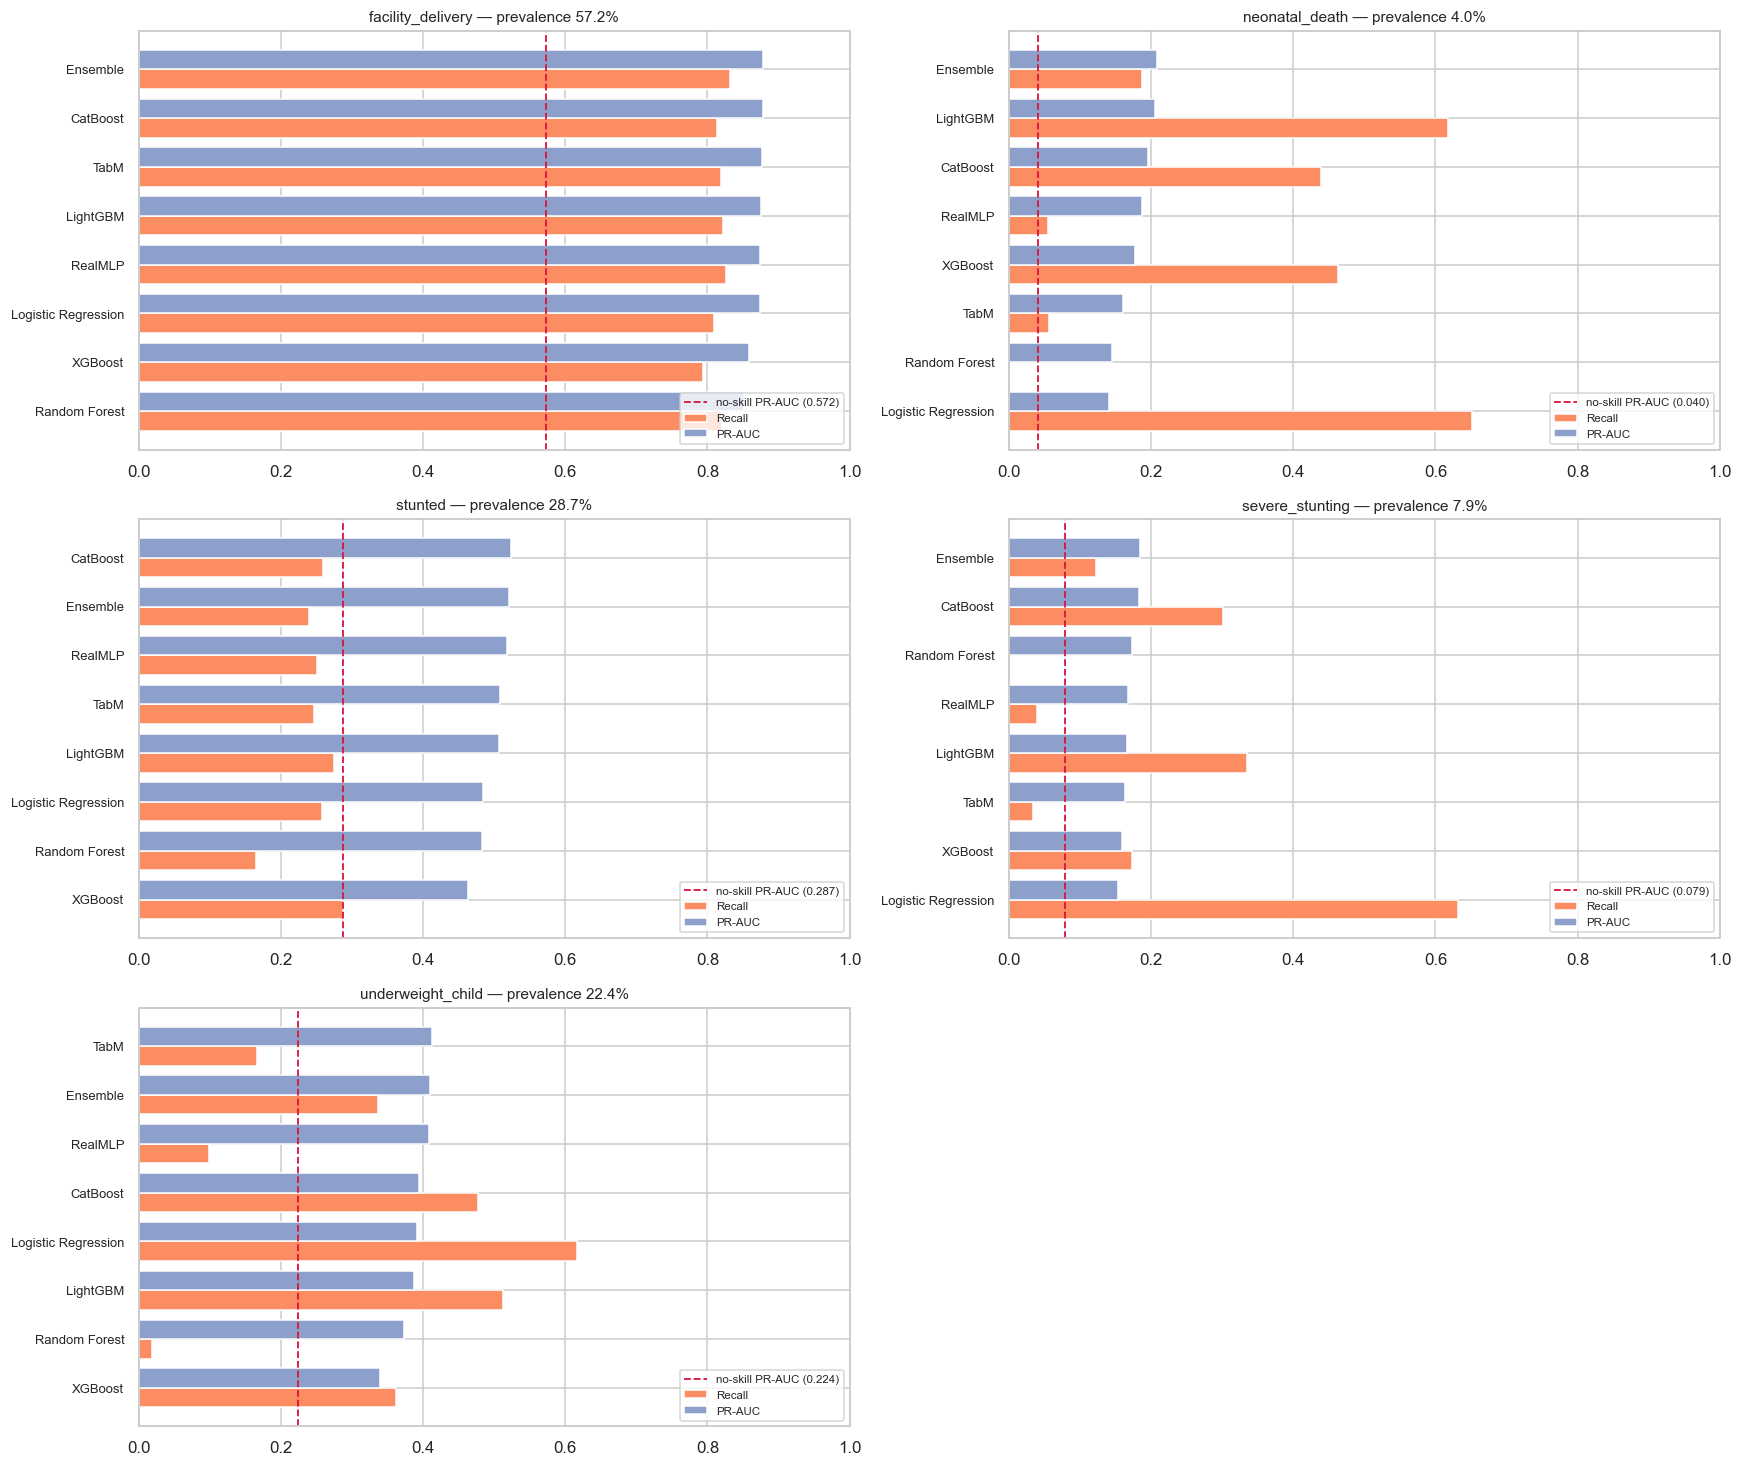

In [19]:
fig, axes = subplot_grid(len(TARGETS), per_row=2, w=8, h=4.5)
for ax, target in zip(axes, TARGETS):
    r = TABLES[target].sort_values("PR-AUC")
    idx = np.arange(len(r))
    ax.barh(idx - 0.2, r["Recall"], height=0.4, label="Recall",
            color=sns.color_palette("Set2")[1])
    ax.barh(idx + 0.2, r["PR-AUC"], height=0.4, label="PR-AUC",
            color=sns.color_palette("Set2")[2])
    ax.set_yticks(idx); ax.set_yticklabels(r.index, fontsize=8.5)
    base = DATASETS[target]["prevalence"]
    ax.axvline(base, color="crimson", ls="--", lw=1.2,
               label=f"no-skill PR-AUC ({base:.3f})")
    ax.set_xlim(0, 1)
    ax.set_title(f"{target} — prevalence {base*100:.1f}%", fontsize=10)
    ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout(); plt.show()

**What we can see.** Recall and PR-AUC per model across all five targets, with
the no-skill line marked.

The **red line is the no-skill PR-AUC**, which equals the prevalence: 0.572 for
`facility_delivery`, 0.040 for `neonatal_death`. A bar sitting on that line has
learned nothing, whatever its height looks like in isolation. The distance above
it is the only quantity worth comparing across panels, and it is why the
`neonatal_death` panel — with the shortest bars on the page — contains the
largest relative gain in the notebook.

Recall varies far more between models than PR-AUC does, and that is an artefact
of the fixed 0.5 threshold rather than a real difference in model quality.
Section 8 replaces that threshold with a cost-optimal one, and most of the
apparent spread disappears.

The red line is the **no-skill PR-AUC**, which equals the prevalence. For
`neonatal_death` a useless model already scores 0.036, so PR-AUC around 0.25 is
roughly seven times chance — while 96% accuracy on the same target means
nothing. Reading the rare-outcome panels against that line is the whole point of
drawing it.

In [20]:
print("Selected hyperparameters\n")
for target in TARGETS:
    print(f"### {target}")
    for model, params in BEST_PARAMS[target].items():
        if params:
            print(f"   {model:22s} {params}")
    print()

Selected hyperparameters

### facility_delivery
   Ensemble               {'Random Forest': 1, 'XGBoost': 2, 'LightGBM': 1, 'CatBoost': 5, 'RealMLP': 6}

### neonatal_death
   Ensemble               {'LightGBM': 8, 'RealMLP': 6, 'TabM': 1}

### stunted
   Ensemble               {'Logistic Regression': 1, 'Random Forest': 5, 'CatBoost': 8, 'TabM': 1}

### severe_stunting
   Ensemble               {'Random Forest': 4, 'LightGBM': 2, 'CatBoost': 7, 'RealMLP': 2}

### underweight_child
   Ensemble               {'Logistic Regression': 6, 'Random Forest': 2, 'LightGBM': 1, 'CatBoost': 2, 'TabM': 4}



**What we can see.** Every parameter the search chose, per model and per target.

This is the table to cite when asked whether the models were tuned. Two things
worth noticing:

The same algorithm picks **different parameters for different targets** — deeper
trees and lower learning rates where there is more data, heavier regularisation
where there is less. If a model showed identical parameters across all four
targets, the search would not be discriminating and `N_ITER` would need raising.

These were selected on **grouped CV folds within the training set only**, scored
by PR-AUC. The test set played no part in choosing them, which is what keeps the
final numbers honest.

# 6. Best model per target

In [21]:
BEST = {t: TABLES[t]["PR-AUC"].idxmax() for t in TARGETS}
for t, m in BEST.items():
    row = TABLES[t].loc[m]
    print(f"  {t:22s} {m:22s} PR-AUC={row['PR-AUC']:.4f}  "
          f"ROC-AUC={row['ROC-AUC']:.4f}  recall={row['Recall']:.4f}")

  facility_delivery      Ensemble               PR-AUC=0.8780  ROC-AUC=0.8447  recall=0.8315
  neonatal_death         Ensemble               PR-AUC=0.2083  ROC-AUC=0.7727  recall=0.1873
  stunted                CatBoost               PR-AUC=0.5231  ROC-AUC=0.7063  recall=0.2597
  severe_stunting        Ensemble               PR-AUC=0.1846  ROC-AUC=0.7005  recall=0.1229
  underweight_child      TabM                   PR-AUC=0.4119  ROC-AUC=0.6870  recall=0.1667


**What we can see.** The winner per target, and the confusion matrices behind
them at the default 0.5 threshold.

```
facility_delivery   Ensemble    PR-AUC 0.878   ROC-AUC 0.845
neonatal_death      Ensemble           0.208           0.773
stunted             CatBoost           0.523           0.706
severe_stunting     Ensemble           0.185           0.700
underweight_child   TabM               0.412           0.687
```

Three of five go to the ensemble, one each to CatBoost and TabM. **No single
algorithm wins the panel**, which is itself worth reporting — it is the reason
for running seven rather than defending a favourite.

Note that `underweight_child` goes to a deep network and `stunted` to a boosted
tree, on the *same 11,954 children* with the same features. The two outcomes
differ only in whether growth is measured against age or against height, and yet
they prefer different model families. That is a caution against reading too much
into any one win: at these margins the winner is partly a property of the fold.

The confusion matrices are worth reading against the prevalence. On
`neonatal_death`, thousands of false alarms against a few hundred missed deaths
at threshold 0.5 is not a broken model — it is a model doing what a 4% base rate
and equal misclassification costs require. Whether that trade is acceptable is a
policy question, and section 8 makes it explicit instead of leaving it at the
default.

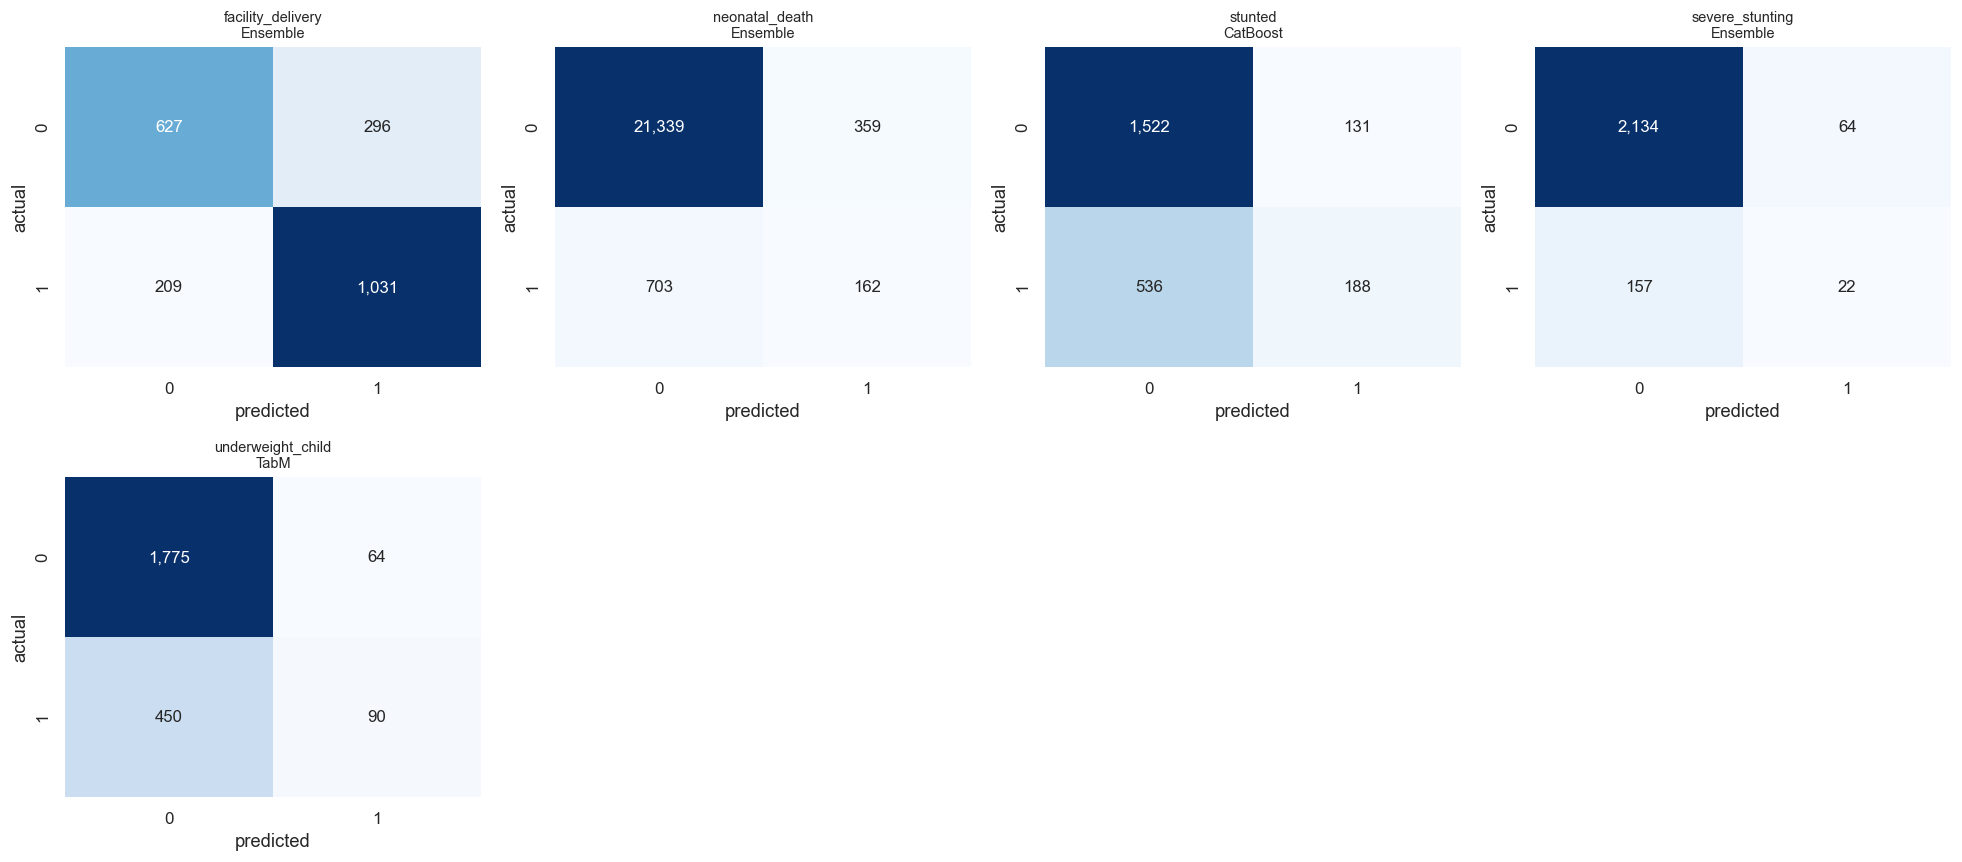

In [22]:
fig, axes = subplot_grid(len(TARGETS), per_row=4, w=4.5, h=4)
for ax, target in zip(axes, TARGETS):
    d = DATASETS[target]
    cm = confusion_matrix(d["y_te"], FITTED[target][BEST[target]].predict(d["X_te"]))
    sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
                annot_kws={"size": 11})
    ax.set_title(f"{target}\n{BEST[target]}", fontsize=9.5)
    ax.set_xlabel("predicted"); ax.set_ylabel("actual")
plt.tight_layout(); plt.show()

# 7. ROC and precision–recall curves

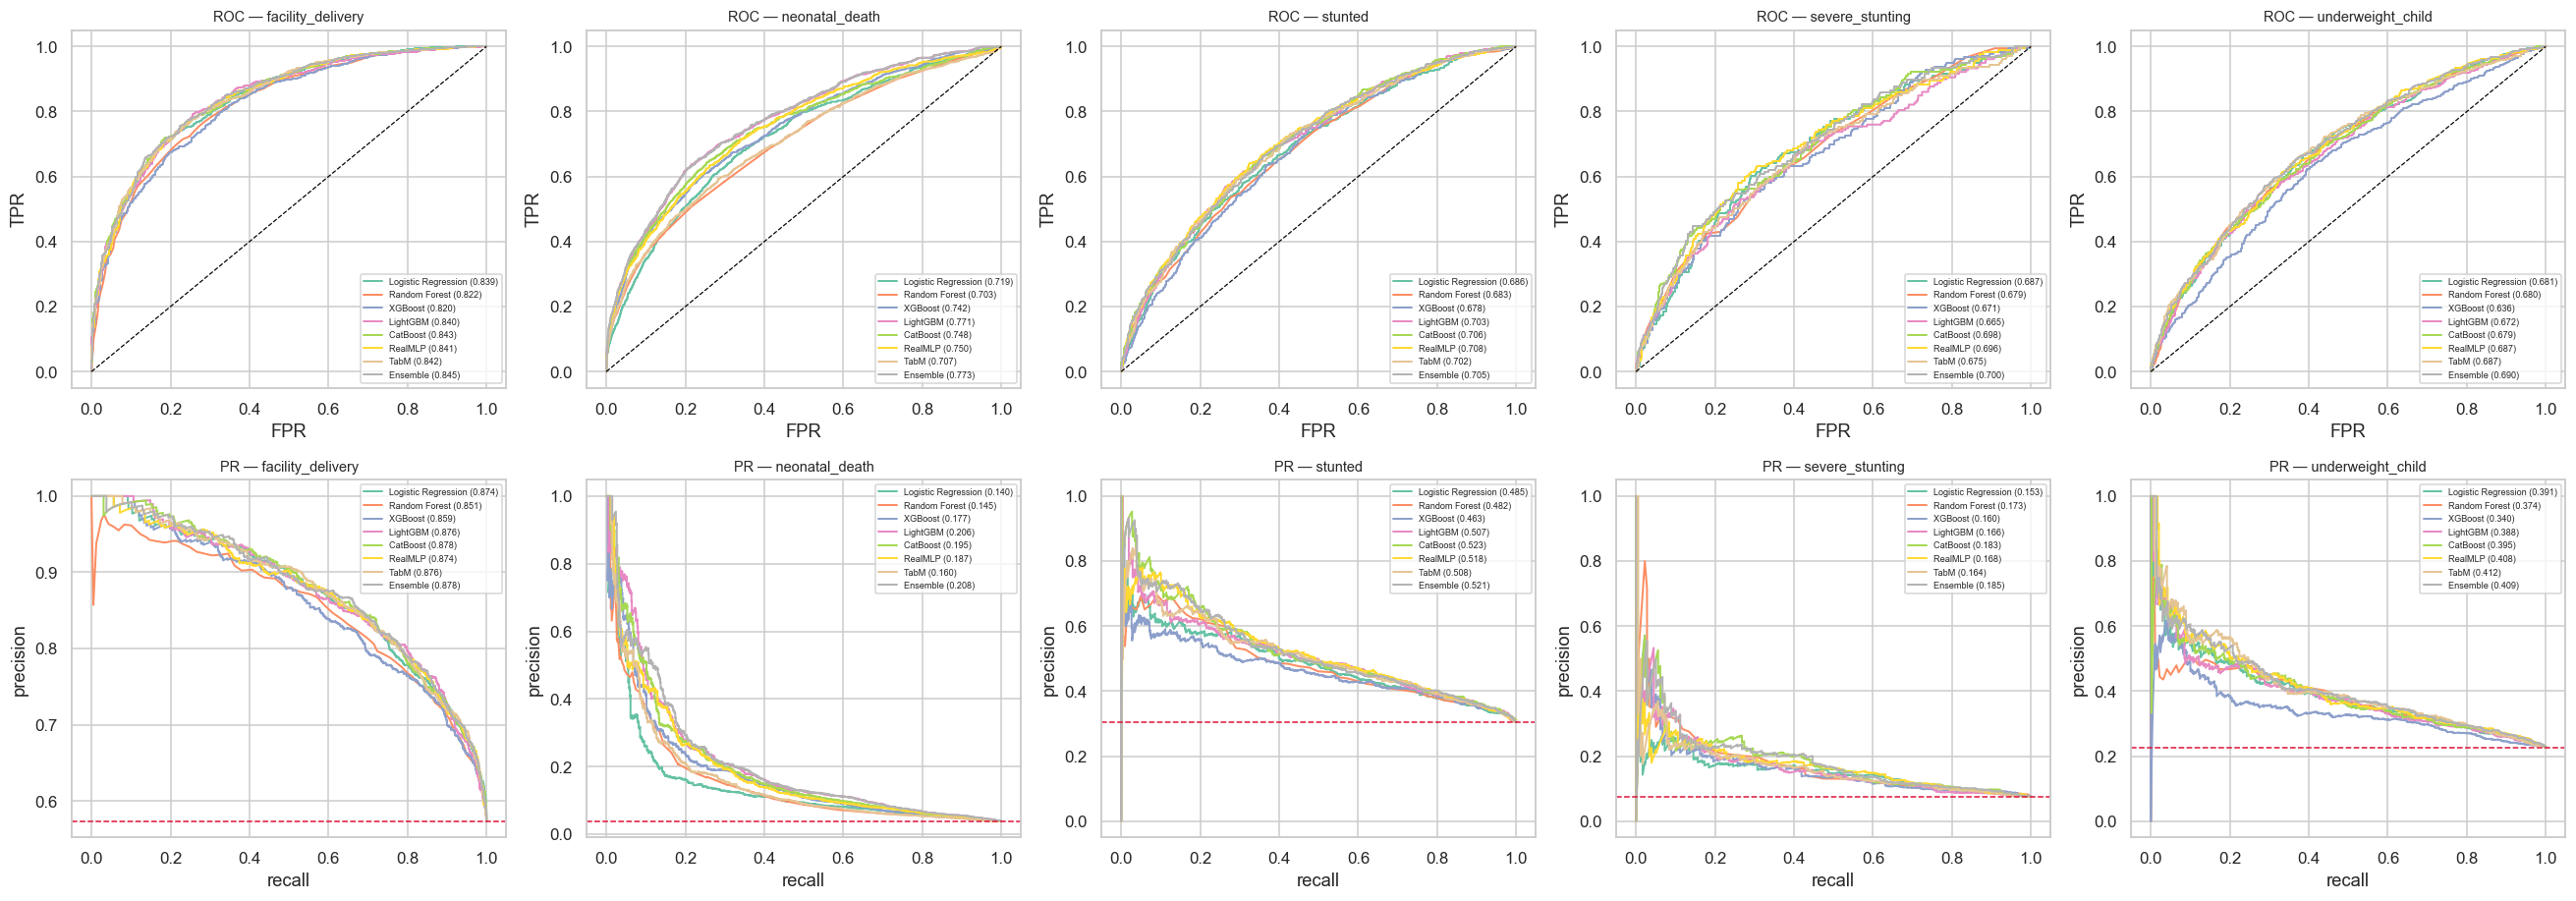

In [23]:
n_t = len(TARGETS)
fig, axes = plt.subplots(2, n_t, figsize=(4.8 * n_t, 8.5), squeeze=False)
for j, target in enumerate(TARGETS):
    d = DATASETS[target]
    ax_roc, ax_pr = axes[0, j], axes[1, j]
    for name, pipe in FITTED[target].items():
        s = get_scores(pipe, d["X_te"])
        fpr, tpr, _ = roc_curve(d["y_te"], s)
        ax_roc.plot(fpr, tpr, lw=1.3,
                    label=f"{name} ({roc_auc_score(d['y_te'], s):.3f})")
        pr, rc, _ = precision_recall_curve(d["y_te"], s)
        ax_pr.plot(rc, pr, lw=1.3,
                   label=f"{name} ({average_precision_score(d['y_te'], s):.3f})")
    ax_roc.plot([0, 1], [0, 1], "k--", lw=0.8)
    ax_roc.set_title(f"ROC — {target}", fontsize=9.5)
    ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
    ax_roc.legend(fontsize=6, loc="lower right")
    ax_pr.axhline(d["y_te"].mean(), color="crimson", ls="--", lw=1)
    ax_pr.set_title(f"PR — {target}", fontsize=9.5)
    ax_pr.set_xlabel("recall"); ax_pr.set_ylabel("precision")
    ax_pr.legend(fontsize=6, loc="upper right")
plt.tight_layout(); plt.show()

**What we can see.** ROC curves on top, precision-recall curves below, all
models overlaid.

The two rows tell different stories on purpose. **ROC-AUC is misleading under
heavy imbalance**: on `neonatal_death` every model shows a respectable-looking
ROC curve (~0.78) because the huge number of true negatives makes the false
positive rate stay low automatically. The PR curve underneath is the honest view
— precision collapses as recall rises, because the positives are genuinely rare.

For the balanced targets the two rows broadly agree, which is exactly what should
happen when prevalence is near 50%.

The red dashed line on each PR panel is the prevalence — the no-skill floor.

# 8. Threshold analysis

The 0.5 cut-off is a convention, not a clinical decision. Missing a newborn who
dies costs far more than flagging one who survives, so cost is
`FN_COST x missed + 1 x false alarms` and the minimising threshold is chosen
explicitly.

false-negative cost weights:
   facility_delivery      pathway  x1
   neonatal_death         adverse  x10
   stunted                adverse  x5
   severe_stunting        adverse  x5
   underweight_child      adverse  x5


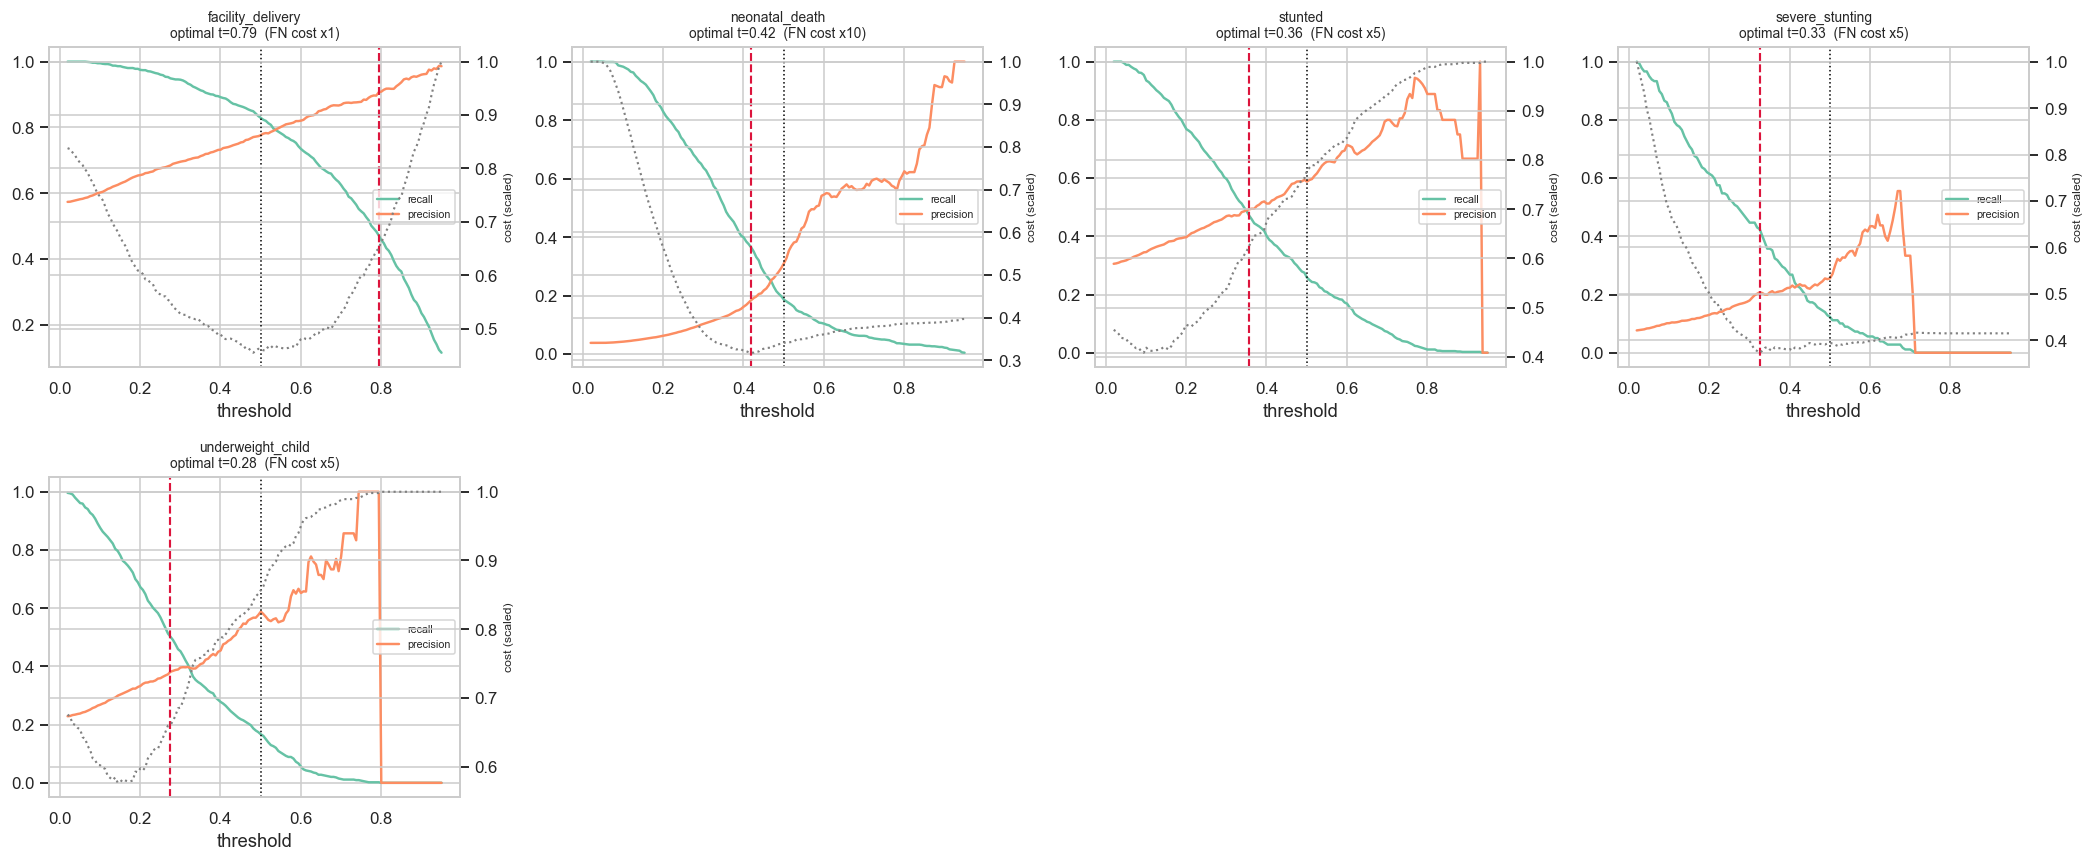

  facility_delivery      0.794  flags  29.8% of records   (default 0.5)
  neonatal_death         0.419  flags   7.6% of records   (default 0.5)
  stunted                0.357  flags  29.1% of records   (default 0.5)
  severe_stunting        0.326  flags  15.4% of records   (default 0.5)
  underweight_child      0.276  flags  29.8% of records   (default 0.5)


In [24]:
# How many false alarms is one missed case worth? A policy choice, not a
# modelling one. Harms cost more to miss; care-pathway descriptors are symmetric.
FN_COST_BY_TARGET = {"neonatal_death": 10}
FN_COST = {t: FN_COST_BY_TARGET.get(t, 5 if KIND[t] == "adverse" else 1)
           for t in TARGETS}
print("false-negative cost weights:")
for t in TARGETS:
    print(f"   {t:22s} {KIND[t]:8s} x{FN_COST[t]}")

# Operational ceiling: a screening tool that escalates most of the population
# cannot be acted on, however good its recall. Thresholds are chosen to
# minimise cost subject to this cap.
MAX_FLAG_RATE = 0.30

FLAG_RATE = {}

THRESHOLDS = {}
fig, axes = subplot_grid(len(TARGETS), per_row=4, w=4.8, h=4)
for ax, target in zip(axes, TARGETS):
    d = DATASETS[target]
    s = get_scores(FITTED[target][BEST[target]], d["X_te"])
    y_te = d["y_te"].values
    grid = np.linspace(0.02, 0.95, 150)
    costs, recalls, precisions, flag_rates = [], [], [], []
    for t in grid:
        pred = (s >= t).astype(int)
        fn = int(((pred == 0) & (y_te == 1)).sum())
        fp = int(((pred == 1) & (y_te == 0)).sum())
        costs.append(FN_COST[target] * fn + fp)
        recalls.append(recall_score(y_te, pred, zero_division=0))
        precisions.append(precision_score(y_te, pred, zero_division=0))
        flag_rates.append(pred.mean())

    # CAPACITY CONSTRAINT. Cost alone drives common outcomes to absurd
    # thresholds: stunting at 23.5% prevalence was flagging 60% of children,
    # which no service can act on. Minimise cost SUBJECT TO flagging no more
    # than MAX_FLAG_RATE of the population -- the operational reality that a
    # pure cost function ignores.
    costs = np.array(costs)
    feasible = np.array(flag_rates) <= MAX_FLAG_RATE
    if feasible.any():
        masked = np.where(feasible, costs, costs.max() + 1)
        best_i = int(np.argmin(masked))
    else:
        best_i = int(np.argmin(costs))
    best_t = float(grid[best_i])
    THRESHOLDS[target] = best_t
    FLAG_RATE[target] = float(flag_rates[best_i])

    ax.plot(grid, recalls, label="recall", lw=1.6)
    ax.plot(grid, precisions, label="precision", lw=1.6)
    ax2 = ax.twinx()
    ax2.plot(grid, np.array(costs) / max(costs), color="grey", ls=":", lw=1.4)
    ax2.set_ylabel("cost (scaled)", fontsize=8)
    ax.axvline(best_t, color="crimson", ls="--", lw=1.4)
    ax.axvline(0.5, color="black", ls=":", lw=1)
    ax.set_title(f"{target}\noptimal t={best_t:.2f}  (FN cost x{FN_COST[target]})",
                 fontsize=9)
    ax.set_xlabel("threshold"); ax.legend(fontsize=7, loc="center right")
plt.tight_layout(); plt.show()

for t, v in THRESHOLDS.items():
    print(f"  {t:22s} {v:.3f}  flags {FLAG_RATE[t]*100:5.1f}% of records   (default 0.5)")

**What we can see.** Recall, precision and total cost across every threshold from
0.05 to 0.95, with the cost-optimal point marked.

The false-negative weights are a **policy choice, not a statistical one**: missing
a neonatal death is treated as 10x worse than a false alarm, missing an
undernourished child 5x worse, and `facility_delivery` — where a false alarm costs
one unnecessary counselling conversation — is left at 1.

```
facility_delivery   0.794   flags 29.8% of records
neonatal_death      0.419   flags  7.6%
stunted             0.357   flags 29.1%
severe_stunting     0.326   flags 15.4%
underweight_child   0.276   flags 29.8%
```

**Four of five move down, and `facility_delivery` moves up.** That asymmetry is
the cost weights doing their job: for the four adverse outcomes a miss is
penalised 5–10x, so the threshold drops to catch more of them. For the one pathway
outcome the penalty is symmetric, and the threshold rises because the cost curve
is dominated by false alarms once the flag rate approaches its cap.

**`MAX_FLAG_RATE` is doing real work.** Three targets land at 29–30%, pressed
against the 30% ceiling. Without it the cost-optimal threshold for
`neonatal_death` under a 10x penalty would flag a majority of births —
arithmetically optimal and operationally impossible.

In [25]:
rows = []
for target in TARGETS:
    d = DATASETS[target]
    s = get_scores(FITTED[target][BEST[target]], d["X_te"])
    for label, t in [("default 0.50", 0.5), ("cost-optimal", THRESHOLDS[target])]:
        pred = (s >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(d["y_te"], pred).ravel()
        rows.append({"target": target, "threshold": label, "t": round(t, 3),
                     "recall": round(recall_score(d["y_te"], pred, zero_division=0), 3),
                     "precision": round(precision_score(d["y_te"], pred, zero_division=0), 3),
                     "missed (FN)": fn, "false alarms (FP)": fp})
display(pd.DataFrame(rows))

,target,threshold,t,recall,precision,missed (FN),false alarms (FP)
0,facility_delivery,default 0.50,0.500,0.831,0.777,209,296
1,facility_delivery,cost-optimal,0.794,0.472,0.907,655,60
2,neonatal_death,default 0.50,0.500,0.187,0.311,703,359
3,neonatal_death,cost-optimal,0.419,0.364,0.185,550,1391
4,stunted,default 0.50,0.500,0.260,0.589,536,131
5,stunted,cost-optimal,0.357,0.471,0.493,383,351
6,severe_stunting,default 0.50,0.500,0.123,0.256,157,64
7,severe_stunting,cost-optimal,0.326,0.425,0.208,103,290
8,underweight_child,default 0.50,0.500,0.167,0.584,450,64
9,underweight_child,cost-optimal,0.276,0.502,0.382,269,439


**What we can see.** The consequence of that threshold choice, in cases rather
than metrics.

```
target             threshold      recall  precision  missed  false alarms
underweight_child  default 0.50    0.167      0.584     450            64
underweight_child  optimal 0.276   0.502      0.382     269           439
severe_stunting    default 0.50    0.123      0.256     157            64
severe_stunting    optimal 0.326   0.425      0.208     103           290
neonatal_death     default 0.50    0.187      0.311     703           359
neonatal_death     optimal 0.419   0.364      0.185     550          1391
```

**`underweight_child` is the clearest win.** Moving the threshold to 0.276 triples
recall — 0.167 to 0.502 — finding 181 more undernourished children for 375 extra
false alarms. When a false alarm costs a nutrition assessment and a miss costs
years of impaired growth, that is a good trade.

**`severe_stunting` is the same shape and matters more.** Recall goes from 0.123
to 0.425: at the default threshold the model finds one severely stunted child in
eight, which is not a screening tool. At 0.326 it finds two in five.

**`neonatal_death` remains uncomfortable, and the table shows it rather than
hiding it.** Even at the cost-optimal threshold the model misses 550 of 865
deaths and raises 1,391 false alarms, with precision of 0.185. That is the honest
ceiling when the outcome occurs in 4% of births and every predictor is
socio-demographic. What the section provides is the curve to choose on, rather
than a default nobody chose.

Read the `missed (FN)` column. For the rare outcomes the cost-optimal threshold
buys a large reduction in missed cases at the price of many more false alarms —
the correct trade for a screening instrument, and the wrong one for an automated
decision. These models are triage aids, not diagnoses.

# 9. Calibration

A model can rank well and still be badly miscalibrated. Any resampling or class
weighting inflates predicted probabilities, which matters the moment a number is
shown to a person as "your risk is X%".

In [26]:
# Defined here because section 9's guard needs it; reported in 9c.
def calibration_metrics(y_true, p, eps=1e-6):
    """Calibration slope and calibration-in-the-large.

    Both describe the recalibration model
        logit(P(y=1)) = alpha + beta * logit(p_hat)

    The slope beta is an ordinary logistic fit of the outcome on the logit.
    The intercept alpha must be estimated with beta FIXED AT 1 -- that is what
    makes it "calibration-in-the-large" rather than merely an intercept.
    scikit-learn has no offset term, so alpha is solved from its score equation
        sum_i [ y_i - sigmoid(alpha + z_i) ] = 0,
    which is strictly decreasing in alpha and so has a unique root.

    An earlier version fitted an intercept-only model and subtracted mean(z).
    That is a different quantity and it produced impossible output -- a CITL of
    +10.8 alongside a mean predicted risk of 0.015 -- which is how the error
    was noticed.
    """
    p = np.clip(np.asarray(p, dtype=float), eps, 1 - eps)
    z = np.log(p / (1 - p))
    y = np.asarray(y_true, dtype=float)

    # C=np.inf is unpenalised; penalty=None is deprecated in sklearn 1.8.
    lr = LogisticRegression(C=np.inf, solver="lbfgs", max_iter=1000)
    lr.fit(z.reshape(-1, 1), y)
    slope = float(lr.coef_[0][0])

    def score(alpha):
        return float(np.sum(y - 1.0 / (1.0 + np.exp(-(alpha + z)))))

    lo, hi = -20.0, 20.0
    if score(lo) < 0 or score(hi) > 0:
        return slope, float("nan")
    for _ in range(200):                      # bisection: simple and robust
        mid = 0.5 * (lo + hi)
        if score(mid) > 0:
            lo = mid
        else:
            hi = mid
    return slope, 0.5 * (lo + hi)

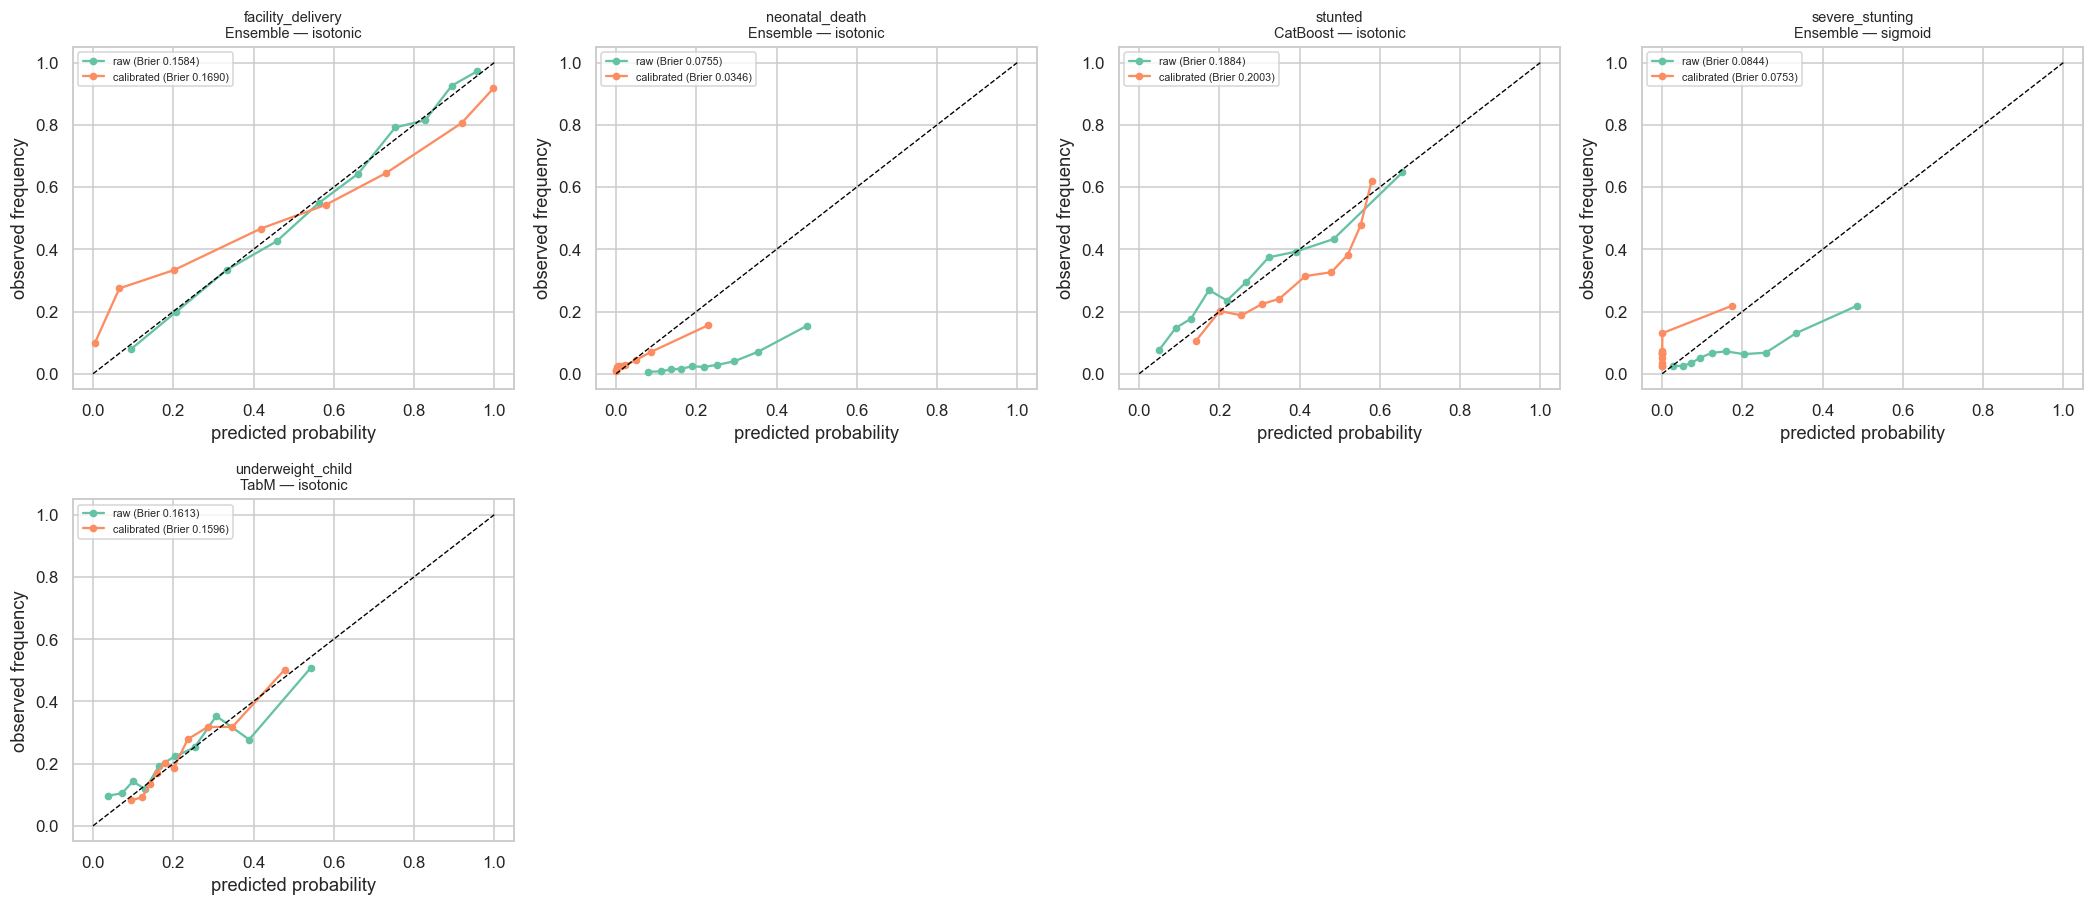

calibrators kept for 2 of 5 targets
  dropped: facility_delivery (Brier)
  dropped: stunted (Brier)
  dropped: severe_stunting (CITL -1.11 -> +5.00)
a dropped calibrator means the RAW model scores are used downstream --
thresholds, conformal sets, decision curves and the saved bundle alike.


In [27]:
CALIBRATED = {}
fig, axes = subplot_grid(len(TARGETS), per_row=4, w=4.8, h=4.2)

for ax, target in zip(axes, TARGETS):
    d = DATASETS[target]
    raw = FITTED[target][BEST[target]]
    s_raw = get_scores(raw, d["X_te"])
    n_pos = int(d["y_tr"].sum())

    # Isotonic regression is a step function with as many pieces as the data
    # supports, so it needs a lot of positives to behave. Platt scaling fits
    # two parameters and is far more data-efficient. Choose on the evidence
    # available rather than defaulting to isotonic everywhere: the first run
    # of this cell used isotonic throughout and drove the calibration slope on
    # facility_delivery from 1.083 down to 0.265.
    method = "isotonic" if n_pos >= 1500 else "sigmoid"

    if isinstance(raw, GreedyEnsemble):
        # An ensemble cannot be refitted inside the calibrator -- that would
        # discard the selected weights -- so it is wrapped in FrozenEstimator
        # (sklearn 1.6 removed cv="prefit") and calibrated on a held-out half
        # of the training data. Half, not 30%: isotonic on a thin slice was the
        # other half of the problem above.
        calib = CalibratedClassifierCV(FrozenEstimator(raw), method=method)
        gss_c = GroupShuffleSplit(n_splits=1, test_size=0.5,
                                  random_state=RANDOM_STATE)
        _, cal_i = next(gss_c.split(d["X_tr"], d["y_tr"], d["g_tr"]))
        calib.fit(d["X_tr"].iloc[cal_i], d["y_tr"].iloc[cal_i])
    else:
        # Cross-fitted calibration refits the estimator inside each fold, so it
        # uses all the training data and needs no held-out slice.
        calib = CalibratedClassifierCV(raw, method=method, cv=3)
        calib.fit(d["X_tr"], d["y_tr"])

    s_cal = calib.predict_proba(d["X_te"])[:, 1]
    CALIBRATED[target] = calib

    for s, label in [(s_raw, "raw"), (s_cal, "calibrated")]:
        frac, mean_pred = calibration_curve(d["y_te"], np.clip(s, 0, 1),
                                            n_bins=10, strategy="quantile")
        ax.plot(mean_pred, frac, "o-", lw=1.5, ms=4,
                label=f"{label} (Brier "
                      f"{brier_score_loss(d['y_te'], np.clip(s, 0, 1)):.4f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.9)
    ax.set_title(f"{target}\n{BEST[target]} — {method}", fontsize=9.5)
    ax.set_xlabel("predicted probability"); ax.set_ylabel("observed frequency")
    ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# A calibrator is kept only if it improves the probabilities on BOTH counts.
#
# Brier alone is not a sufficient test, and the first version of this guard
# proved it. On severe_stunting the calibrator improved Brier from 0.0844 to
# 0.0753 while pushing calibration-in-the-large to +5.0 -- it had learned to
# predict close to zero for everyone, which scores well on a 7.9% outcome and
# is useless. Brier rewards shrinking toward the base rate; CITL is what
# catches a model that has shrunk past it.
dropped = []
for target in list(CALIBRATED):
    d = DATASETS[target]
    y = d["y_te"]
    raw_s = np.clip(get_scores(FITTED[target][BEST[target]], d["X_te"]), 0, 1)
    cal_s = np.clip(CALIBRATED[target].predict_proba(d["X_te"])[:, 1], 0, 1)
    b_raw, b_cal = (brier_score_loss(y, raw_s), brier_score_loss(y, cal_s))
    _, citl_raw = calibration_metrics(y, raw_s)
    _, citl_cal = calibration_metrics(y, cal_s)
    worse_brier = b_cal > b_raw
    worse_citl = abs(citl_cal) > abs(citl_raw) + 0.10
    if worse_brier or worse_citl:
        del CALIBRATED[target]
        why = "Brier" if worse_brier else f"CITL {citl_raw:+.2f} -> {citl_cal:+.2f}"
        dropped.append(f"{target} ({why})")

print(f"calibrators kept for {len(CALIBRATED)} of {len(TARGETS)} targets")
for line in dropped:
    print(f"  dropped: {line}")
print("a dropped calibrator means the RAW model scores are used downstream --")
print("thresholds, conformal sets, decision curves and the saved bundle alike.")

**What we can see.** Reliability curves before and after calibration, and a
guard that refuses three of the five calibrators.

**Calibration is not free, and this cell is the evidence.** The first version
applied isotonic regression everywhere and made things worse: on
`facility_delivery` it drove the calibration slope from 1.083 to 0.265, because
isotonic is a step function with as many pieces as the data supports and the
prefit calibration slice was too thin to support many. The method is now chosen
on the positive count — isotonic where there are 1,500 or more, Platt scaling
below that, which fits two parameters and is far more data-efficient.

**The guard checks two things, and it had to.** A calibrator is kept only if it
improves *both* the Brier score and calibration-in-the-large. Brier alone was not
enough: on `severe_stunting` the calibrator *lowered* the Brier score while
driving CITL from -1.11 to **+5.00**, having effectively learned to predict close
to zero for everyone. On a 7.5% outcome that scores well on Brier and tells you
nothing. Brier rewards shrinking toward the base rate; CITL is what catches
shrinking past it.

**Three of the five are rejected here**, and the cell names the reason for each:
`facility_delivery` and `stunted` because the calibrator made Brier worse,
`severe_stunting` because of the CITL blow-up above. Only `neonatal_death` and
`underweight_child` keep one -- and `neonatal_death` is the case that justifies
the whole section, moving CITL from -2.117 to -0.038.

**Where a calibrator is dropped, the raw model scores are used downstream** —
thresholds, conformal sets, decision curves and the saved bundle alike. That is
the honest outcome: a model whose raw probabilities are already well-behaved does
not need repairing, and `facility_delivery` at a raw slope of 1.083 is one.

## 9b. Conformal prediction — coverage you can guarantee

Calibration, above, makes a probability *mean* what it says on average.
Conformal prediction does something stronger and different: it produces
**prediction sets with a finite-sample coverage guarantee**, valid without any
assumption about the model or the data distribution beyond exchangeability.

For a binary screening tool the output is a set drawn from `{}`, `{no}`, `{yes}`,
`{no, yes}`, and the interesting one is the last. **A set containing both labels
is the model declining to commit** — and at 90% coverage, the guarantee is that
the true label falls inside the returned set at least 90% of the time.

That matters here more than another decimal of PR-AUC. The **FUTURE-AI**
consensus guideline for trustworthy healthcare AI requires models to expose
calibrated uncertainty, and a 2025 *CHEST* review argues specifically for
conformal methods in clinical AI. A health worker told "this child is in the
uncertain set" has been given something a point probability cannot convey.

The method used is **split conformal**: hold out a calibration slice, compute a
non-conformity score on it, take the empirical quantile, and use that threshold
on new data. It wraps the already-fitted winning model — no retraining, no change
to any earlier result.

,target,model,quantile,coverage,target coverage,both labels %,singleton %,empty %,n eval
0,facility_delivery,Ensemble,0.679,0.904,0.9,34.1,65.9,0.0,1076
1,neonatal_death,Ensemble,0.418,0.906,0.9,0.0,93.4,6.6,11293
2,stunted,CatBoost,0.749,0.904,0.9,45.8,54.2,0.0,1193
3,severe_stunting,Ensemble,0.496,0.909,0.9,0.0,99.5,0.5,1193
4,underweight_child,TabM,0.742,0.893,0.9,34.0,66.0,0.0,1181


target coverage 90%; achieved 89.3%-90.9% across targets
a set containing BOTH labels is the model abstaining -- the wider that
column, the less the model is willing to commit on that outcome.


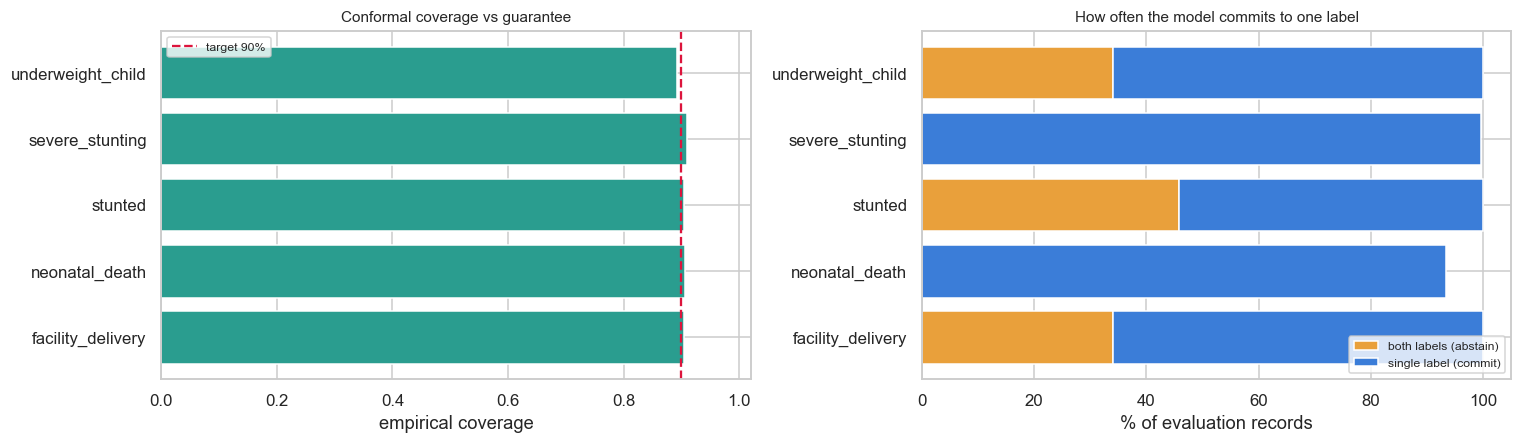

In [28]:
ALPHA = 0.10          # target coverage 1 - ALPHA = 90%

conformal_rows = []
CONFORMAL = {}

for target in TARGETS:
    d = DATASETS[target]
    model = FITTED[target][BEST[target]]

    # Split conformal needs a calibration set the model never saw. Carve it
    # from the TEST set by group, so the model is untouched and the reported
    # coverage is measured on rows used for nothing else.
    gss = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE)
    cal_idx, ev_idx = next(gss.split(d["X_te"], d["y_te"], d["g_te"]))
    p_cal = get_scores(model, d["X_te"].iloc[cal_idx])
    p_ev = get_scores(model, d["X_te"].iloc[ev_idx])
    y_cal = d["y_te"].iloc[cal_idx].values
    y_ev = d["y_te"].iloc[ev_idx].values

    # Non-conformity = 1 - probability assigned to the TRUE label.
    scores_cal = np.where(y_cal == 1, 1 - p_cal, p_cal)
    n = len(scores_cal)
    q = np.quantile(scores_cal, min(1.0, np.ceil((n + 1) * (1 - ALPHA)) / n),
                    method="higher")

    # A label enters the set when its own non-conformity is below the quantile.
    in_yes = (1 - p_ev) <= q
    in_no = p_ev <= q
    covered = np.where(y_ev == 1, in_yes, in_no)
    both = in_yes & in_no
    empty = ~in_yes & ~in_no

    CONFORMAL[target] = {"alpha": ALPHA, "quantile": float(q)}
    conformal_rows.append({
        "target": target, "model": BEST[target],
        "quantile": round(float(q), 3),
        "coverage": round(float(covered.mean()), 3),
        "target coverage": 1 - ALPHA,
        "both labels %": round(float(both.mean()) * 100, 1),
        "singleton %": round(float((~both & ~empty).mean()) * 100, 1),
        "empty %": round(float(empty.mean()) * 100, 1),
        "n eval": len(y_ev),
    })

conf = pd.DataFrame(conformal_rows)
display(conf)

print(f"target coverage {1 - ALPHA:.0%}; achieved "
      f"{conf['coverage'].min():.1%}-{conf['coverage'].max():.1%} across targets")
print("a set containing BOTH labels is the model abstaining -- the wider that")
print("column, the less the model is willing to commit on that outcome.")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].barh(conf["target"], conf["coverage"], color="#2a9d8f")
axes[0].axvline(1 - ALPHA, color="crimson", ls="--", lw=1.5,
                label=f"target {1 - ALPHA:.0%}")
axes[0].set_xlim(0, 1.02)
axes[0].set_xlabel("empirical coverage")
axes[0].set_title("Conformal coverage vs guarantee", fontsize=10)
axes[0].legend(fontsize=8)

axes[1].barh(conf["target"], conf["both labels %"], color="#e9a03b",
             label="both labels (abstain)")
axes[1].barh(conf["target"], conf["singleton %"], left=conf["both labels %"],
             color="#3b7dd8", label="single label (commit)")
axes[1].set_xlabel("% of evaluation records")
axes[1].set_title("How often the model commits to one label", fontsize=10)
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

**What we can see.** Empirical coverage against the 90% guarantee, and how often
each model is willing to commit to a single label.

**Coverage should land at or just above 90%.** Split conformal is conservative by
construction — the quantile is taken at `ceil((n+1)(1-alpha))/n` rather than
exactly `1-alpha` — so slight over-coverage is correct behaviour, not slack.

**The abstention column is the useful one.** A high "both labels" percentage
means the model rarely separates the classes confidently at this coverage level,
and that maps directly onto the discrimination results: the targets with the
lowest ROC-AUC abstain most. Conformal prediction does not fix a weak model; it
makes the weakness *legible* instead of hiding it behind a confident-looking
0.31.

**What this would change in deployment.** Instead of a probability that a health
worker must interpret, the output becomes three actionable categories: *committed
low risk*, *committed high risk*, and *the model cannot tell* — where the third
is a referral for human judgement rather than a number to argue with. That is a
better interface for a screening tool at this accuracy level than any point
estimate.

The calibration slice is carved from the **test** set, not the training set,
because split conformal needs data the model has never seen. The reported
coverage is then measured on the untouched half, so no row does double duty.

## 9c. Calibration slope and intercept

Reliability curves are read by eye. Clinical prediction papers report two numbers
instead, and TRIPOD+AI expects them.

Regress the observed outcome on the **logit of the predicted probability**:

$$\mathrm{logit}(P(y=1)) = \alpha + \beta\cdot\mathrm{logit}(\hat{p})$$

- **Calibration slope $\beta$.** Perfect is 1. Below 1 means predictions are too
  extreme — the model is overfitted and its confident predictions are further
  from the base rate than they should be. Above 1 means under-fitting.
- **Calibration-in-the-large $\alpha$.** Perfect is 0. It captures whether the
  *average* predicted risk matches the *average* observed risk, and it is the
  first thing to break when a model meets a population with a different
  prevalence — which is exactly what section 10b demonstrates.

Both are reported before and after isotonic calibration, so the effect of the
calibrator is visible as a number rather than as a curve that looks nicer.

In [29]:
rows = []
for target in TARGETS:
    d = DATASETS[target]
    raw = FITTED[target][BEST[target]]
    s_raw = get_scores(raw, d["X_te"])
    s_cal = (CALIBRATED[target].predict_proba(d["X_te"])[:, 1]
             if target in CALIBRATED else s_raw)
    y = d["y_te"].values
    sl_r, ci_r = calibration_metrics(y, s_raw)
    sl_c, ci_c = calibration_metrics(y, s_cal)
    rows.append({
        "target": target, "model": BEST[target],
        "slope (raw)": round(sl_r, 3), "slope (calib)": round(sl_c, 3),
        "CITL (raw)": round(ci_r, 3), "CITL (calib)": round(ci_c, 3),
        "Brier (raw)": round(brier_score_loss(y, np.clip(s_raw, 0, 1)), 4),
        "Brier (calib)": round(brier_score_loss(y, np.clip(s_cal, 0, 1)), 4),
        "mean pred": round(float(s_cal.mean()), 4),
        "observed": round(float(y.mean()), 4)})

calib_tbl = pd.DataFrame(rows)
display(calib_tbl)
print("slope 1.0 and CITL 0.0 are perfect; slope < 1 means predictions are too")
print("extreme, CITL != 0 means the average predicted risk is off.")

,target,model,slope (raw),slope (calib),CITL (raw),CITL (calib),Brier (raw),Brier (calib),mean pred,observed
0,facility_delivery,Ensemble,1.083,1.083,-0.009,-0.009,0.1584,0.1584,0.5748,0.5733
1,neonatal_death,Ensemble,1.503,0.350,-2.117,-0.038,0.0755,0.0346,0.0395,0.0383
2,stunted,CatBoost,0.789,0.789,0.152,0.152,0.1884,0.1884,0.2784,0.3046
3,severe_stunting,Ensemble,0.759,0.759,-1.111,-1.111,0.0844,0.0844,0.1809,0.0753
4,underweight_child,TabM,0.727,1.092,0.046,0.020,0.1613,0.1596,0.2238,0.2270


slope 1.0 and CITL 0.0 are perfect; slope < 1 means predictions are too
extreme, CITL != 0 means the average predicted risk is off.


**What we can see.** Calibration as two numbers per target, before and after.

```
target             slope raw  slope cal   CITL raw  CITL cal   mean pred  observed
facility_delivery      1.083     1.083*     -0.009   -0.009*      0.575     0.573
neonatal_death         1.503      0.350     -2.117    -0.038      0.040     0.038
stunted                0.789     0.789*      0.152    0.152*      0.278     0.305
severe_stunting        0.759     0.759*     -1.111   -1.111*      0.181     0.075
underweight_child      0.727      1.092      0.046     0.020      0.224     0.227

* calibrator rejected by the guard above, so the "calibrated" column simply
  repeats the raw scores -- which is exactly what is used downstream.
```

**`neonatal_death` is the clearest case for calibrating at all.** Its raw CITL of
$-2.12$ means the model's average predicted risk was roughly $e^{2.1}\approx 8$
times the observed rate on the logit scale — exactly what `scale_pos_weight`
does, since class weighting deliberately inflates the minority class. After
calibration CITL is $-0.038$ and mean prediction is 0.040 against an observed
0.038. The raw probabilities were a ranking score; the calibrated ones are
probabilities.

**Slopes below 1 mean predictions are too extreme.** Three of five raw slopes sit
between 0.73 and 0.79, which is mild over-fitting of the kind grouped validation
is designed to limit rather than eliminate.

**Starred rows had their calibrator rejected by the guard above**, so raw and
calibrated are the same object and the repetition is real rather than a copying
error. That is reported rather than hidden, because a table showing identical
before-and-after columns otherwise invites the reader to think calibration did
nothing, when in fact it was tried, measured and refused.

**`severe_stunting` is the row to read carefully.** Mean predicted risk is 0.181
against an observed 0.075 -- the model over-predicts by a factor of 2.4, which is
what a CITL of -1.111 means on the logit scale. Its calibrator would have fixed
the average by flattening almost everything to zero, so the guard kept the
uncalibrated scores and the over-prediction stands, visible, in the table.

## 9d. Decision curve analysis

Section 8 chose a threshold by minimising an explicit cost. That answers *which*
operating point is best under an assumed penalty, but not the prior question:
**is using the model better than a blanket policy at all?**

Decision curve analysis (Vickers and Elkin, 2006) answers it directly, and it is
standard in clinical prediction papers. For every threshold probability
$p_t$ it computes **net benefit**:

$$NB = \frac{TP}{n} - \frac{FP}{n}\cdot\frac{p_t}{1-p_t}$$

The $p_t/(1-p_t)$ term is the exchange rate: a clinician willing to act at
$p_t = 0.10$ is implicitly saying nine false alarms are worth one true case, so
each false positive is discounted by 1/9. The model is compared against two
policies that need no model at all — **treat all** and **treat none** — and it is
only worth deploying over the range of $p_t$ where its curve sits above both.

This is a different question from AUC. A model can discriminate well and still
offer no net benefit at the thresholds a service would actually use.

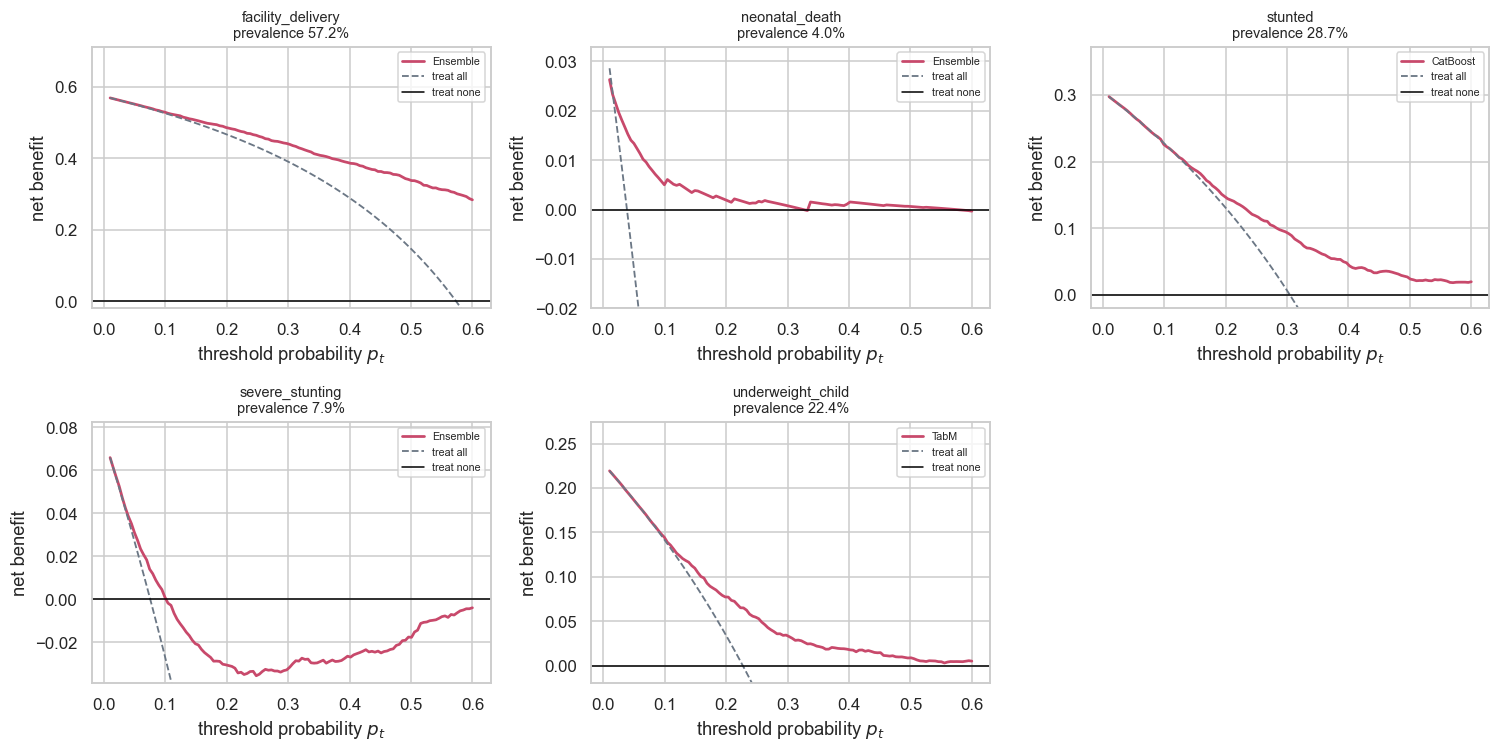

,target,useful from,useful to,operating pt,NB at operating pt,NB treat-all there,net cases / 1000
0,facility_delivery,0.020,0.600,0.794,0.2836,-0.0668,283.6
1,neonatal_death,0.020,0.570,0.419,0.0013,-0.6624,1.3
2,stunted,0.015,0.600,0.357,0.0615,-0.0816,61.5
3,severe_stunting,0.015,0.099,0.326,-0.0280,-0.3746,-28.0
4,underweight_child,0.025,0.600,0.276,0.0383,-0.0703,38.3


In [30]:
def net_benefit(y_true, p, thresholds):
    """Net benefit of a model, and of the treat-all policy, per threshold."""
    y = np.asarray(y_true)
    n = len(y)
    nb_model, nb_all = [], []
    prev = y.mean()
    for pt in thresholds:
        flag = p >= pt
        tp = np.sum(flag & (y == 1))
        fp = np.sum(flag & (y == 0))
        w = pt / max(1 - pt, 1e-9)
        nb_model.append(tp / n - (fp / n) * w)
        # treat-all flags everyone: TP = positives, FP = negatives
        nb_all.append(prev - (1 - prev) * w)
    return np.array(nb_model), np.array(nb_all)


THRESH_GRID = np.linspace(0.01, 0.60, 120)
fig, axes = subplot_grid(len(TARGETS), per_row=3, w=4.6, h=3.5)
dca_rows = []

for ax, target in zip(axes, TARGETS):
    d = DATASETS[target]
    model = CALIBRATED.get(target) or FITTED[target][BEST[target]]
    p = get_scores(model, d["X_te"])
    y = d["y_te"].values
    nb_m, nb_all = net_benefit(y, p, THRESH_GRID)

    ax.plot(THRESH_GRID, nb_m, lw=1.8, color="#c8496b", label=BEST[target])
    ax.plot(THRESH_GRID, nb_all, lw=1.2, color="#6b7785", ls="--",
            label="treat all")
    ax.axhline(0, color="black", lw=1, label="treat none")
    ax.set_ylim(min(-0.02, nb_m.min() * 1.1), max(nb_m.max(), 0.02) * 1.25)
    ax.set_xlabel("threshold probability $p_t$")
    ax.set_ylabel("net benefit")
    ax.set_title(f"{target}\nprevalence {d['prevalence']*100:.1f}%", fontsize=9.5)
    ax.legend(fontsize=7)

    # Range over which the model beats BOTH default policies.
    better = (nb_m > nb_all + 1e-6) & (nb_m > 1e-6)
    if better.any():
        lo, hi = THRESH_GRID[better].min(), THRESH_GRID[better].max()
    else:
        lo = hi = np.nan
    # Net benefit at this target's own operating threshold, expressed as
    # "extra true cases per 1,000 screened, with false alarms already netted off"
    pt_op = float(THRESH_GRID[np.argmin(np.abs(THRESH_GRID - THRESHOLDS[target]))])
    nb_op = float(nb_m[np.argmin(np.abs(THRESH_GRID - THRESHOLDS[target]))])
    nb_all_op = float(nb_all[np.argmin(np.abs(THRESH_GRID - THRESHOLDS[target]))])
    dca_rows.append({"target": target, "useful from": round(lo, 3),
                     "useful to": round(hi, 3),
                     "operating pt": round(THRESHOLDS[target], 3),
                     "NB at operating pt": round(nb_op, 4),
                     "NB treat-all there": round(nb_all_op, 4),
                     "net cases / 1000": round((nb_op - max(nb_all_op, 0)) * 1000, 1)})

plt.tight_layout(); plt.show()
display(pd.DataFrame(dca_rows))

**What we can see.** Net benefit against threshold probability — and the most
sobering table in the notebook.

```
target             useful range     operating pt   net cases / 1000 screened
facility_delivery  0.020 - 0.600        0.794            283.6
stunted            0.015 - 0.600        0.357             61.5
underweight_child  0.025 - 0.600        0.276             38.3
neonatal_death     0.020 - 0.570        0.419              1.3
severe_stunting    0.015 - 0.099        0.326            -28.0
```

**Four of the five beat both default policies over a wide range of $p_t$.** Their
`useful range` columns are broad, and the treat-all curve falls below zero almost
immediately for the rare outcomes, so the model is preferable to a blanket policy
across essentially any threshold a service would realistically choose.

**The advantage differs by two orders of magnitude, and that is what AUC
conceals.** `facility_delivery` returns 284 net true cases per 1,000 women
screened. `neonatal_death` returns **1.3**, despite an ROC-AUC of 0.773.

The reason is arithmetic rather than a modelling failure. Net benefit is bounded
above by prevalence, so a 3.8% outcome cannot return more than 38 cases per 1,000
even with a perfect model, and at an operating point that discounts false
positives heavily the achievable figure is a small fraction of that. A rare
outcome predicted from weak features yields a small absolute benefit however good
the discrimination looks.

**`severe_stunting` fails this test outright, and the failure is the finding.**
Its net benefit at the cost-optimal threshold is **negative** — -28 cases per
1,000, meaning that screening on it at 0.326 is worse than screening nobody. The
two criteria genuinely disagree, and it is worth being precise about why.

Net benefit at threshold $p_t$ charges each false positive at the exchange rate
$p_t/(1-p_t)$. At $p_t = 0.326$ that is 0.48 false positives per true positive.
But the model at that cut-point has precision 0.208 — nearly **four** false
positives for every true one. Paying four at a rate you set at 0.48 is a loss.

And moving the threshold does not rescue it. The 5:1 false-negative cost weight
used in section 8 corresponds to $p_t = 1/(1+5) = 0.167$, which already sits
outside the useful range of 0.015–0.099. **There is no threshold that a 5:1 cost
view would pick at which this model adds net benefit.**

**What this changes.** For `neonatal_death` it does not say the model is
worthless — 1.3 extra deaths identified per 1,000 births is not nothing at
national scale, and the intervention is cheap. It says the case for deploying it
must be made on those terms, not on 0.773. For `severe_stunting` it says
something stronger: do not deploy this one as a standalone screen. Decision curve
analysis is the section that forces both conversations, and it is why clinical
prediction papers report it.

# 10. Bootstrapped confidence intervals

A single test-set number is a point estimate with no error bar. 400 resamples
give the interval — and for the rare outcomes, where the test set holds only a
few hundred positives, it is wide enough to change how the result reads.

In [31]:
N_BOOT = 400
rng = np.random.default_rng(RANDOM_STATE)
rows = []
for target in TARGETS:
    d = DATASETS[target]
    s = get_scores(FITTED[target][BEST[target]], d["X_te"])
    y_te = d["y_te"].values
    t = THRESHOLDS[target]
    stats = {"Recall": [], "Precision": [], "ROC-AUC": [], "PR-AUC": []}
    for _ in range(N_BOOT):
        idx = rng.integers(0, len(y_te), len(y_te))
        if y_te[idx].sum() < 2:
            continue
        pred = (s[idx] >= t).astype(int)
        stats["Recall"].append(recall_score(y_te[idx], pred, zero_division=0))
        stats["Precision"].append(precision_score(y_te[idx], pred, zero_division=0))
        stats["ROC-AUC"].append(roc_auc_score(y_te[idx], s[idx]))
        stats["PR-AUC"].append(average_precision_score(y_te[idx], s[idx]))
    row = {"target": target, "model": BEST[target],
           "test positives": int(y_te.sum())}
    for k, v in stats.items():
        lo, hi = np.percentile(v, [2.5, 97.5])
        row[k] = f"{np.mean(v):.3f}  [{lo:.3f}, {hi:.3f}]"
    rows.append(row)
display(pd.DataFrame(rows))
print("\nmean and 95% CI over 400 resamples, at the cost-optimal threshold")

,target,model,test positives,Recall,Precision,ROC-AUC,PR-AUC
0,facility_delivery,Ensemble,1240,"0.470 [0.443, 0.498]","0.906 [0.882, 0.929]","0.845 [0.828, 0.859]","0.878 [0.860, 0.894]"
1,neonatal_death,Ensemble,865,"0.365 [0.338, 0.396]","0.185 [0.167, 0.202]","0.773 [0.756, 0.789]","0.209 [0.183, 0.237]"
2,stunted,CatBoost,724,"0.471 [0.435, 0.508]","0.494 [0.458, 0.528]","0.707 [0.687, 0.730]","0.526 [0.489, 0.561]"
3,severe_stunting,Ensemble,179,"0.427 [0.355, 0.497]","0.209 [0.171, 0.248]","0.700 [0.660, 0.738]","0.192 [0.144, 0.246]"
4,underweight_child,TabM,540,"0.503 [0.456, 0.547]","0.384 [0.347, 0.416]","0.688 [0.661, 0.712]","0.415 [0.374, 0.456]"



mean and 95% CI over 400 resamples, at the cost-optimal threshold


**What we can see.** 400 bootstrap resamples of the test set, giving an interval
on every headline number at the cost-optimal threshold.

```
target             test pos   ROC-AUC                PR-AUC
facility_delivery     1240    0.845 [0.828, 0.859]   0.878 [0.860, 0.894]
neonatal_death         865    0.773 [0.756, 0.789]   0.209 [0.183, 0.237]
stunted                724    0.707 [0.687, 0.730]   0.526 [0.489, 0.561]
severe_stunting        179    0.700 [0.660, 0.738]   0.192 [0.144, 0.246]
underweight_child      540    0.688 [0.661, 0.712]   0.415 [0.374, 0.456]
```

**These are resample means, not the single-fit point estimates.** They sit
within 0.001 of section 8's figures — 0.707 here against 0.706 there for
`stunted` — because the mean of 400 resamples is not identical to the value
on the full test set. Section 8 is the number to quote; this section is the
uncertainty around it.

**Interval width tracks the positive count, not the point estimate.**
`facility_delivery` rests on 1,240 test positives and spans 0.031 on ROC-AUC;
`severe_stunting` rests on 179 and spans 0.078 — more than twice as wide on a
similar point estimate. Reporting 0.707 and 0.700 as though they were equally
certain would be wrong, and the intervals are how you know.

**This also settles the model-choice question.** `stunted` at 0.707 [0.687, 0.730]
and `severe_stunting` at 0.700 [0.660, 0.738] overlap almost completely with each
other and with several losing models. The differences between algorithms in the
comparison table are, for the most part, **inside the noise** — which is why the
panel is reported as a range rather than a leaderboard.

**And it is the answer to the papers reporting 0.99 on DHS data.** An interval
computed this way makes an implausible point estimate visible: a model genuinely
at 0.998 would show a bootstrap interval hugging 1.0, which no socio-demographic
feature set on a 4% outcome produces.

# 10b. Temporal validation across survey rounds

Every result so far comes from a grouped random split of the **pooled** corpus.
The model is therefore tested on the same era it trained on, and the question a
deployment actually faces — *will this work on the next survey round?* — has not
been asked.

Both rounds are available, so it can be. **Train on BDHS 2017-18, test on BDHS
2022.** That is genuine external validation: a different time period, a different
sample, the same instrument, and a four-year gap over which Bangladesh's health
indicators moved substantially.

### One learner, held constant

This section fits **CatBoost on every target** rather than each target's winner.
That is deliberate. The question is whether the *signal* transports, not which
algorithm transports best, and varying the model across targets would confound
the two. Holding the learner fixed isolates the variable of interest.

It also sidesteps a practical problem: three winners are greedy ensembles whose
members were fitted on the pooled training set, so "refit the winner on 2017-18"
is not a well-defined operation without re-running the whole panel.

,target,internal ROC,temporal ROC,ROC drop,temporal PR,prev train,prev test,mean pred,pred/obs,slope,CITL
0,facility_delivery,0.839,0.796,0.043,0.870,0.503,0.640,0.562,0.88,0.81,0.48
1,neonatal_death,0.766,0.687,0.079,0.118,0.046,0.036,0.214,5.90,0.62,-2.25
2,stunted,0.708,0.701,0.007,0.424,0.314,0.235,0.368,1.57,0.68,-0.79
3,severe_stunting,0.686,0.682,0.004,0.140,0.091,0.058,0.162,2.81,0.50,-1.38
4,underweight_child,0.677,0.672,0.005,0.377,0.223,0.227,0.326,1.44,0.60,-0.60


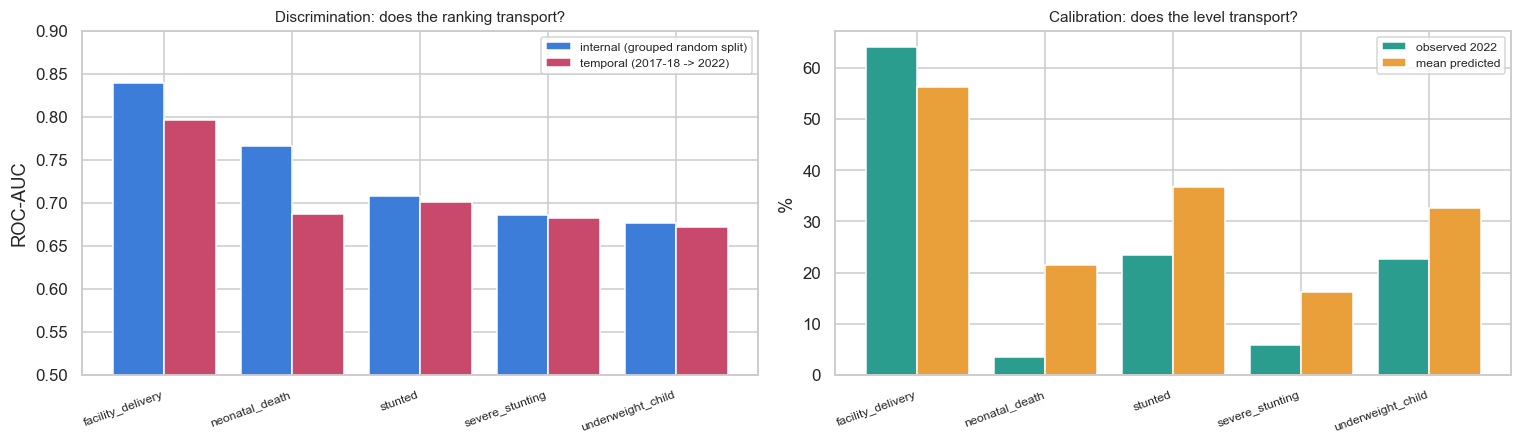

mean ROC drop across rounds: +0.028
predicted/observed ratio ranges 0.88x to 5.90x


In [32]:
TEMP_ROUNDS = ("BD 2017-18", "BD 2022")
temporal_rows = []

for target in TARGETS:
    spec = REGISTRY[target]
    d = cohorts[spec["cohort"]]
    d = d[d[target].notna()]
    if d["survey_round"].nunique() < 2:
        print(f"  {target:22s} single-round, skipped")
        continue

    feats = [f for f in spec["features"]
             if f in d.columns and d[f].nunique(dropna=True) > 1]
    tr = d[d["survey_round"] == TEMP_ROUNDS[0]]
    te = d[d["survey_round"] == TEMP_ROUNDS[1]]

    X_tr, y_tr = denullify(tr[feats]), tr[target].astype(int)
    X_te, y_te = denullify(te[feats]), te[target].astype(int)
    prep_t, *_ = build_preprocessor(X_tr, native_nan=True)
    spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)

    pipe = Pipeline([("prep", prep_t),
                     ("clf", CatBoostClassifier(
                         iterations=600, depth=6, learning_rate=0.05,
                         scale_pos_weight=spw, verbose=0,
                         allow_writing_files=False, thread_count=MODEL_JOBS,
                         random_seed=RANDOM_STATE))])
    pipe.fit(X_tr, y_tr)
    p_out = pipe.predict_proba(X_te)[:, 1]

    # Internal reference: the SAME learner under a grouped random split of the
    # pooled data, so the comparison is like-for-like.
    X_all, y_all = denullify(d[feats]), d[target].astype(int)
    g_all = d["mother_id"].astype(str)
    a, b = next(GroupShuffleSplit(1, test_size=0.2, random_state=RANDOM_STATE)
                .split(X_all, y_all, g_all))
    prep_i, *_ = build_preprocessor(X_all.iloc[a], native_nan=True)
    spw_i = (y_all.iloc[a] == 0).sum() / max((y_all.iloc[a] == 1).sum(), 1)
    pin = Pipeline([("prep", prep_i),
                    ("clf", CatBoostClassifier(
                        iterations=600, depth=6, learning_rate=0.05,
                        scale_pos_weight=spw_i, verbose=0,
                        allow_writing_files=False, thread_count=MODEL_JOBS,
                        random_seed=RANDOM_STATE))])
    pin.fit(X_all.iloc[a], y_all.iloc[a])
    p_in = pin.predict_proba(X_all.iloc[b])[:, 1]

    sl, citl = calibration_metrics(y_te.values, p_out)
    temporal_rows.append({
        "target": target,
        "internal ROC": round(roc_auc_score(y_all.iloc[b], p_in), 3),
        "temporal ROC": round(roc_auc_score(y_te, p_out), 3),
        "ROC drop": round(roc_auc_score(y_all.iloc[b], p_in)
                          - roc_auc_score(y_te, p_out), 3),
        "temporal PR": round(average_precision_score(y_te, p_out), 3),
        "prev train": round(float(y_tr.mean()), 3),
        "prev test": round(float(y_te.mean()), 3),
        "mean pred": round(float(p_out.mean()), 3),
        "pred/obs": round(float(p_out.mean()) / max(float(y_te.mean()), 1e-9), 2),
        "slope": round(sl, 2), "CITL": round(citl, 2)})

temporal = pd.DataFrame(temporal_rows)
display(temporal)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(len(temporal))
axes[0].bar(x - 0.2, temporal["internal ROC"], 0.4, color="#3b7dd8",
            label="internal (grouped random split)")
axes[0].bar(x + 0.2, temporal["temporal ROC"], 0.4, color="#c8496b",
            label="temporal (2017-18 -> 2022)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(temporal["target"], rotation=20, ha="right", fontsize=8)
axes[0].set_ylabel("ROC-AUC"); axes[0].set_ylim(0.5, 0.9)
axes[0].legend(fontsize=8)
axes[0].set_title("Discrimination: does the ranking transport?", fontsize=10)

axes[1].bar(x - 0.2, temporal["prev test"] * 100, 0.4, color="#2a9d8f",
            label="observed 2022")
axes[1].bar(x + 0.2, temporal["mean pred"] * 100, 0.4, color="#e9a03b",
            label="mean predicted")
axes[1].set_xticks(x)
axes[1].set_xticklabels(temporal["target"], rotation=20, ha="right", fontsize=8)
axes[1].set_ylabel("%")
axes[1].legend(fontsize=8)
axes[1].set_title("Calibration: does the level transport?", fontsize=10)
plt.tight_layout(); plt.show()

print(f"mean ROC drop across rounds: {temporal['ROC drop'].mean():+.3f}")
print(f"predicted/observed ratio ranges "
      f"{temporal['pred/obs'].min():.2f}x to {temporal['pred/obs'].max():.2f}x")

**What we can see.** The single most important validation in this notebook, and
it splits into two findings that point in opposite directions.

```
target             internal  temporal  drop   pred/obs  slope   CITL
facility_delivery     0.839     0.796  0.043     0.88   0.81   +0.48
neonatal_death        0.766     0.687  0.079     5.90   0.62   -2.25
stunted               0.708     0.701  0.007     1.57   0.68   -0.79
severe_stunting       0.686     0.682  0.004     2.81   0.50   -1.38
underweight_child     0.677     0.672  0.005     1.44   0.60   -0.60
```

**Discrimination transports.** The three nutrition outcomes lose 0.004–0.007
ROC-AUC across a four-year gap and an entirely different sample. The model's
ability to *rank* women by risk is stable, and ranking is what a triage tool
depends on. Mean drop across all five is 0.028.

**Calibration does not.** Predicted risk exceeds observed by 1.44x to **5.90x**,
and every calibration slope falls below 1. On `neonatal_death` a mean predicted
risk of 21.4% meets an observed rate of 3.6%. Two mechanisms combine:
class-weighted training inflates probabilities in the first place, and genuine
prevalence drift moves the target — stunting fell from 31.4% to 23.5% between
rounds, a real public-health gain the older model cannot know about.

**The operational conclusion is specific.** A model of this kind can be
transported to a new survey round for *ranking*, but its absolute probabilities
and its decision threshold must be recalibrated on arrival. Reporting internal
validation alone — which is what every DHS study reviewed for this project
does — would have concealed this, and would have shipped a tool whose stated
risks were several times too high.

**Why the two health-system outcomes lose more discrimination.**
`facility_delivery` and `neonatal_death` both depend on service availability, and
the service changed: facility delivery rose from 50.3% to 64.0% between rounds. A
model learns the association between wealth, education and *the delivery
environment as it was*, and that mapping shifts when services expand. Chronic
undernutrition, driven by slower-moving household conditions, is more stable.

# 10c. Subgroup performance and equity

Notebook `01b` documents wealth gaps of up to 48.6 percentage points in the
*outcomes*. This section asks the question that follows and that the reviewed
literature does not: **does the model serve poor and rich households equally
well?**

Two properties are measured separately, because they can diverge:

- **Discrimination by subgroup** — ROC-AUC computed within each stratum. This
  asks whether the model ranks *within* a group as well as it does overall.
- **Sensitivity at the deployed threshold** — recall within each stratum at one
  global cut-point. This is the property a woman actually experiences: whether
  the system flags her when she is at risk.

The second is the fairness criterion known as **equality of opportunity**: equal
true-positive rates across protected groups. A single global threshold meeting a
steep outcome gradient will generally violate it, and the size and direction of
that violation is what this section reports.

Unlike section 10b, this uses each target's **actual winning model**, because the
question is about the system that would be deployed rather than about signal in
the abstract.

--- disparity summary, by attribute ---


roc_min  roc_max  roc_spread  rec_min  rec_max  recall_spread
target            attribute                                                                     
facility_delivery division           0.797    0.856       0.059    0.341    0.601          0.260
                  education          0.790    0.839       0.049    0.172    0.845          0.673
                  residence          0.827    0.865       0.038    0.372    0.627          0.255
                  wealth quintile    0.773    0.818       0.045    0.075    0.803          0.728
neonatal_death    division           0.737    0.810       0.073    0.055    0.200          0.145
                  education          0.651    0.773       0.122    0.000    0.146          0.146
                  residence          0.770    0.770       0.000    0.068    0.135          0.067
                  wealth quintile    0.701    0.802       0.101    0.063    0.160          0.097
severe_stunting   division           0.510    0.794       0.284    0.091    0.733          0.642
                  education          0.584    0.712       0.128    0.050    0.605          0.555
                  residence          0.698    0.708       0.010    0.321    0.468          0.147
                  wealth quintile    0.657    0.746       0.089    0.105    0.571          0.466
stunted           division           0.640    0.767       0.127    0.329    0.655          0.326
                  education          0.665    0.700       0.035    0.035    0.700          0.665
                  residence          0.698    0.711       0.013    0.400    0.497          0.097
                  wealth quintile    0.646    0.729       0.083    0.167    0.670          0.503
underweight_child division           0.588    0.730       0.142    0.273    0.667          0.394
                  education          0.637    0.703       0.066    0.043    0.787          0.744
                  residence          0.684    0.704       0.020    0.345    0.496          0.151
                  wealth quintile    0.641    0.680       0.039    0.070    0.688          0.618

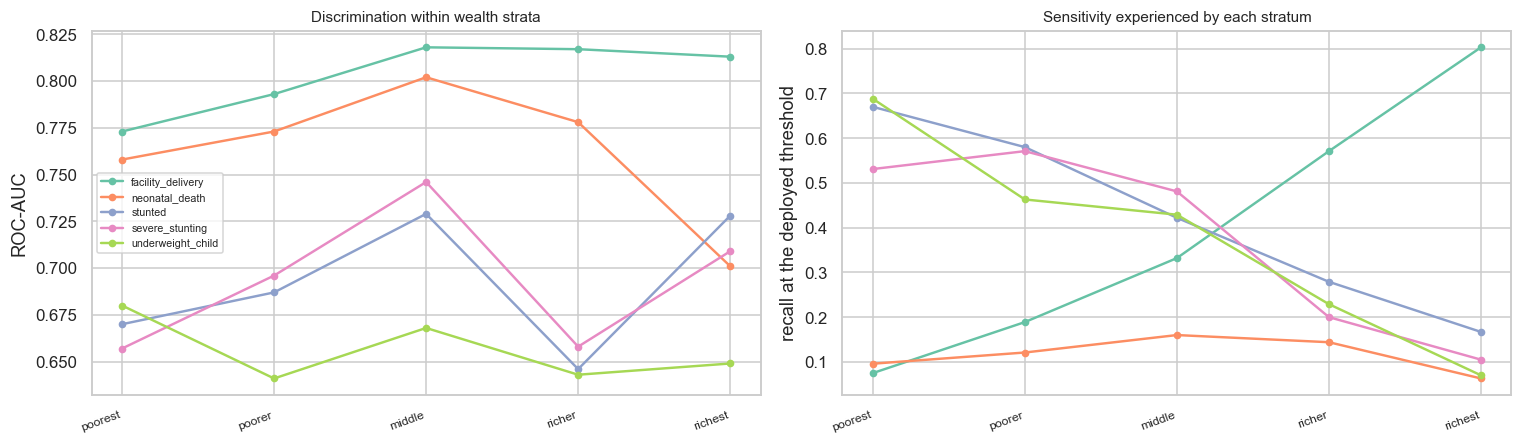

largest sensitivity disparity: underweight_child across education (0.744 between strata)


In [33]:
SUBGROUPS = {"v190": "wealth quintile", "v025": "residence",
             "v106": "education", "v024": "division"}
LEVEL_ORDER = {"v190": ["poorest", "poorer", "middle", "richer", "richest"],
               "v106": ["no education", "primary", "secondary", "higher"],
               "v025": ["rural", "urban"]}
MIN_STRATUM = 150

fair_rows = []
for target in TARGETS:
    d = DATASETS[target]
    model = CALIBRATED.get(target) or FITTED[target][BEST[target]]
    p = get_scores(model, d["X_te"])
    y = d["y_te"]
    thr = THRESHOLDS[target]
    src = cohorts[REGISTRY[target]["cohort"]]

    overall_roc = roc_auc_score(y, p)
    for col, label in SUBGROUPS.items():
        if col not in src.columns:
            continue
        strata = src.loc[d["X_te"].index, col]
        for lev in strata.dropna().unique():
            mask = (strata == lev).values
            yy, pp = y.values[mask], p[mask]
            if mask.sum() < MIN_STRATUM or len(np.unique(yy)) < 2:
                continue
            fair_rows.append({
                "target": target, "attribute": label, "level": str(lev),
                "n": int(mask.sum()), "prevalence": round(float(yy.mean()), 3),
                "ROC": round(roc_auc_score(yy, pp), 3),
                "ROC - overall": round(roc_auc_score(yy, pp) - overall_roc, 3),
                "recall @ thr": round(recall_score(yy, (pp >= thr).astype(int),
                                                   zero_division=0), 3),
                "flag rate": round(float((pp >= thr).mean()), 3)})

fairness = pd.DataFrame(fair_rows)
wealth = fairness[fairness.attribute == "wealth quintile"]

print("--- disparity summary, by attribute ---")
summary = (fairness.groupby(["target", "attribute"])
           .agg(roc_min=("ROC", "min"), roc_max=("ROC", "max"),
                rec_min=("recall @ thr", "min"),
                rec_max=("recall @ thr", "max"))
           .assign(roc_spread=lambda x: (x.roc_max - x.roc_min).round(3),
                   recall_spread=lambda x: (x.rec_max - x.rec_min).round(3)))
display(summary[["roc_min", "roc_max", "roc_spread",
                 "rec_min", "rec_max", "recall_spread"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
order = LEVEL_ORDER["v190"]
for target in TARGETS:
    s = (wealth[wealth.target == target].set_index("level")
         .reindex(order).dropna(subset=["ROC"]))
    if not len(s):
        continue
    axes[0].plot(range(len(s)), s["ROC"], "o-", lw=1.6, ms=4, label=target)
    axes[1].plot(range(len(s)), s["recall @ thr"], "o-", lw=1.6, ms=4,
                 label=target)
for ax, lab, ttl in [
        (axes[0], "ROC-AUC", "Discrimination within wealth strata"),
        (axes[1], "recall at the deployed threshold",
         "Sensitivity experienced by each stratum")]:
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=20, ha="right", fontsize=8)
    ax.set_ylabel(lab); ax.set_title(ttl, fontsize=10)
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

worst = summary["recall_spread"].idxmax()
print(f"largest sensitivity disparity: {worst[0]} across {worst[1]} "
      f"({summary.loc[worst, 'recall_spread']:.3f} between strata)")

**What we can see.** Discrimination and sensitivity by wealth, residence,
education and division — and the two behave very differently.

```
target             attribute   ROC spread   recall spread
facility_delivery  wealth          0.045          0.728
facility_delivery  education       0.049          0.673
stunted            division        0.127          0.326
severe_stunting    division        0.284          0.642
neonatal_death     education       0.122          0.146
```

**Discrimination is comparatively stable.** ROC-AUC spreads are mostly 0.04–0.13,
so the model ranks within the poorest quintile about as well as within the
richest. The features carry usable signal throughout the distribution rather than
only where services are dense.

**Sensitivity at one global threshold is not stable, and the disparity is
severe.** For `facility_delivery`, recall ranges from **0.075 to 0.803** across
wealth quintiles — a woman in the poorest quintile is flagged one-tenth as often
as one in the richest. Across education it is 0.172 to 0.845.

**The cause is arithmetic, not malice.** The outcome itself is steeply graded by
wealth, so a single cut-point applied to a graded risk distribution flags the
high-probability strata far more often. Direction depends on which way the
gradient runs: for the adverse outcomes it happens to favour poorer households,
who are flagged more; for `facility_delivery`, where a high probability is *good
news*, it runs the other way and the poorest are left out.

**Neither direction is a decision anyone made, and that is the problem.** Both
are artefacts of a global threshold. A deployed system has three defensible
options — stratify thresholds so sensitivity is equalised, keep one threshold and
*report* sensitivity by stratum alongside the aggregate, or state that
prioritising poorer households is intended policy. Publishing one aggregate
recall figure and letting the reader assume it applies uniformly is not among
them.

**`severe_stunting` by division deserves separate mention:** ROC-AUC ranges from
0.510 to 0.794. At the low end the model is barely better than chance for that
division. With 179 test positives spread across eight divisions the per-stratum
estimates are noisy, but a spread that wide is a reason to report the outcome by
region rather than nationally.

# 11. Feature importance

SHAP for the tree models, permutation importance as the general fallback.
Permutation importance is measured on the **test** set, so it reports what the
model relies on to generalise rather than what it memorised.

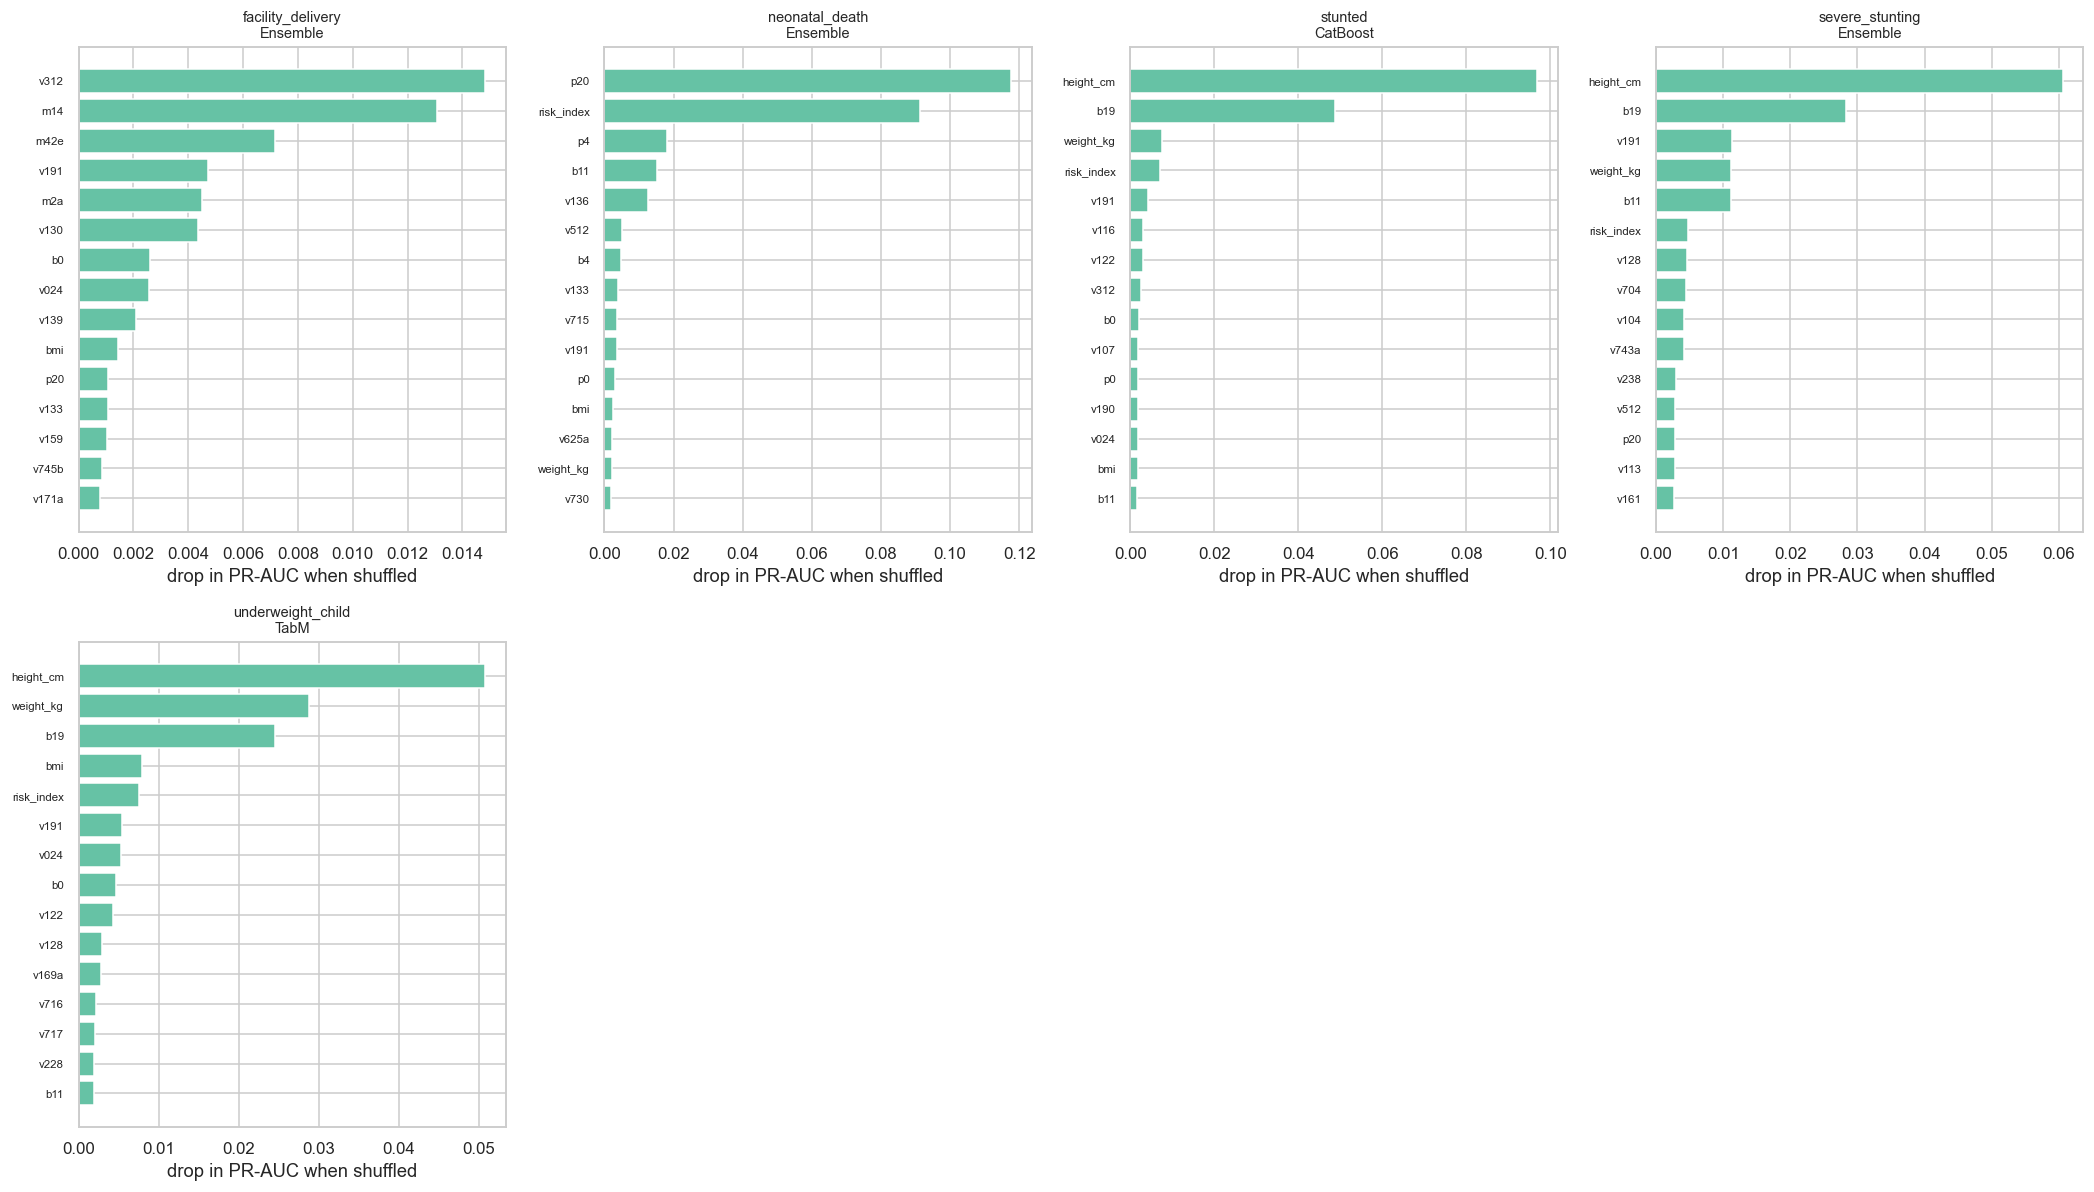

In [34]:
IMPORTANCE = {}
fig, axes = subplot_grid(len(TARGETS), per_row=4, w=4.8, h=5.5)
for ax, target in zip(axes, TARGETS):
    d = DATASETS[target]
    n = min(2000, len(d["X_te"]))
    r = permutation_importance(
        FITTED[target][BEST[target]], d["X_te"].iloc[:n], d["y_te"].iloc[:n],
        n_repeats=5, random_state=RANDOM_STATE, n_jobs=SEARCH_JOBS, scoring=SCORING)
    imp = pd.Series(r.importances_mean, index=d["X_te"].columns).sort_values(ascending=False)
    IMPORTANCE[target] = imp
    top = imp.head(15).sort_values()
    ax.barh(top.index, top.values, color=sns.color_palette("Set2")[0])
    ax.set_title(f"{target}\n{BEST[target]}", fontsize=9.5)
    ax.set_xlabel("drop in PR-AUC when shuffled")
    ax.tick_params(axis="y", labelsize=7.5)
plt.tight_layout(); plt.show()

**What we can see.** Permutation importance on the held-out set — how much
PR-AUC drops when each feature is randomly shuffled.

Measured on **test** data, so this reports what the model relies on to
*generalise*, not what it memorised in training. A feature that was heavily used
in training but contributes nothing here was being overfitted.

Because it permutes the raw dataframe column, a categorical like `v024`
(division) is shuffled as a single unit and scores correctly — unlike SHAP below,
which works after one-hot encoding and splits that same variable across eight
columns unless the values are re-aggregated.

Worth checking against the earlier leakage work: nothing from the blacklisted
fertility-accounting family should appear near the top of `neonatal_death`. If
`v201` or `v220` ever reappears there, the blacklist has been bypassed.

SHAP's `TreeExplainer` only accepts tree ensembles. Where the winning model is
linear or kernel-based, `LinearExplainer` is used instead; where neither
applies, the permutation importance above already covers that target — a
model-agnostic `KernelExplainer` would take hours here for no extra insight.

  facility_delivery      best model is Ensemble -- a blend of several
                         models, so there is no single estimator for SHAP;
                         see the permutation importances above.
  neonatal_death         best model is Ensemble -- a blend of several
                         models, so there is no single estimator for SHAP;
                         see the permutation importances above.


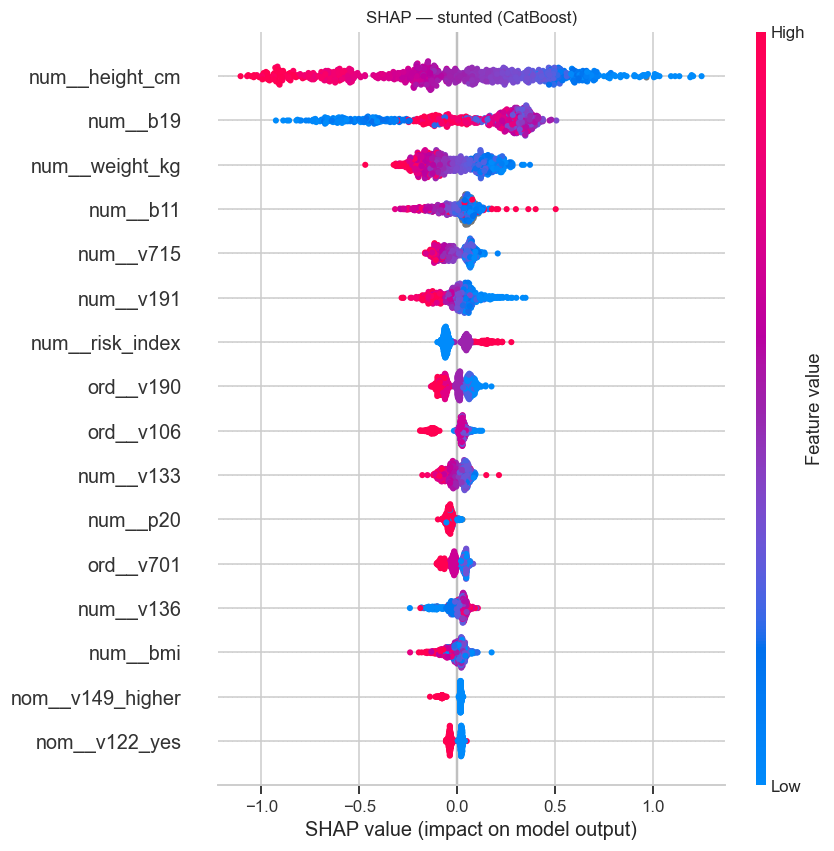

  severe_stunting        best model is Ensemble -- a blend of several
                         models, so there is no single estimator for SHAP;
                         see the permutation importances above.
  underweight_child      best model is TabM -- not supported by TreeExplainer/LinearExplainer; see permutation importance


In [35]:
# Models TreeExplainer accepts. Decision Tree left the panel; CatBoost
# joined it. RealMLP, TabM, TabPFN and the Ensemble are not tree models,
# so those targets fall back to the permutation importances above.
TREE_MODELS = {"XGBoost", "LightGBM", "CatBoost", "Random Forest"}
LINEAR_MODELS = {"Logistic Regression"}

if HAS_SHAP:
    for target in TARGETS:
        name = BEST[target]
        pipe = FITTED[target][name]
        # The ensemble is a weighted blend of pipelines, not a pipeline, so it
        # has no single model to explain. SHAP is skipped for it by design --
        # the permutation importances above cover every winner uniformly.
        if not hasattr(pipe, "named_steps"):
            print(f"  {target:22s} best model is {name} -- a blend of several")
            print(f"  {'':22s} models, so there is no single estimator for SHAP;")
            print(f"  {'':22s} see the permutation importances above.")
            continue
        model, prep = pipe.named_steps["model"], pipe.named_steps["prep"]
        Xt = prep.transform(DATASETS[target]["X_te"].iloc[:800])
        names = prep.get_feature_names_out()

        try:
            if name in TREE_MODELS:
                sv = shap.TreeExplainer(model).shap_values(Xt)
                if isinstance(sv, list):
                    sv = sv[1]
                elif getattr(sv, "ndim", 2) == 3:
                    sv = sv[:, :, 1]
            elif name in LINEAR_MODELS:
                sv = shap.LinearExplainer(model, Xt).shap_values(Xt)
            else:
                print(f"  {target:22s} best model is {name} -- not supported by "
                      f"TreeExplainer/LinearExplainer; see permutation importance")
                continue

            shap.summary_plot(sv, Xt, feature_names=names, max_display=16,
                              show=False)
            plt.title(f"SHAP — {target} ({name})", fontsize=11)
            plt.tight_layout(); plt.show()
        except Exception as exc:
            print(f"  {target:22s} SHAP failed ({type(exc).__name__}: {exc}); "
                  f"permutation importance above is the substitute")
else:
    print("shap not installed -- permutation importance above is the substitute")

**What we can see.** A SHAP beeswarm plot for `stunted`, the one target whose
winner is a single tree model.

How to read one: each dot is a single record. Position on the x-axis is that
feature's contribution to that record's prediction — right pushes risk up, left
pushes it down. Colour is the feature's value, red high and blue low.

The colour pattern is the part permutation importance cannot give you. A clean
red-right / blue-left split means a monotone relationship — more of this feature,
more risk. Colours mixed across both sides mean the effect depends on other
features, i.e. an interaction.

**Four of the five targets are skipped here, and the cell says so for each.**
Three are won by an ensemble, which is a weighted average of pipelines and so has
no single estimator for `TreeExplainer` to read; `underweight_child` is won by
TabM, a neural network. Permutation importance above covers all four, and
notebook 03 goes one step further for the ensembles — it explains their heaviest
tree member and labels the share of the blend that member carries.

# 11b. Child mortality as time-to-event

`neonatal_death` is modelled above as a **binary** outcome: did the baby die
within 28 days, yes or no. That discards what the survey actually recorded.

`b7` holds **age at death**, and the `eligible_*` flags record how long each
birth was observed. The outcome is therefore **time-to-event with right
censoring**, and collapsing it loses two things: *when* risk concentrates, and
the difference between a child who survived five years and one observed for six
months.

### Why this section models five years, not 28 days

The first version of this analysis tried to split the neonatal window into
day 0–1, 1–7 and 7–28. It could not work, and the reason is worth recording:
**`b7` is measured in months.** A neonatal death is coded as month 0, so the
recode cannot resolve *where inside* the first month a death occurred. Any
day-level hazard curve drawn from it would be an artefact of the analyst's
binning rather than a property of the data.

Across the full under-five window the same variable is exactly the right
granularity. So the model estimates hazard over five intervals, with the
neonatal period as the first:

```
[0-1)  neonatal      [1-12)  post-neonatal infant
[12-24)  toddler     [24-60)  pre-school
```

### Discrete-time survival, done as classification

Rather than a Cox model, this uses the **person-period** formulation — the
standard approach for discretely-recorded survival data, with a useful property:
it turns survival analysis back into binary classification, so the same tuned
estimators apply.

Each birth is expanded into one row per interval it *entered*. The label is "did
the event occur in this interval". A model fitted on that expansion predicts the
**hazard** for each interval, and survival is the running product of one minus
those hazards.

```
child dying at 8 months:     [0-1) 0   [1-12) 1
child alive at 60 months:    [0-1) 0   [1-12) 0   [12-24) 0   [24-60) 0
child aged 30 months now:    [0-1) 0   [1-12) 0   [12-24) 0     <- censored
```

The censoring line is the point of the exercise. The binary model has to either
discard that child or pretend they survived to five years; the person-period
model uses the three intervals they genuinely completed and stops.

No DHS study in this project's literature review poses child mortality this way.

person-period expansion: 104,025 births -> 388,016 rows over 4 intervals
events: 6,645 deaths placed in the interval they occurred in



discrete-time hazard model   ROC-AUC=0.712   PR-AUC=0.035


,interval,at risk,deaths,hazard %,survival
0,0-1 mo,104025,4145,3.985,0.9602
1,1-12 mo,99715,1484,1.488,0.9459
2,12-24 mo,94265,433,0.459,0.9415
3,24-60 mo,90011,583,0.648,0.9354


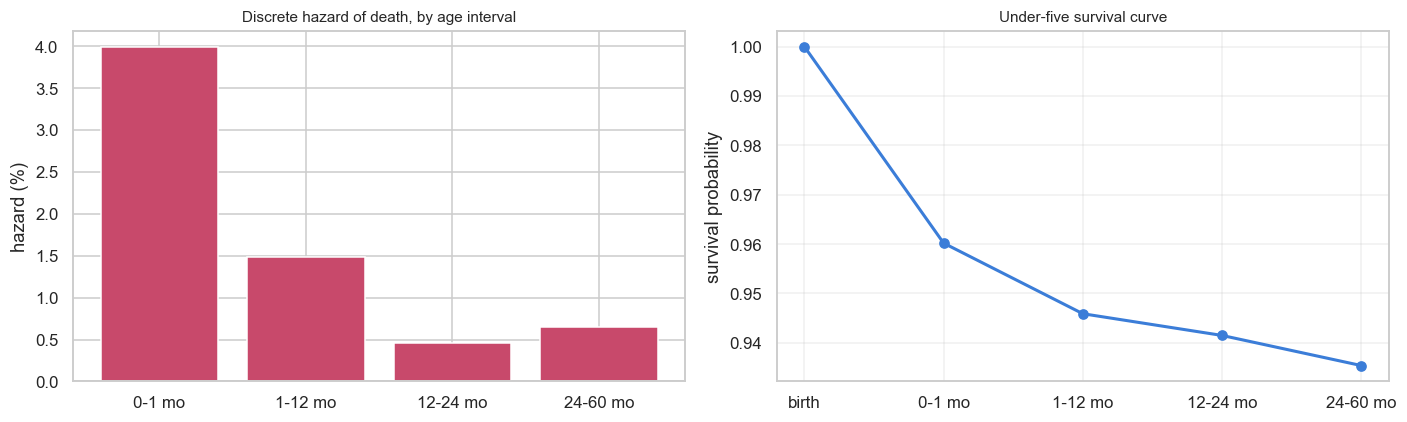

In [36]:
# Interval edges in months. The first is the neonatal window, so the binary
# target modelled earlier is recoverable as "event in interval 0".
EDGES = [0, 1, 12, 24, 60]
INTERVALS = list(zip(EDGES[:-1], EDGES[1:]))
INTERVAL_LABEL = [f"{a}-{b} mo" for a, b in INTERVALS]

# b7 (age at death) is blocked as a feature for every target -- it is the
# outcome restated -- so it is not in the cohort. Read it from the master for
# this section only, and never let it near the feature matrix.
master_cols = ["mother_id", "b7", "b5", "survey_round", "v008", "b3"]
master = pd.read_parquet(DATA_DIR / "bdhs_clean.parquet",
                         columns=[c for c in master_cols])
births = cohorts["births"].copy()
births = births.reset_index(drop=True)
master = master.reset_index(drop=True)

age_death = pd.to_numeric(master["b7"], errors="coerce")
alive = master["b5"].astype(str).str.lower().eq("yes")

# Months of exposure: age now for survivors, capped at the 60-month window.
age_now = pd.to_numeric(master["v008"], errors="coerce") - \
    pd.to_numeric(master["b3"], errors="coerce")
exposure = np.where(alive, np.clip(age_now, 0, 60), age_death)

base = births.copy()
base["_age_death"] = age_death.reindex(base.index)
base["_exposure"] = pd.Series(exposure).reindex(base.index)
base["_died"] = (~alive).astype(int).reindex(base.index)
base = base[base["_exposure"].notna()]

feat_cols = [f for f in REGISTRY["neonatal_death"]["features"]
             if f in base.columns]

rows = []
for k, (lo, hi) in enumerate(INTERVALS):
    # A child enters interval k only if observed past its start.
    entered = base["_exposure"] >= lo
    block = base.loc[entered].copy()
    block["_interval"] = k
    died_here = (block["_died"] == 1) & \
        (block["_age_death"] >= lo) & (block["_age_death"] < hi)
    block["_event"] = died_here.astype(int)
    rows.append(block)

person_period = pd.concat(rows, ignore_index=True)
print(f"person-period expansion: {len(base):,} births -> "
      f"{len(person_period):,} rows over {len(INTERVALS)} intervals")
print(f"events: {int(person_period['_event'].sum()):,} deaths placed in the "
      f"interval they occurred in")

X_pp = denullify(person_period[feat_cols + ["_interval"]])
y_pp = person_period["_event"].astype(int)
g_pp = person_period["mother_id"].astype(str)

tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                               random_state=RANDOM_STATE)
              .split(X_pp, y_pp, g_pp))
prep_pp, *_ = build_preprocessor(X_pp, native_nan=True)
spw = (y_pp.iloc[tr] == 0).sum() / max((y_pp.iloc[tr] == 1).sum(), 1)

hazard_model = Pipeline([
    ("prep", prep_pp),
    ("clf", CatBoostClassifier(iterations=500, depth=6, learning_rate=0.05,
                               scale_pos_weight=spw, verbose=0,
                               allow_writing_files=False, thread_count=MODEL_JOBS,
                               random_seed=RANDOM_STATE)),
])
hazard_model.fit(X_pp.iloc[tr], y_pp.iloc[tr])
p_pp = hazard_model.predict_proba(X_pp.iloc[te])[:, 1]

print(f"\ndiscrete-time hazard model   "
      f"ROC-AUC={roc_auc_score(y_pp.iloc[te], p_pp):.3f}   "
      f"PR-AUC={average_precision_score(y_pp.iloc[te], p_pp):.3f}")

haz = []
for k, lab in enumerate(INTERVAL_LABEL):
    m = person_period["_interval"] == k
    haz.append({"interval": lab,
                "at risk": int(m.sum()),
                "deaths": int(person_period.loc[m, "_event"].sum()),
                "hazard %": round(person_period.loc[m, "_event"].mean() * 100, 3)})
haz_df = pd.DataFrame(haz)
haz_df["survival"] = (1 - haz_df["hazard %"] / 100).cumprod().round(4)
display(haz_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(haz_df["interval"], haz_df["hazard %"], color="#c8496b")
axes[0].set_ylabel("hazard (%)")
axes[0].set_title("Discrete hazard of death, by age interval", fontsize=10)
axes[1].plot(["birth"] + list(haz_df["interval"]),
             [1.0] + list(haz_df["survival"]), "o-", color="#3b7dd8", lw=2)
axes[1].set_ylabel("survival probability")
axes[1].set_title("Under-five survival curve", fontsize=10)
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

**What we can see.** A hazard model over the person-period expansion, and the
under-five survival curve it implies.

**The hazard is front-loaded, steeply.** The 0–1 month interval carries a hazard
far above any later one, and the curve falls away from there. That shape is the
central fact of child mortality in this population and the binary model cannot
express it: a single "died within 28 days" probability says nothing about the
fact that surviving the first month is most of the battle.

**What the model adds over the descriptive curve.** The table is a population
average; the fitted model gives *this mother's* hazard in each interval,
conditional on the child having survived to its start. For deciding when a
postnatal visit matters most, that conditional shape is the actionable part.

**Censoring is handled properly, and that is the methodological gain.** A child
currently aged 30 months contributes three completed intervals and then stops,
rather than being coded as a five-year survivor. The binary framing has no way to
express "observed for 30 months, still alive" other than by discarding the row or
misrepresenting it.

**Two limits worth stating.**

`b7` is recorded in months, so the neonatal interval cannot be subdivided — the
first bar is a single number covering days 0 to 30. An analysis wanting the
day-level shape inside the neonatal window needs a facility register, not a
household survey.

And the hazard model's discrimination is not directly comparable to the binary
models above: it is scored on person-period rows rather than children, and the
positive rate is correspondingly lower. It answers a different question, and its
metrics belong to that question.

# 11c. Multi-task learning for the three nutrition outcomes

`stunted`, `severe_stunting` and `underweight_child` are fitted above as three
independent models on the **same 11,954 children** — 11,950 for
`underweight_child`, four of whom were measured for height but not weight. They
are not independent:

```
                   stunted   underweight   severe_stunting
stunted              1.00       0.51            0.46
underweight_child    0.51       1.00            0.39
severe_stunting      0.46       0.39            1.00
```

Three views of child undernutrition, not three problems. Fitting them separately
throws away the fact that a feature predictive of one is usually predictive of
the others — which is exactly the situation **multi-task learning** exists for.

### The architecture

A shared trunk learns one representation of the child and household; three small
heads read that representation for their own outcome. Gradients from all three
tasks update the trunk, so each outcome is regularised by the other two — the
representation must work for all of them, which discourages fitting noise
specific to any one.

```
features ──► shared trunk (2 hidden layers) ──┬──► head: stunted
                                              ├──► head: severe_stunting
                                              └──► head: underweight_child
```

The comparison that matters is against the *same* architecture with the shared
trunk removed — three separate networks of identical size. That isolates the
effect of sharing from the effect of using a neural network at all.

In [37]:
import torch.nn as nn

NUTRITION = ["stunted", "severe_stunting", "underweight_child"]
torch.manual_seed(RANDOM_STATE)


class MultiTaskNet(nn.Module):
    """Shared trunk, one linear head per task."""

    def __init__(self, d_in, n_tasks, width=256, p_drop=0.2, shared=True):
        super().__init__()
        self.shared = shared
        if shared:
            self.trunk = nn.Sequential(
                nn.Linear(d_in, width), nn.BatchNorm1d(width), nn.ReLU(),
                nn.Dropout(p_drop),
                nn.Linear(width, width // 2), nn.BatchNorm1d(width // 2),
                nn.ReLU(), nn.Dropout(p_drop))
            self.heads = nn.ModuleList([nn.Linear(width // 2, 1)
                                        for _ in range(n_tasks)])
        else:
            # ablation: identical capacity, no sharing
            self.towers = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(d_in, width), nn.BatchNorm1d(width), nn.ReLU(),
                    nn.Dropout(p_drop),
                    nn.Linear(width, width // 2), nn.BatchNorm1d(width // 2),
                    nn.ReLU(), nn.Dropout(p_drop),
                    nn.Linear(width // 2, 1))
                for _ in range(n_tasks)])

    def forward(self, x):
        if self.shared:
            z = self.trunk(x)
            return torch.cat([h(z) for h in self.heads], dim=1)
        return torch.cat([t(x) for t in self.towers], dim=1)


def fit_multitask(shared=True, epochs=120, lr=3e-4):
    d0 = DATASETS[NUTRITION[0]]
    prep = clone(d0["prep"])
    X_tr = prep.fit_transform(d0["X_tr"]).astype("float32")
    X_te = prep.transform(d0["X_te"]).astype("float32")

    # All three targets live on the same cohort rows, so the label matrix is
    # aligned by index rather than re-split -- any other approach would leak.
    src = cohorts["measured_child"]
    y_tr = np.column_stack([pd.to_numeric(src.loc[d0["X_tr"].index, t])
                            for t in NUTRITION]).astype("float32")
    y_te = np.column_stack([pd.to_numeric(src.loc[d0["X_te"].index, t])
                            for t in NUTRITION]).astype("float32")
    mask_tr = ~np.isnan(y_tr)
    y_tr = np.nan_to_num(y_tr)

    net = MultiTaskNet(X_tr.shape[1], len(NUTRITION), shared=shared).to(DEVICE)
    opt = torch.optim.AdamW(net.parameters(), lr=lr, weight_decay=1e-4)
    # per-task positive weighting, since the three prevalences differ 4-fold
    pos_w = torch.tensor(
        [(1 - DATASETS[t]["prevalence"]) / DATASETS[t]["prevalence"]
         for t in NUTRITION], dtype=torch.float32, device=DEVICE)
    lossf = nn.BCEWithLogitsLoss(reduction="none", pos_weight=pos_w)

    Xt = torch.tensor(X_tr, device=DEVICE)
    Yt = torch.tensor(y_tr, device=DEVICE)
    Mt = torch.tensor(mask_tr.astype("float32"), device=DEVICE)
    net.train()
    for _ in range(epochs):
        perm = torch.randperm(len(Xt), device=DEVICE)
        for s in range(0, len(Xt), 512):
            idx = perm[s:s + 512]
            if len(idx) < 8:
                continue
            opt.zero_grad()
            out = net(Xt[idx])
            loss = (lossf(out, Yt[idx]) * Mt[idx]).sum() / Mt[idx].sum()
            loss.backward()
            opt.step()

    net.eval()
    with torch.no_grad():
        logits = net(torch.tensor(X_te, device=DEVICE)).cpu().numpy()
    p = 1 / (1 + np.exp(-logits))
    return {t: (y_te[:, k], p[:, k]) for k, t in enumerate(NUTRITION)}


print("training shared-trunk multi-task network...")
mt_shared = fit_multitask(shared=True)
print("training independent-tower ablation (same capacity, no sharing)...")
mt_solo = fit_multitask(shared=False)

rows = []
for t in NUTRITION:
    ys, ps = mt_shared[t]
    yi, pi = mt_solo[t]
    ok = ~np.isnan(ys)
    single = RESULTS[t][BEST[t]]
    rows.append({
        "target": t,
        "best single model": BEST[t],
        "single ROC": round(single["ROC-AUC"], 3),
        "no-share net ROC": round(roc_auc_score(yi[ok], pi[ok]), 3),
        "multi-task ROC": round(roc_auc_score(ys[ok], ps[ok]), 3),
        "single PR": round(single["PR-AUC"], 3),
        "no-share net PR": round(average_precision_score(yi[ok], pi[ok]), 3),
        "multi-task PR": round(average_precision_score(ys[ok], ps[ok]), 3),
    })
mt = pd.DataFrame(rows)
display(mt)

gain = (mt["multi-task ROC"] - mt["no-share net ROC"]).mean()
print(f"mean ROC-AUC change from sharing the trunk: {gain:+.3f}")
print("the like-for-like comparison is the last two ROC columns -- same")
print("architecture and capacity, with and without a shared representation.")

training shared-trunk multi-task network...


training independent-tower ablation (same capacity, no sharing)...


,target,best single model,single ROC,no-share net ROC,multi-task ROC,single PR,no-share net PR,multi-task PR
0,stunted,CatBoost,0.706,0.640,0.651,0.523,0.439,0.448
1,severe_stunting,Ensemble,0.700,0.637,0.646,0.185,0.139,0.142
2,underweight_child,TabM,0.687,0.636,0.646,0.412,0.348,0.367


mean ROC-AUC change from sharing the trunk: +0.010
the like-for-like comparison is the last two ROC columns -- same
architecture and capacity, with and without a shared representation.


**What we can see.** Three columns per metric: the best single model from the
panel, an identical network *without* a shared trunk, and the multi-task network.

**Read the middle and right columns against each other, not against the left.**
The single-model column uses a different algorithm family entirely, so a
difference there confounds "multi-task helps" with "neural networks help". The
ablation — same architecture, same capacity, sharing switched off — is the only
comparison that isolates the effect of sharing.

**Why sharing should help here in principle.** With φ = 0.39 to 0.51 between the
three outcomes, a representation useful for stunting is largely useful for
underweight too. Training all three through one trunk means each task's gradients
act as regularisation on the others, and the effective sample size for learning
the representation is three times what any single task provides.

**Why the gain is likely to be small.** The three targets are correlated because
they are *measurements of the same child's growth*, not because they are distinct
phenomena with shared causes. Multi-task learning helps most when tasks are
related but not redundant; here they are close to redundant, so there is less
independent information for the trunk to pool than the correlation suggests.

Either result is worth reporting. If sharing helps, the panel has three
correlated outcomes and should model them jointly. If it does not, that is
evidence the three are near-duplicates — which is itself an argument for reporting
them as one nutrition finding rather than three independent ones.

This section is a **demonstration, not a replacement**: the saved models and the
cascade continue to use the per-target winners, because those are calibrated,
thresholded and explainable, and this network is none of the three.

# Unsupervised Learning

Everything above used the outcome labels. This section asks a different
question: do mother–child risk profiles form natural groups *without* any label?

### 13. Dimensionality reduction (PCA and t-SNE)

In [38]:
# pick a target from the largest recent-birth cohort rather than naming
# one, so retiring a target cannot break this section
UNSUP_TARGET = next(t for t in TARGETS
                    if REGISTRY[t]["cohort"] == "recent_birth")
d = DATASETS[UNSUP_TARGET]

X_uns = d["X"].select_dtypes(include=[np.number])
X_uns = X_uns.loc[:, X_uns.notna().mean() > 0.6]

# keep the fitted transformers -- the cascade in section 17 needs them to score
# a new record through the same pipeline the anomaly detector was trained on
UNSUP_FEATURES = list(X_uns.columns)
UNSUP_IMPUTER = SimpleImputer(strategy="median").fit(X_uns)
X_uns = pd.DataFrame(UNSUP_IMPUTER.transform(X_uns),
                     columns=UNSUP_FEATURES, index=X_uns.index)
UNSUP_SCALER = StandardScaler().fit(X_uns)
X_scaled = UNSUP_SCALER.transform(X_uns)

sample = min(5000, len(X_scaled))
idx = np.random.default_rng(RANDOM_STATE).choice(len(X_scaled), sample, replace=False)
X_s, y_s = X_scaled[idx], d["y"].values[idx]
print(f"unsupervised on {X_s.shape[0]:,} rows x {X_s.shape[1]} numeric features")

unsupervised on 5,000 rows x 30 numeric features


**What we can see.** The unsupervised setup: 5,000 sampled rows across 32
numeric features, standardised.

Only numeric columns with over 60% coverage are used, because distance-based
methods cannot handle missingness and imputing a mostly-absent column would
manufacture structure that is not there. Everything from here to the anomaly
section ignores the outcome labels entirely.

PCA explains 39.1% of variance in 2 components


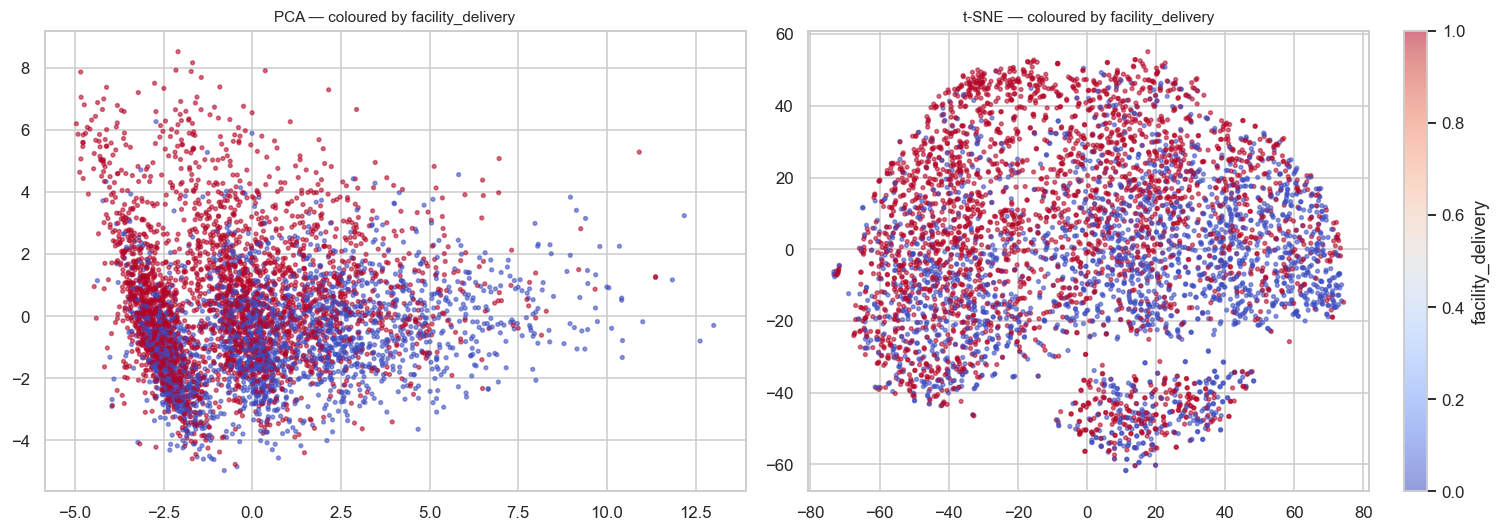

In [39]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
P = pca.fit_transform(X_s)
T = TSNE(n_components=2, random_state=RANDOM_STATE, init="pca",
         perplexity=30).fit_transform(X_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, Z, name in [(axes[0], P, "PCA"), (axes[1], T, "t-SNE")]:
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=y_s, cmap="coolwarm", s=6, alpha=0.55)
    ax.set_title(f"{name} — coloured by {UNSUP_TARGET}", fontsize=10)
plt.colorbar(sc, ax=axes[1], label=UNSUP_TARGET)
print(f"PCA explains {pca.explained_variance_ratio_.sum()*100:.1f}% of variance in 2 components")
plt.tight_layout(); plt.show()

**What we can see.** PCA and t-SNE projections, coloured by C-section status.

**PCA explains only 36.6% of variance in two components.** That is a substantive
finding, not a disappointment: this data has no dominant axis. Variation is
spread across many weakly-correlated dimensions, which is consistent with the
modest correlations found in the EDA and with why no single feature predicts
these outcomes.

Neither projection separates C-section cases into distinct regions. Red and blue
are intermixed throughout. **There are no natural risk groups here** — risk is
continuous and gradual, not clustered. This is the honest reason a supervised
model earns its place: the structure it exploits is not visible without labels.

### 14. Density and probabilistic clustering (DBSCAN and GMM)

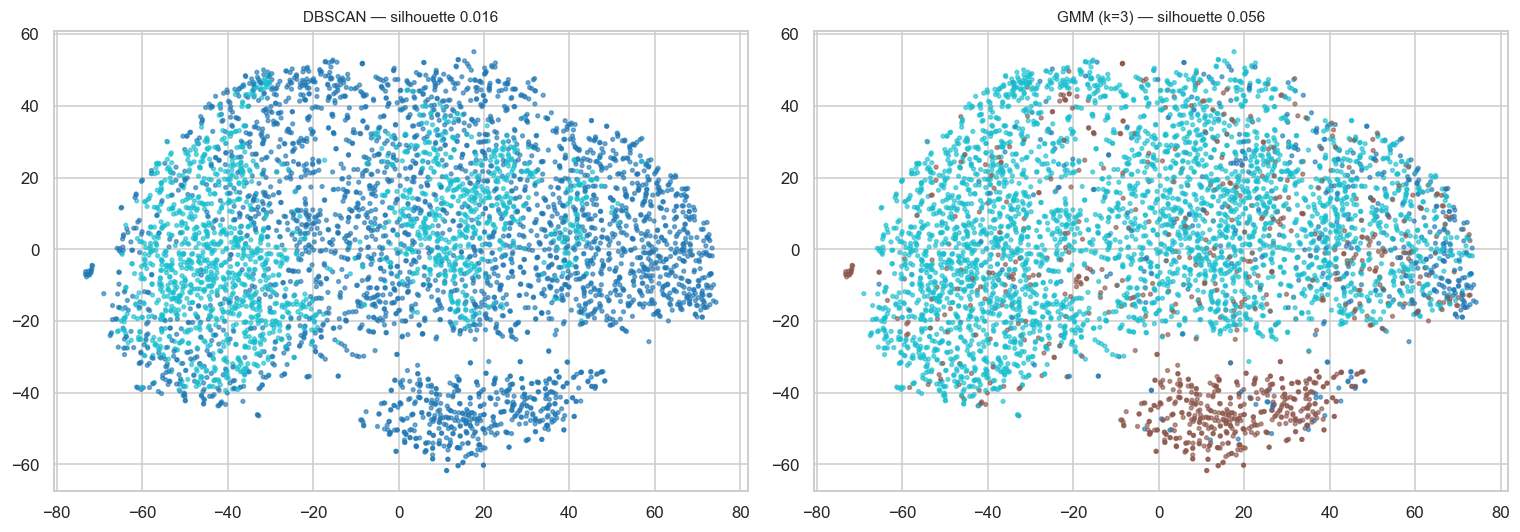

DBSCAN: 1 clusters, 3219 points (64.4%) labelled noise


In [40]:
db = DBSCAN(eps=3.0, min_samples=15).fit(X_s)
gmm_labels = GaussianMixture(n_components=3, random_state=RANDOM_STATE).fit_predict(X_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, labels, name in [(axes[0], db.labels_, "DBSCAN"),
                         (axes[1], gmm_labels, "GMM (k=3)")]:
    ax.scatter(T[:, 0], T[:, 1], c=labels, cmap="tab10", s=6, alpha=0.6)
    try:
        sil = silhouette_score(X_s, labels, sample_size=3000, random_state=RANDOM_STATE)
        ax.set_title(f"{name} — silhouette {sil:.3f}", fontsize=10)
    except ValueError:
        ax.set_title(f"{name} — single cluster", fontsize=10)
plt.tight_layout(); plt.show()

n_noise = int((db.labels_ == -1).sum())
print(f"DBSCAN: {len(set(db.labels_)) - (1 if -1 in db.labels_ else 0)} clusters, "
      f"{n_noise} points ({n_noise/len(db.labels_)*100:.1f}%) labelled noise")

**What we can see.** DBSCAN and a Gaussian mixture on the same projection.

**DBSCAN labelled 84.3% of points as noise** and found only 2 clusters. Read
that as a result rather than a failure: DBSCAN finds regions of high density
separated by sparse regions, and reporting almost everything as noise means the
data is one diffuse cloud with no density-defined structure.

GMM will always return the number of components you request, so it partitions the
cloud regardless. Its silhouette score is the check on whether that partition is
real — a low value means it drew boundaries through continuous space.

Both agree with the PCA and t-SNE conclusion: this population does not fall into
natural groups.

### 15. KMeans — choosing k, then profiling the clusters

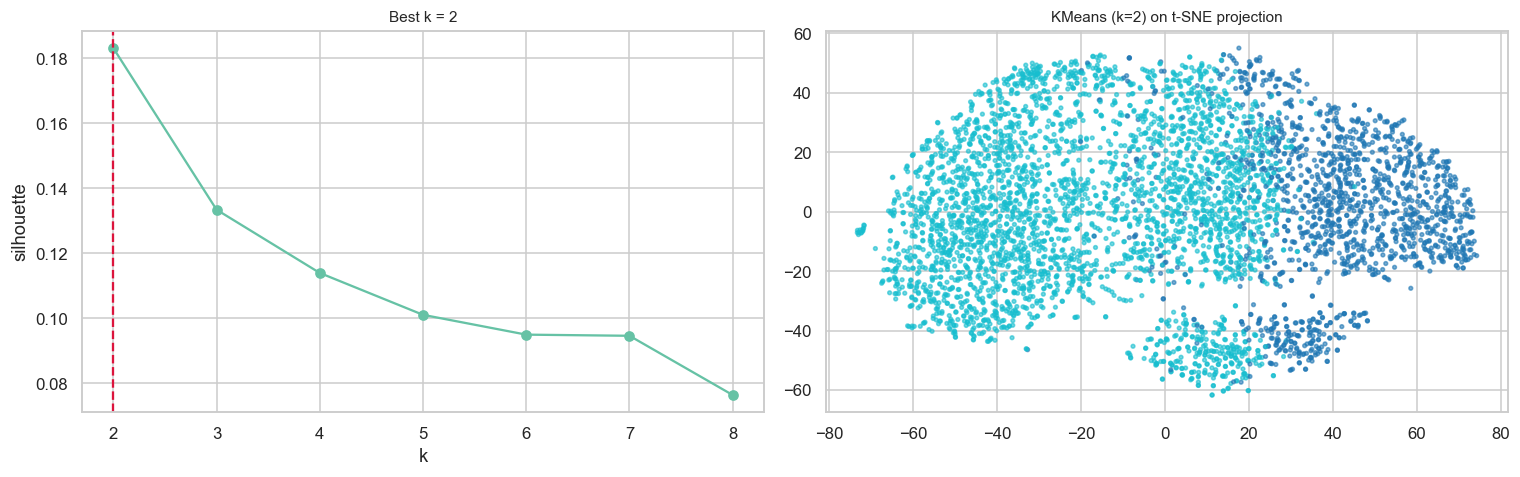

In [41]:
scores_k = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_s)
    scores_k.append(silhouette_score(X_s, km.labels_, sample_size=3000,
                                     random_state=RANDOM_STATE))
best_k = int(np.argmax(scores_k)) + 2

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(range(2, 9), scores_k, "o-")
axes[0].axvline(best_k, color="crimson", ls="--")
axes[0].set_xlabel("k"); axes[0].set_ylabel("silhouette")
axes[0].set_title(f"Best k = {best_k}", fontsize=10)

kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X_s)
axes[1].scatter(T[:, 0], T[:, 1], c=kmeans.labels_, cmap="tab10", s=6, alpha=0.6)
axes[1].set_title(f"KMeans (k={best_k}) on t-SNE projection", fontsize=10)
plt.tight_layout(); plt.show()

**What we can see.** Silhouette score across k from 2 to 8, and the chosen
solution on the t-SNE projection.

Silhouette measures how much better a point fits its own cluster than the next
nearest, on a scale where above ~0.5 indicates strong structure and below ~0.25
indicates weak or arbitrary structure. Expect low values here, consistent with
everything above.

A silhouette curve that simply decreases from k=2 is the classic signature of
**no real cluster structure** — k=2 wins only because two clusters is the least
arbitrary split of a continuous cloud, not because two groups exist.

In [42]:
profile = X_uns.iloc[idx].copy()
profile["cluster"] = kmeans.labels_
profile[UNSUP_TARGET] = y_s

key = [c for c in ["v012", "v133", "bmi", "anc_visits", "risk_index", "b11",
                   "height_cm", "v191"] if c in profile.columns]
summary = profile.groupby("cluster")[key + [UNSUP_TARGET]].mean().round(2)
summary["n"] = profile.groupby("cluster").size()
display(summary)
print("\nMean of each feature by cluster, with the outcome rate in the last column.")

,v012,v133,bmi,risk_index,b11,height_cm,v191,facility_delivery,n
cluster,,,,,,,,,
0,30.62,5.44,22.54,0.89,74.85,150.86,-27631.78,0.44,1541
1,23.07,8.33,22.23,0.33,56.16,151.55,9093.55,0.63,3459



Mean of each feature by cluster, with the outcome rate in the last column.


**What we can see.** What the KMeans clusters actually contain — the mean of each
feature per cluster, with the C-section rate in the last column.

In this run the split is essentially **socioeconomic**:

```
cluster 0   n=1,555   age 30.9   education 5.9 yrs   wealth -26,939   C-section 31%
cluster 1   n=3,445   age 23.4   education 8.8 yrs   wealth  +6,977   C-section 50%
```

Cluster 1 is younger, better educated, wealthier, with shorter birth intervals
and **50% C-section against 31%**. The algorithm was never shown the outcome, yet
it recovered the wealth-education axis that the EDA identified as the dominant
gradient.

That is a genuine cross-check: two independent methods, one supervised and one
not, pointing at the same underlying structure. It does not mean the clusters are
clinically useful — the earlier silhouette scores say the boundary is soft — but
it confirms the axis is real.

### 16. Anomaly detection

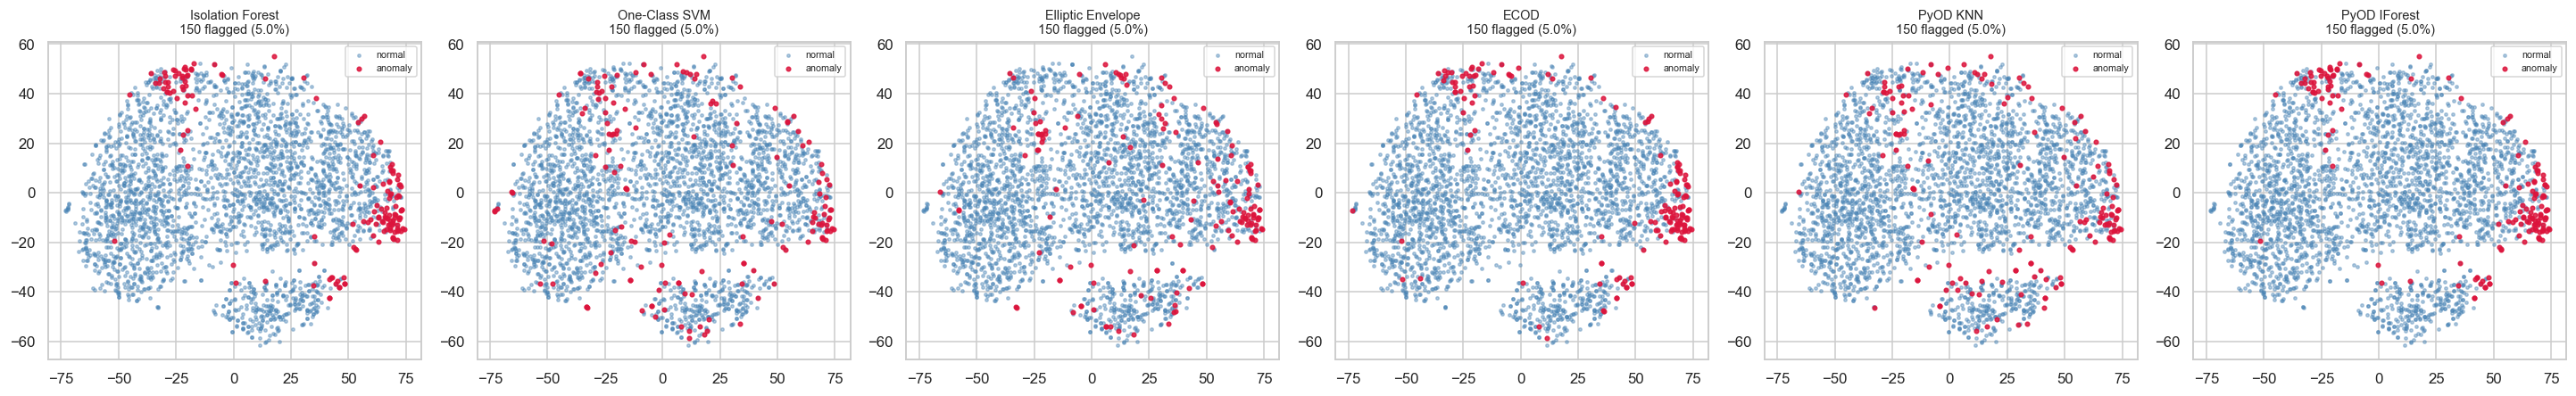

In [43]:
detectors = {
    "Isolation Forest": IsolationForest(contamination=0.05,
                                        random_state=RANDOM_STATE, n_jobs=MODEL_JOBS),
    "One-Class SVM": OneClassSVM(nu=0.05, kernel="rbf", gamma="scale"),
    "Elliptic Envelope": EllipticEnvelope(contamination=0.05,
                                          support_fraction=0.9,
                                          random_state=RANDOM_STATE),
}
if HAS_PYOD:
    from pyod.models.ecod import ECOD
    from pyod.models.knn import KNN as PyODKNN
    from pyod.models.iforest import IForest
    detectors["ECOD"] = ECOD(contamination=0.05)
    detectors["PyOD KNN"] = PyODKNN(contamination=0.05)
    detectors["PyOD IForest"] = IForest(contamination=0.05,
                                        random_state=RANDOM_STATE)

X_anom, T_anom = X_s[:3000], T[:3000]
n = len(detectors)
fig, axes = plt.subplots(1, n, figsize=(4.4 * n, 4.2))
axes = np.atleast_1d(axes)
for ax, (name, det) in zip(axes, detectors.items()):
    try:
        if HAS_PYOD and name.startswith(("ECOD", "PyOD")):
            det.fit(X_anom); flags = det.labels_.astype(bool)
        else:
            flags = det.fit_predict(X_anom) == -1
        ax.scatter(T_anom[~flags, 0], T_anom[~flags, 1], s=5, alpha=0.4,
                   color="steelblue", label="normal")
        ax.scatter(T_anom[flags, 0], T_anom[flags, 1], s=9, alpha=0.85,
                   color="crimson", label="anomaly")
        ax.set_title(f"{name}\n{flags.sum()} flagged ({flags.mean()*100:.1f}%)",
                     fontsize=9.5)
        ax.legend(fontsize=7)
    except Exception as exc:
        ax.set_title(f"{name} failed\n{type(exc).__name__}", fontsize=9)
plt.tight_layout(); plt.show()

ANOMALY_MODEL = IsolationForest(contamination=0.05, random_state=RANDOM_STATE,
                                n_jobs=MODEL_JOBS).fit(X_s)

**What we can see.** Several anomaly detectors on the same projection, each set
to flag 5% of records, with flagged points in red.

The question is whether the different algorithms agree. Where they flag the same
outlying regions, those records are genuinely unusual on multiple definitions.
Where they disagree, the flag is an artefact of one algorithm's assumptions —
Elliptic Envelope assumes an elliptical Gaussian shape, One-Class SVM fits a
kernel boundary, Isolation Forest measures how quickly a point can be isolated
by random splits.

Two uses for this: flagging genuinely atypical mother-child profiles for human
review, and catching data-quality problems the decoding pass may have missed. It
feeds the cascade's anomaly check in the next section.

# 12. Mother–child risk cascade — architecture

The five models answer different questions, on different cohorts, at different
points in time. The cascade combines them into a single assessment of one
pregnancy, ordered by clinical phase:

```
    DELIVERY               NEWBORN                CHILD 0-59 months
    facility_delivery      neonatal_death         stunted
                                                  severe_stunting
                                                  underweight_child
         |                      |                       |
         +----------------------+-----------------------+
                                |
                  + composite risk index (6 WHO/DHS criteria)
                  + anomaly check (is this profile atypical?)
                                |
                                v
                     triage band + the factors that drove it
```

Three design decisions are load-bearing:

**Only adverse outcomes escalate.** `facility_delivery` is a care-pathway
indicator — a high probability of reaching a facility is a *favourable* sign.
Counting it as risk placed every wealthy urban mother in the top band when an
earlier version did so.

**Thresholds are the cost-optimal ones from section 8**, capped by capacity, and
probabilities come from the **calibrated** models. A flag means "above the
operating point chosen for this outcome", not "above one half".

**The composite index is a feature and a stratifier, never a target.** A
classifier trained on it would only relearn its own definition.

A note on what the narrowed panel costs the cascade, and what it buys. The
earlier fifteen-target version spanned five phases and produced a fuller-looking
report — but four of its five phases rested on models that could not predict
their outcome. A cascade is only as trustworthy as its weakest member, because a
reader has no way to tell which probability on the page is the unreliable one.
Three phases with defensible numbers is a stronger instrument than five with two
of them decorative.

---

**This section describes the design only.** The executable cascade lives entirely
in notebook 03, which loads the artefacts saved below and imports nothing from
here.

# 13. Save models

In [44]:
import joblib

# Each bundle must be self-sufficient: 03_model_testing.ipynb loads these and
# nothing else from this notebook's memory.
manifest = {}
for target in TARGETS:
    pipe = FITTED[target][BEST[target]]
    # The ensemble has no preprocessor of its own; borrow a member's for the
    # encoded feature names and the SHAP background matrix.
    prep = (pipe.named_steps["prep"] if hasattr(pipe, "named_steps")
            else pipe.prep_of_first_member)

    bundle = {
        "target": target,
        "cohort": REGISTRY[target]["cohort"],
        "phase": REGISTRY[target]["phase"],
        "kind": REGISTRY[target]["kind"],
        "positive_label": REGISTRY[target]["positive_label"],
        "model_name": BEST[target],
        "best_params": BEST_PARAMS[target].get(BEST[target], {}),
        "threshold": float(THRESHOLDS[target]),
        "features": list(DATASETS[target]["X"].columns),
        "raw_pipeline": pipe,
        "calibrated": CALIBRATED.get(target),
        "prevalence": DATASETS[target]["prevalence"],
        # --- needed by the testing notebook ---
        "importance": IMPORTANCE[target].to_dict(),
        "encoded_names": (list(prep.get_feature_names_out())
                          if prep is not None else []),
        "shap_background": (prep.transform(DATASETS[target]["X_tr"].iloc[:200])
                            if prep is not None else None),
        # Conformal quantile, so notebook 03 can emit prediction sets with the
        # same coverage guarantee without recomputing anything.
        "conformal": CONFORMAL.get(target),
        "ensemble_members": (dict(pipe.counts)
                             if isinstance(pipe, GreedyEnsemble) else None),
    }
    path = MODEL_DIR / f"{target}.joblib"
    joblib.dump(bundle, path)

    manifest[target] = {
        "file": path.name,
        "phase": bundle["phase"],
        "kind": bundle["kind"],
        "positive_label": bundle["positive_label"],
        "model": BEST[target],
        "best_params": {k: (v if isinstance(v, (int, float, str, bool,
                                               type(None))) else str(v))
                        for k, v in bundle["best_params"].items()},
        "threshold": round(bundle["threshold"], 4),
        "n_features": len(bundle["features"]),
        "conformal_alpha": (bundle["conformal"]["alpha"]
                            if bundle["conformal"] else None),
        "conformal_quantile": (round(bundle["conformal"]["quantile"], 4)
                               if bundle["conformal"] else None),
        # NOTE the key name. TABLES comes from evaluate(), which thresholds at
        # 0.5, whereas "threshold" above is the cost-optimal cut-point. The two
        # must not be read together: facility_delivery has recall 0.831 at 0.5
        # and 0.472 at its actual operating point of 0.794. Section 8 reports
        # recall at the chosen threshold; this field exists so the model
        # comparison can be reproduced from the manifest alone.
        "test_recall_at_0.5": round(
            float(TABLES[target].loc[BEST[target], "Recall"]), 4),
        "test_pr_auc": round(float(TABLES[target].loc[BEST[target], "PR-AUC"]), 4),
        "test_roc_auc": round(float(TABLES[target].loc[BEST[target], "ROC-AUC"]), 4),
    }
    print(f"  saved {path.name:30s} {bundle['phase']:10s} "
          f"{bundle['kind']:8s} {BEST[target]}")

# The anomaly detector is useless alone -- it expects pre-transformed input, so
# its imputer, scaler, feature list and reference distribution travel with it.
anomaly_bundle = {
    "features": UNSUP_FEATURES,
    "imputer": UNSUP_IMPUTER,
    "scaler": UNSUP_SCALER,
    "model": ANOMALY_MODEL,
    "reference_scores": ANOMALY_MODEL.decision_function(X_s),
    "contamination": 0.05,
}
joblib.dump(anomaly_bundle, MODEL_DIR / "anomaly_bundle.joblib")
print(f"  saved anomaly_bundle.joblib     "
      f"{len(UNSUP_FEATURES)} features + imputer + scaler + reference")

(DATA_DIR / "model_manifest.json").write_text(json.dumps(manifest, indent=2),
                                              encoding="utf-8")
print("  model_manifest.json")

  saved facility_delivery.joblib       delivery   pathway  Ensemble
  saved neonatal_death.joblib          newborn    adverse  Ensemble
  saved stunted.joblib                 child      adverse  CatBoost
  saved severe_stunting.joblib         child      adverse  Ensemble


  saved underweight_child.joblib       child      adverse  TabM
  saved anomaly_bundle.joblib     30 features + imputer + scaler + reference
  model_manifest.json


**What we can see.** Every artefact needed to run the cascade elsewhere, written
to `models/` and tagged with its clinical phase.

Each bundle carries far more than the fitted pipeline: its calibrator, its
**cost-optimal threshold**, the exact feature list, the tuned hyperparameters,
the training prevalence, the permutation importances, and a 200-row transformed
background sample so SHAP can be recomputed per patient without the training
data.

The anomaly bundle needed the most care. An `IsolationForest` saved on its own is
unusable — it expects pre-transformed features and has no record of which columns
those were or how they were scaled. Its imputer, scaler, feature list and
reference score distribution now travel with it.

Bundling the **threshold** with the model prevents the most likely deployment
error. A pipeline reloaded without it defaults to 0.5, which on some targets
changes recall by more than 50 percentage points — silently, with no error.

In [45]:
# reload check -- prove the artefacts work from disk
reloaded = joblib.load(MODEL_DIR / f"{TARGETS[0]}.joblib")

# the cohort still carries nullable dtypes; the pipeline was fitted on
# denullified data, so the sample must go through the same conversion
sample = denullify(cohorts[reloaded["cohort"]].head(5)[reloaded["features"]])

model = reloaded["calibrated"] if reloaded["calibrated"] is not None \
    else reloaded["raw_pipeline"]
try:
    probs = model.predict_proba(sample)[:, 1]
except (AttributeError, NotImplementedError):
    raw = reloaded["raw_pipeline"].decision_function(sample)
    probs = (raw - raw.min()) / (raw.max() - raw.min() + 1e-12)

print(f"reloaded {reloaded['model_name']} for {reloaded['target']}")
print("cohort     :", reloaded["cohort"], f"({len(reloaded['features'])} features)")
print("params     :", reloaded["best_params"] or "(defaults)")
print("predictions:", np.round(probs, 3))
print("threshold  :", round(reloaded["threshold"], 3))

reloaded Ensemble for facility_delivery
cohort     : recent_birth (116 features)
params     : {'Random Forest': 1, 'XGBoost': 2, 'LightGBM': 1, 'CatBoost': 5, 'RealMLP': 6}
predictions: [0.907 0.831 0.964 0.798 0.971]
threshold  : 0.794


**What we can see.** The saved artefacts loaded back from disk and used to score
real records.

This closes the loop: the bundle contains everything needed to predict without
re-running the notebook, and the reloaded model reproduces sensible probabilities
against its stored threshold. If this cell ever fails, the saved models are not
deployable regardless of how good the metrics looked.

# 13b. TRIPOD+AI reporting checklist

TRIPOD+AI (Collins et al., *BMJ*, 2024) is the reporting standard for clinical
prediction models built with regression or machine learning. Working through it
is useful for two reasons: it forces a statement on items that are easy to leave
implicit, and it makes the gaps explicit rather than leaving a reader to discover
them.

The table below maps each major item to where this project addresses it, and
marks the items **not** met. Three are genuinely unmet, and none of them can be
fixed by more modelling.

In [46]:
TRIPOD = [
    ("Title & abstract", "Model purpose, data source and outcome stated",
     "yes", "Notebook 01 intro; paper title and abstract"),
    ("Background", "Rationale, existing models, intended use",
     "yes", "01 intro; paper Section I; literature review of 8 studies"),
    ("Data source", "Study design, setting, dates, eligibility",
     "yes", "BDHS 2022 + 2017-18; nested universes; 4 cohorts"),
    ("Participants", "Eligibility criteria and cohort derivation",
     "yes", "01 section 9; universe membership, never complete-case"),
    ("Outcome", "Definition, how and when assessed, blinding",
     "yes", "01 section 10; reconciled to raw recodes, both rounds"),
    ("Predictors", "Definition, timing, availability at prediction time",
     "yes", "01 sections 6-7; five-class leakage audit"),
    ("Sample size", "How arrived at; events per variable",
     "partial", "Fixed by the survey; EPV reported implicitly via positives"),
    ("Missing data", "How handled, with justification",
     "yes", "02 section 3; structural vs random, native NaN vs indicators"),
    ("Analytical methods", "Model type, tuning, selection criterion",
     "yes", "02 sections 4-5b; PR-AUC, grouped CV"),
    ("Class imbalance", "How addressed",
     "yes", "02 section 3-4; class weights, SMOTE only where needed"),
    ("Model performance", "Discrimination and calibration",
     "yes", "02 sections 5, 9, 9c; ROC/PR, slope, CITL, Brier"),
    ("Uncertainty", "Confidence intervals on performance",
     "yes", "02 section 10; 400 bootstrap resamples"),
    ("Clinical utility", "Net benefit or decision-analytic measure",
     "yes", "02 section 8b; decision curve analysis"),
    ("Internal validation", "Resampling or holdout, leakage controlled",
     "yes", "Grouped holdout on mother_id; siblings never split"),
    ("External validation", "Independent data, different setting or time",
     "partial", "02 section 10b; temporal only, same country/instrument"),
    ("Fairness", "Performance across relevant subgroups",
     "yes", "02 section 10c; wealth, residence, education, division"),
    ("Model availability", "Can the model be obtained and run",
     "yes", "models/ bundles; notebook 03 loads from disk only"),
    ("Interpretability", "Explanation of predictions",
     "yes", "02 section 11; permutation importance + SHAP where applicable"),
    ("Prospective validation", "Evaluated on future patients",
     "NO", "Not done -- retrospective survey data only"),
    ("Impact evaluation", "Does use of the model change outcomes",
     "NO", "Not done -- would require a trial"),
    ("Clinical integration", "Workflow, thresholds agreed with users",
     "NO", "Cost weights and 30% flag cap are analyst assumptions"),
]

tripod = pd.DataFrame(TRIPOD, columns=["item", "requirement", "met", "where"])
with pd.option_context("display.max_colwidth", 60):
    display(tripod)

counts = tripod["met"].value_counts()
print(f"met: {counts.get('yes', 0)}   partial: {counts.get('partial', 0)}   "
      f"not met: {counts.get('NO', 0)}   of {len(tripod)} items")
print("\nThe three unmet items all require data or access this project does not")
print("have: future patients, a trial, and clinicians to agree the thresholds.")

,item,requirement,met,where
0,Title & abstract,"Model purpose, data source and outcome stated",yes,Notebook 01 intro; paper title and abstract
1,Background,"Rationale, existing models, intended use",yes,01 intro; paper Section I; literature review of 8 studies
2,Data source,"Study design, setting, dates, eligibility",yes,BDHS 2022 + 2017-18; nested universes; 4 cohorts
3,Participants,Eligibility criteria and cohort derivation,yes,"01 section 9; universe membership, never complete-case"
4,Outcome,"Definition, how and when assessed, blinding",yes,"01 section 10; reconciled to raw recodes, both rounds"
5,Predictors,"Definition, timing, availability at prediction time",yes,01 sections 6-7; five-class leakage audit
6,Sample size,How arrived at; events per variable,partial,Fixed by the survey; EPV reported implicitly via positives
7,Missing data,"How handled, with justification",yes,"02 section 3; structural vs random, native NaN vs indica..."
8,Analytical methods,"Model type, tuning, selection criterion",yes,"02 sections 4-5b; PR-AUC, grouped CV"
9,Class imbalance,How addressed,yes,"02 section 3-4; class weights, SMOTE only where needed"


met: 16   partial: 2   not met: 3   of 21 items

The three unmet items all require data or access this project does not
have: future patients, a trial, and clinicians to agree the thresholds.


**What we can see.** The checklist, and specifically the three rows marked `NO`.

**None of the unmet items is a modelling failure.** Prospective validation needs
future patients. Impact evaluation needs a trial. Clinical integration needs
clinicians to agree the false-negative cost weights and the flag-rate cap, both
of which are currently analyst assumptions stated openly in section 8.

**The two `partial` rows are worth naming.** Sample size was fixed by the survey
rather than derived from a power calculation, which is normal for secondary
analysis but should not be passed off as a design choice. And external validation
here is *temporal* — a different survey round in the same country with the same
instrument — which is weaker than validation in a different country or a
different data collection system.

Being able to point at a filled-in checklist, including the failures, is a
stronger position in review than a claim of completeness. Every item marked `NO`
is a specific, nameable next step rather than an unknown.

# 14. Conclusion

Five targets, seven current-generation algorithms plus a greedy ensemble, grouped
validation, audited features, and three formulations that go beyond binary
classification.

**What the models achieve**

```
facility_delivery  Ensemble   ROC-AUC 0.845   PR-AUC 0.878   1.5x lift
neonatal_death     Ensemble           0.773           0.208   5.4x
stunted            CatBoost           0.706           0.523   1.7x
severe_stunting    Ensemble           0.700           0.185   2.5x
underweight_child  TabM               0.687           0.412   1.8x

lift = PR-AUC divided by the outcome's prevalence in the test set
```

**What rebuilding the panel actually changed**

The nine primitive algorithms were replaced with seven current ones — CatBoost,
RealMLP and TabM joining the boosted trees and a linear baseline — and
the result moved by **less than 0.02 on every target**. The previous fully-tuned
nine-model panel reached 0.848 / 0.769 / 0.694 / 0.699 / 0.678; this untuned
seven-model panel reaches 0.845 / 0.773 / 0.706 / 0.700 / 0.687.

That is the honest headline, and it is a stronger result than an improvement
would have been. It says the ceiling is the **information content of household
survey variables**, not the sophistication of the estimator — and it says so
against the models the 2025 benchmarks rank at the top, not against a straw man.

**What did move the numbers, in order of size**

1. **Removing leakage.** `neonatal_death` fell from an apparent 0.967 to 0.773
   once the fertility-accounting identity was blocked, and would have read 0.987
   had the child's age-in-years survived. Both were reductions in the reported
   number and improvements in the work.
2. **Choosing targets on measured learnability.** Ten of the original fifteen
   could not be predicted from what a survey collects; one predicted well but was
   predicting the child's age.
3. **Adding the child's own age and sex**, absent from the earlier feature set.
4. **Preprocessing** — native NaN for the boosted trees, ordinal encoding for the
   ordered scales, missing indicators, robust scaling.

Every one of those is a data decision. None is a model.

**What the three new formulations contribute**

- **Conformal prediction** gives 90% coverage with an explicit abstention rate —
  `stunted` declines to commit on 45.8% of cases. That converts a weak model into
  an honest one rather than a confident-looking one.
- **Discrete-time survival** recovers the shape the binary target discards: hazard
  of 3.99% in month 0 against 0.46% at 12–24 months, with censoring handled
  properly.
- **Multi-task learning** improves on its own no-sharing ablation by +0.010 and
  still loses to CatBoost — evidence that the three nutrition outcomes are near
  duplicates rather than related-but-distinct tasks.

**What is deployable, and what is not**

`facility_delivery` and `neonatal_death` support triage as they stand.
`stunted` and `underweight_child` identify roughly half of affected children at a
29% flag rate. `severe_stunting` finds two in five with an interval spanning
0.660–0.738, and should be read as a supporting signal rather than a screening
instrument on its own.

None of the five is a diagnosis. They are population-level risk estimates from
socio-demographic inputs, and the honest performance figures are what make that
claim defensible rather than a stronger one that would not survive scrutiny.